# Анализ и прогнозирование оттока сотрудников
## на основе поколенческих, поведенческих и сезонно-биоритмических факторов: интеграция в классическую HR-модель

**Автор:** Володина Надежда 

**Руководитель:** Паточенко Евгений

**Дата:** 12.10.2026

**Цель проекта:** Выявить, как поколенческие, поведенческие и сезонно-биоритмические факторы 
влияют на отток сотрудников, и построить прогнозную модель 
оттока, расширяющую классическую HR-модель.

**Стек:** Python, Pandas, scipy, Matplotlib, Seaborn, Phik, Scikit-learn, XGBoost.

**План:**
1. Постановка задачи
2. Описание датасета
3. Загрузка и подготовка данных
4. Очистка и Feature Engineering
5. EDA — общий
6. EDA — отток
7. Выводы и ключевые инсайты по EDA
8. Подготовка данных к модели
9. Построение базовой модели
10. Построение расширенной модели
11. Сравнение базовой и расширенной модели
12. Интерпретация модели и важность признаков
13. Выводы и рекомендации для HR
14. Артефакты

# 1. Постановка задачи

#### Бизнес-проблема
Компания теряет сотрудников. Классические HR-модели прогнозируют отток на основе 
демографии, структуры и компенсации. Однако они не учитывают поведенческие 
и психологические аспекты.

#### Цель
Построить модель прогнозирования оттока, которая интегрирует три дополнительных слоя:
1. **Поведенческий** — удовлетворённость, баланс, вовлечённость, переработки.
2. **Поколенческий** — возраст как когорта (X, Y, Z).
3. **Сезонный** — сезон рождения как прокси-переменная.

#### В чём новизна этого проекта?

Отток — это основная бизнес-проблема. Но чтобы понять почему люди уходят, нужно анализировать еще и удовлетворённость. Я рассматриваю её как один из ключевых признаков в модели оттока. 

Классическая HR-модель прогнозирует отток на основе демографии, структуры, компенсации и стажа. Я расширяю её тремя слоями: поведенческим (удовлетворённость, баланс, переработки), поколенческим (возраст как когорта X, Y, Z) и сезонным (сезон рождения). Я проверяю, улучшают ли эти слои качество прогноза и делают ли модель более объяснимой.

Но чтобы понять почему люди уходят, нужно анализировать удовлетворённость. Я рассматриваю её как один из ключевых признаков в модели оттока.

#### Задачи
1. Загрузить и очистить данные.
2. Создать новые признаки: `Generation`, `Season_of_Birth`, `Overall_Satisfaction`.
3. Провести EDA и проверить гипотезы о связи поколений и поведения с оттоком.
4. Построить модель прогнозирования оттока.
6. Сравнить классическую модель и расширенную.
7. Сформулировать рекомендации для HR.

#### Ожидаемый результат
1. Четкие и обоснованные инсайты для бизнеса и HR.
2. Модель с высокими метриками, и список факторов, 
которые сильнее всего влияют на отток.

# 2. Описание датасета

**Источник:**  [Kaggle — HR Attrition Analysis and Report](https://www.kaggle.com/datasets/ilcaniaabreu/hr-attrition-analysis-and-report/data?select=HR-Employee-Attrition.csv)

**Размер:** 1470 записей, 35 колонок

**Целевая переменная:**
- `Attrition` (Yes/No) — ушёл сотрудник или нет

### Описание колонок

- `Age` — возраст
- `Gender` — пол
- `MaritalStatus` — семейное положение
- `Education` — уровень образования (1–5)
- `EducationField` — область образования
- `DistanceFromHome` — расстояние от дома до работы
- `Department` — отдел (Sales, R&D, HR)
- `JobRole` — должность
- `JobLevel` — грейд (1–5)
- `BusinessTravel` — частота командировок
- `MonthlyIncome` — месячный доход
- `DailyRate`, `HourlyRate`, `MonthlyRate` — ставки
- `PercentSalaryHike` — процент повышения зарплаты
- `StockOptionLevel` — уровень опционов (0–3)
- `TotalWorkingYears` — общий стаж
- `YearsAtCompany` — лет в компании
- `YearsInCurrentRole` — лет в текущей роли
- `YearsSinceLastPromotion` — лет с последнего повышения
- `YearsWithCurrManager` — лет с текущим руководителем
- `NumCompaniesWorked` — количество компаний
- `OverTime` — работает ли сверхурочно (Yes/No)
- `JobSatisfaction` — удовлетворенность работой (1–4)
- `EnvironmentSatisfaction` — удовлетворенность средой (1–4)
- `RelationshipSatisfaction` — удовлетворенность отношениями (1–4)
- `WorkLifeBalance` — баланс работы и жизни (1–4)
- `JobInvolvement` — вовлеченность (1–4)
- `TrainingTimesLastYear` — количество обучений за год
- `PerformanceRating` — оценка эффективности (3–4)
- `EmployeeCount` —  количество сотрудников
- `Over18` — возраст старше 18 лет
- `StandardHours` — стандартное количество рабочих часов
- `EmployeeNumber` — номер сотрудника (идентификатор)
- 
Полное описание датасета [здесь](https://www.kaggle.com/datasets/ilcaniaabreu/hr-attrition-analysis-and-report/data)

### Группы признаков

- **Демография:** Age, Gender, MaritalStatus, Education, EducationField, DistanceFromHome
- **Структура:** Department, JobRole, JobLevel, BusinessTravel
- **Компенсация:** MonthlyIncome, DailyRate, HourlyRate, MonthlyRate, PercentSalaryHike, StockOptionLevel
- **Стаж:** TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager, NumCompaniesWorked
- **Поведенческие:** OverTime, JobSatisfaction, EnvironmentSatisfaction, RelationshipSatisfaction, WorkLifeBalance, JobInvolvement, TrainingTimesLastYear
- **Оценки:** PerformanceRating
- **Служебные (неинформативны для исследования, планируется удалить):** EmployeeCount, Over18, StandardHours, EmployeeNumber

### Планируемые для создания признаки
- `Generation` — поколение (X, Y, Z)
- `Season_of_Birth` — сезон рождения (синтетический)
- `Overall_Satisfaction` — интегральный индекс удовлетворённости
- `Satisfaction_Level` — уровень удовлетворённости (Low, Medium, High)

# 3. Загрузка и подготовка данных

В начале работы загрузим сам файл и посмотрим, что мы имеем

Для этого импортируем необходимую библиотеку

In [1]:
import pandas as pd

Далее считываем сам файл

In [2]:
df = pd.read_csv("HR-Employee-Attrition.csv")

посмотрим количество столбцов и строк

In [3]:
df.shape

(1470, 35)

выведем на экран названия всех колонок

In [4]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

выведем первые пять строк датасета

In [5]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Смотрим основную информацию по колонкам

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Проверяем пропуски

In [7]:
df.isnull().sum().sum()

np.int64(0)

Проверяем на наличие дубликатов

In [8]:
df.duplicated().sum()

np.int64(0)

Выводим основные описательные статистики по числовым признакам

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


проверим подозрительные колонки на количество уникальных

In [10]:
print(df['StandardHours'].nunique())
print(df['StandardHours'].iloc[0])

1
80


In [11]:
print(df['EmployeeCount'].nunique())
print(df['EmployeeCount'].iloc[0])

1
1


Видим, что в целом по таблице выбросов почти нет либо их очень маленькое значение, так как среднее и медиана почти в одном значении. 
За исключением месячного дохода - средняя сдвинулась в сторону большего значения, что может говорить о том, что есть выбросы с большими зарплатами. Также дело обстоит и с колонками YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager - Здесь также есть значения с высокими показателями, которые сдвигают среднее в большую сторону. Возможно, есть связь между показателями выбросов зарплаты и этих признаков со стажем, что в дальнейшем надо проверить.

Также видно, что EmployeeCount - значение 1 для всех. StandardHours - значение 80 для всех. Стандартное отклонение 0 для обоих признаков. Эти признаки надо будет удалить, так как они являются константными и не могут помочь модели различать классы. 

проверим колонку EmployeeNumber на количество уникальных значений

In [12]:
df['EmployeeNumber'].nunique()

1470

Видим, что каждое значение в датасете уникальное, что говорит о том, что это индентификатор, который для работы нам не нужен. Он опасен тем, что модель может заучить номера и переобучиться. Его тоже в дальнейшем удалим при очистке данных.

Так же выведем описание категориальных признаков

In [13]:
df.describe(include=object).T

,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


Видим, что признак "Over18" также имеет лишь одно значение. Для нашего исследования он никакой информации не несет и ни на что не влияет. Его также надо будет удалить.

### Первичный Вывод по датасету.

В таблице мы видим, что датасет содержит 1470 записей и 35 колонок, из которых 26 колонок числовых непрерывных величин и 9 колонок с категориальными признаками. 
Целевая переменная имеется — Attrition (Yes/No). Надо будет ее закодировать как 0 и 1.

В таблице нет пропусков, что уже очень хорошо, значит не надо будет работать с пропусками. Так же обстоит и с дубликатами. Типы данных корректны.

Предварительно понятно, что надо удалить колонки "Over18", "EmployeeCountу", "StandardHours" и идентификатор "EmployeeNumber" в виду их неинформативности. Посмотреть выбросы по датасету. 

Также планируется создать ряд новых признаков для исследования, относящихся именно к моей теме исследования зависимостей.  

# 4. Очистка и Feature Engineering

### Удалим ненужные колонки
Как и заявлялось ранее, в первую очередь удалим ненужные нам колонки (EmployeeCount, Over18, StandardHours) и идентификатор (EmployeeNumber)

In [14]:
df = df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'])

проверяем полученное количество столбцов

In [15]:
df.shape[1]

31

### Генерация даты рождения

В исходном датасете отсутствует точная дата рождения — есть только возраст (`Age`).
Чтобы протестировать гипотезу о сезонном факторе, я смоделирую дату рождения:

- **Год рождения** = текущий год − Age.
- **Месяц рождения** — случайный.
- **День рождения** — случайный (1–28).
- **Season_of_Birth** — сезон на основе месяца.

**Важно:** это **синтетическая прокси-переменная**. Она позволяет 
продемонстрировать методологию интеграции сезонного фактора, но не является 
реальными данными. В реальном HR-проекте эти данные были бы получены из HRIS.
Так же **Важная оговорка про Год рождения**. За отправную точку я беру текущий год, что может разниться с моментом сбора данных, и показывать не реальный год рождения. Это сделано для того, чтобы продемонстрировать методологию и возможность применить код на реальных данных в работе без лишних редактирований.

In [16]:
from datetime import datetime
import numpy as np

In [17]:
# Год рождения (Точка отсчёта — текущий год)
df["BirthYear"] = datetime.today().year - df["Age"]

# Месяц рождения
np.random.seed(42)
df["BirthMonth"] = np.random.randint(1, 13, size=len(df))

# День рождения
df["BirthDay"] = np.random.randint(1, 28, size=len(df))

# Собираем дату
df["BirthDate"] = pd.to_datetime(dict(year=df["BirthYear"], month=df["BirthMonth"], day=df["BirthDay"]))

проверяем как получилось

In [18]:
df[["BirthYear", "BirthMonth", "BirthDay", "BirthDate"]].head(2)

,BirthYear,BirthMonth,BirthDay,BirthDate
0,1985,7,22,1985-07-22
1,1977,4,22,1977-04-22


### Создаем сезон рождения

Создаем сезон на основе месяца

In [19]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season_of_Birth"] = df["BirthMonth"].apply(get_season)

In [20]:
df["Season_of_Birth"].head()

0    Summer
1    Spring
2    Autumn
3    Summer
4    Spring
Name: Season_of_Birth, dtype: object

### Создаем поколенческую когорту

Создаём новый признак: 
- **Generation** — поколенческая когорта (X, Y, Z) именно **на основе года**, а не возраста, чтобы этот код был гибким и работал на практике с любыми данными на текущий момент времени, не требуя исправлений.

In [21]:
def get_generation(year):
    if year >= 2013:
        return 'Alpha'
    elif year >= 1997:
        return 'Z'
    elif year >= 1981:
        return 'Y'
    elif year >= 1965:
        return 'X'
    else:
        return 'Boomer'

df['Generation'] = df['BirthYear'].apply(get_generation)

In [22]:
df['Generation'].unique()

array(['Y', 'X', 'Z'], dtype=object)

### Кодируем целевую переменную

In [23]:
df['Attrition_code'] = df['Attrition'].apply(lambda x: 1 if x=='Yes' else 0)

**Важная оговорка:** Я специально не перезаписала исходную колонку, а создала новую, так как в дальнейшем планирую использовать исходную в EDA.
На этапе подготовки данных к моделе я ее удалю.

### Создадим новые обощенные признаки по удовлетворенности

Создаём обобщенный индекс удовлетворённости (понадобится в EDA):
- **Overall_Satisfaction** — среднее пяти шкал удовлетворённости.
- **Satisfaction_Level** — категория (Low/Medium/High).

In [24]:
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
                     'RelationshipSatisfaction', 'WorkLifeBalance',
                     'JobInvolvement']
df['Overall_Satisfaction'] = df[satisfaction_cols].mean(axis=1)

Категоризируем удовлетворённость

In [25]:
def satisfaction_level(score):
    if score <= 2.0:
        return 'Low'
    elif score <= 3.0:
        return 'Medium'
    else:
        return 'High'

df['Satisfaction_Level'] = df['Overall_Satisfaction'].apply(satisfaction_level)

проверим как создались категории

In [26]:
df['Satisfaction_Level'].unique()

array(['Medium', 'High', 'Low'], dtype=object)

Выведем новые признаки на экран

In [27]:
df[['Generation', 'Season_of_Birth', 'Overall_Satisfaction', 'Satisfaction_Level']].head(3)

,Generation,Season_of_Birth,Overall_Satisfaction,Satisfaction_Level
0,Y,Summer,2.2,Medium
1,X,Spring,2.8,Medium
2,Y,Autumn,2.8,Medium


# 5. EDA — общий

**Цель:** Посмотреть в целом как распределились данные и какие есть закономерности исходя из общей картины данных

In [385]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# создание папки для сохранения графиков
os.makedirs("figures", exist_ok=True)

Еще раз посмотрим на данные

In [29]:
df.head(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,YearsWithCurrManager,BirthYear,BirthMonth,BirthDay,BirthDate,Season_of_Birth,Generation,Attrition_code,Overall_Satisfaction,Satisfaction_Level
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,5,1985,7,22,1985-07-22,Summer,Y,1,2.2,Medium
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,7,1977,4,22,1977-04-22,Spring,X,0,2.8,Medium
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,0,1989,11,5,1989-11-05,Autumn,Y,1,2.8,Medium


Сначала посмотрим на **распределение каждого числового признака**, построиив по каждому гистограмму. Выведем все на одном экране.

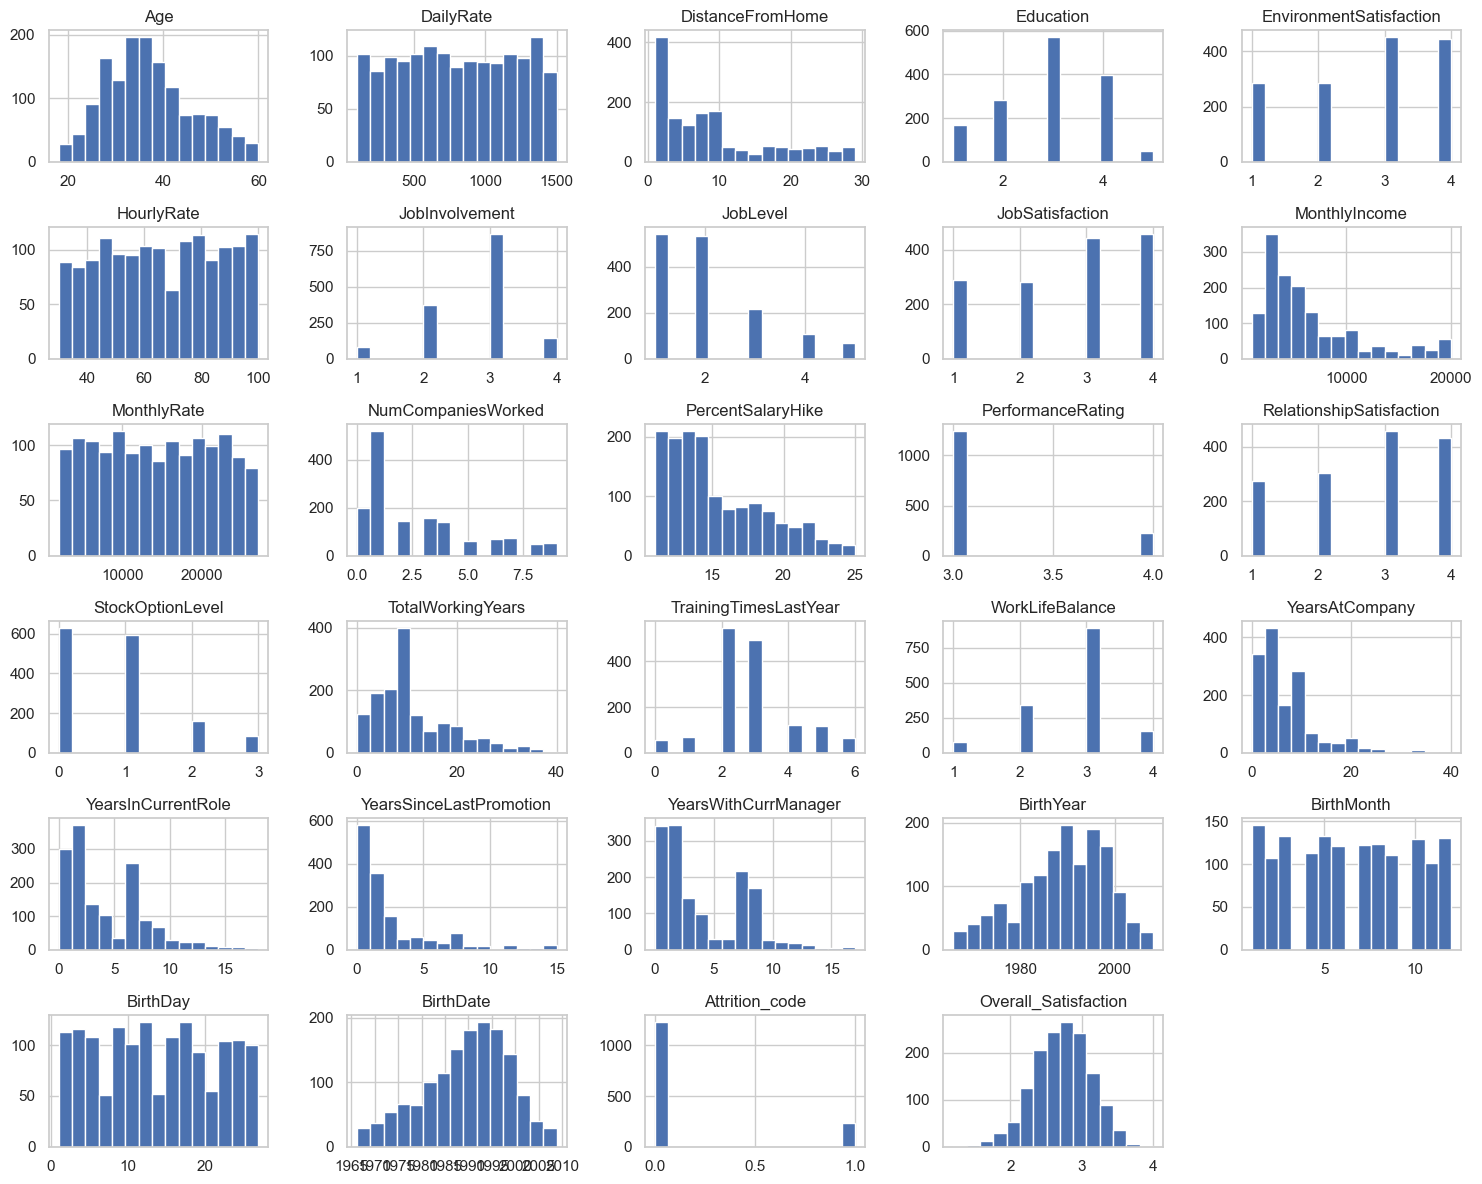

In [384]:
df.hist(bins=15, figsize=(15, 12)) 
plt.tight_layout() 
plt.savefig("figures/hist_all_num.png", dpi=300)
plt.show() 

Теперь посморим **как распределились категориальные признаки**. Выведем столбчатые диаграммы, подсчитав количество значений по каждому признаку.

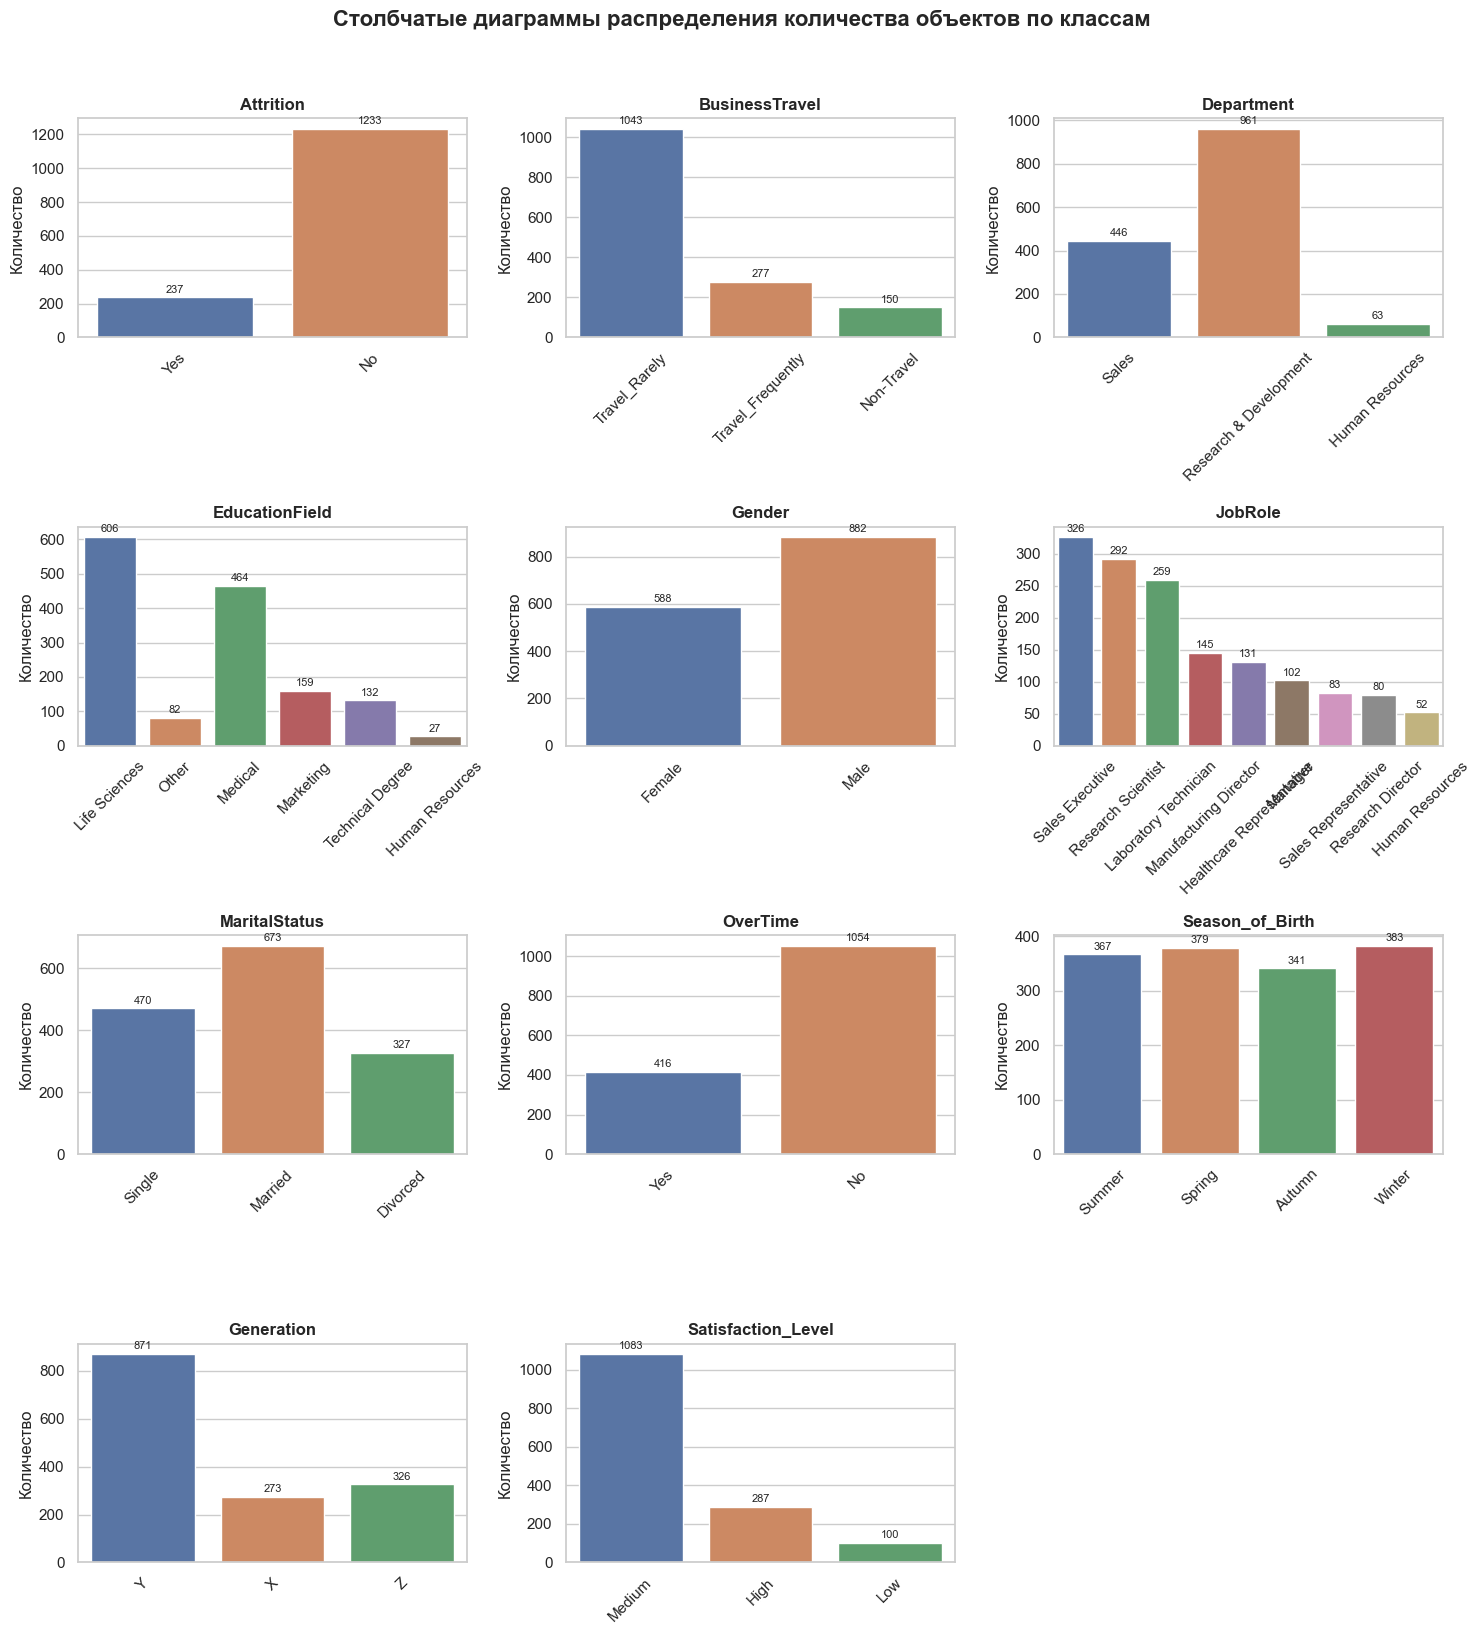

In [383]:
sns.color_palette("deep")
# Определяем категориальные колонки
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Сетка графиков
n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], hue=col, legend=False, palette='deep')
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Количество')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Подписи значений над столбцами
    for container in axes[i].containers:
        axes[i].bar_label(container, fontsize=8, padding=2)

# Скрываем пустые оси
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Столбчатые диаграммы распределения количества объектов по классам',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("figures/bar_hist_all_cat.png", dpi=300)
plt.show()

In [32]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BirthYear',
       'BirthMonth', 'BirthDay', 'BirthDate', 'Season_of_Birth', 'Generation',
       'Attrition_code', 'Overall_Satisfaction', 'Satisfaction_Level'],
      dtype='object')

**Вывод:** 

По общей картине распределений видно, что:
- есть и **нормально распределенные** признаки `Age` и `Overall_satisfaction`
- а так же **экспоненциально** распределенные - `DistanceFromHome`, `MonthlyIncome`, `NumCompaniesWorked`, `PercentSalaryHike`, `TotalWorkingYears`, `YearsAtCompany`, `YearsInCurrentRole`, `YearsSinceLastPromotion`, `YearsWithCurrManager`, что говорит, о том, что в данных есть выбросы
- и **равномерно распределенные** - `HourlyRate`, `MonthlyRate`, `BirthMonth`, `BirthDay`, что говорит о том, что они синтетически сгенерированны
- так же присутствует **дисбаланс классов по целевой переменной** `Attrition_code`

# EDA - отток

В первую очередь проведем разведочный анализ данных по оттоку и посмотрим как различные признаки влияют на отток сотрудников.

**План действий** (идём от общего к частному):

- **1 Шаг.** Сначала понимаем масштаб проблемы (**сколько уходят**).
- **2 Шаг.** Потом смотрим **кто уходит**:
   - **Демография:** Age, Gender, MaritalStatus 
   - **Поколенческий слой:** Generation
   - **Образование:** Education, EducationField
   - **Условия труда:** DistanceFromHome
   - **Структура:** Department, JobRole, JobLevel, BusinessTravel
   - **Стаж:** TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, 
     YearsSinceLastPromotion, YearsWithCurrManager, NumCompaniesWorked
- **3 Шаг.** Потом **почему уходит**:
   - **Компенсация:** MonthlyIncome, DailyRate, HourlyRate, MonthlyRate, 
     PercentSalaryHike, StockOptionLevel
   - **Поведение и удовлетворённость:** OverTime, JobSatisfaction, 
     EnvironmentSatisfaction, RelationshipSatisfaction, WorkLifeBalance, 
     JobInvolvement, TrainingTimesLastYear, Overall_Satisfaction
   - **Оценки эффективности:** PerformanceRating
   - **Сезонный слой:** Season_of_Birth
- **4 Шаг.** Потом **проверяем гипотезы** статистически.
- **5 Шаг.** В конце — **синтезируем всё в выводы**.

## Шаг 1: Сколько уходят. Базовая статистика по целевой переменной

**Цель:** понять масштаб проблемы (сколько уходят) и дисбаланс классов.

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


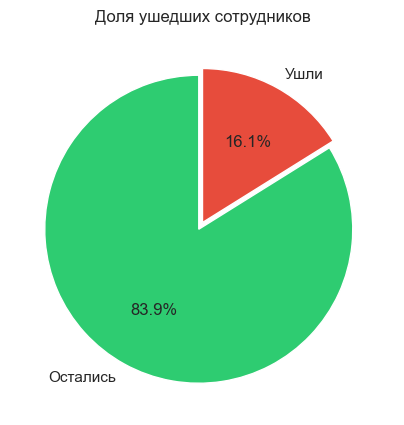

In [382]:
# Доля и количество ушедших
print(df['Attrition'].value_counts())
print(df['Attrition'].value_counts(normalize=True) * 100)

# Визуализация
fig, ax = plt.subplots(figsize=(5, 5))
attrition_counts = df['Attrition'].value_counts()
ax.pie(attrition_counts, labels=['Остались', 'Ушли'],
       colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
       startangle=90, explode=(0.05, 0))
ax.set_title('Доля ушедших сотрудников')
plt.savefig("figures/pie_ratio_attrition.png", dpi=300)
plt.show()

**Вывод:** Ушли 16.1% — это дисбаланс классов, который нужно учесть при моделировании.

## Шаг 2: Кто уходит.
**Цель:** Понять, какие группы сотрудников уходят чаще.

### 2.1. Кто уходит - Демография 
(Age, Gender, MaritalStatus)

#### Gender

Сначала проверим как распределился отток **в зависимости от пола** сотрудника

In [34]:
df['Gender'].value_counts()

Gender
Male      882
Female    588
Name: count, dtype: int64


--Всего мужчин и женщин--

Gender
Male      882
Female    588
Name: count, dtype: int64

--Отток по полу--

Gender  Attrition
Female  No           501
        Yes           87
Male    No           732
        Yes          150
Name: count, dtype: int64
Gender  Attrition
Female  No           85.204082
        Yes          14.795918
Male    No           82.993197
        Yes          17.006803
Name: proportion, dtype: float64


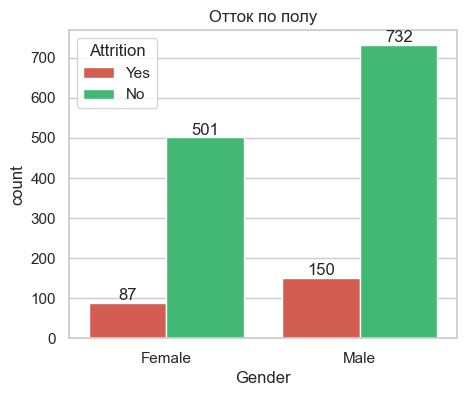

In [381]:
# всего мужчин и женщин
print("\n--Всего мужчин и женщин--\n")
print(df['Gender'].value_counts())

# Доля и количество ушедших
print("\n--Отток по полу--\n")
print(df.groupby('Gender')['Attrition'].value_counts())
print(df.groupby('Gender')['Attrition'].value_counts(normalize=True) * 100)

fig, ax = plt.subplots(figsize=(5, 4))
ax = sns.countplot(data=df, x='Gender', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
for label in ax.containers:
    ax.bar_label(label)
ax.set_title('Отток по полу')
plt.savefig("figures/bar_ratio_gender.png", dpi=300)
plt.show()

Видим, что мужчины составляют большую часть коллектива, чем женщины. Также больший процент оттока 17% (150 человек) составляют мужчины, по сравнению 14.7% у женщин.

**Итог: Чаще уходят мужчины, чем женщины**

#### Marital Status. 

Далее посмотрим как распределился **отток исходя из семейного положения**


--Всего сотрудников в зависимости от статуса--

MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64

--Отток по семейному положению--

MaritalStatus  Attrition
Divorced       No           294
               Yes           33
Married        No           589
               Yes           84
Single         No           350
               Yes          120
Name: count, dtype: int64
MaritalStatus  Attrition
Divorced       No           89.908257
               Yes          10.091743
Married        No           87.518574
               Yes          12.481426
Single         No           74.468085
               Yes          25.531915
Name: proportion, dtype: float64


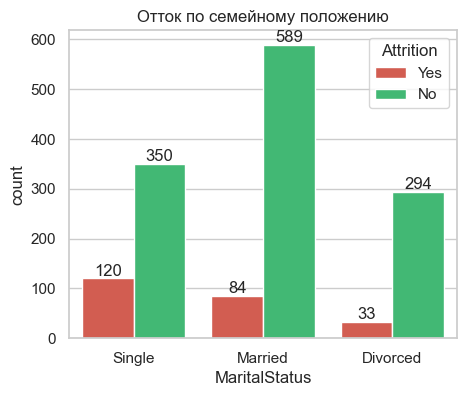

In [380]:
# всего сотрудников в зависимости от статуса
print("\n--Всего сотрудников в зависимости от статуса--\n")
print(df['MaritalStatus'].value_counts())

# Доля и количество ушедших
print("\n--Отток по семейному положению--\n")
print(df.groupby('MaritalStatus')['Attrition'].value_counts())
print(df.groupby('MaritalStatus')['Attrition'].value_counts(normalize=True) * 100)

fig, ax = plt.subplots(figsize=(5, 4))
ax = sns.countplot(data=df, x='MaritalStatus', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
for label in ax.containers:
    ax.bar_label(label)
ax.set_title('Отток по семейному положению')
plt.savefig("figures/bar_ratio_status.png", dpi=300)
plt.show()

Видим интересную закономерность. Основную часть коллектива (673 человека) составляют сотрудники, состоящие в браке, на втором месте - одинокие (470) и на самое меньшее количество у разведенных - 327 человек. а вот количество и доля ушедших распределилась по другому: большая часть ушедших - 120 человек (25%) - это одинокие, на втором месте - 84 человека (12%) - женатые, и на последнем - 33 человека (10%) - разведенные.

**Итог: Чаще уходят одинокие и меньше всего разведенные.**

#### Gender и Marital Status. Отток по полу и семейному положению.

Исходя из предыдущего наблюдения, хотелось бы проверить, как распределится доля ушедших в зависимости от **и пола и семейного статуса**

In [37]:
# Доля и количество ушедших
print("\n--Отток по семейному положению и полу--\n")
print(df.groupby(['MaritalStatus','Gender'])['Attrition'].value_counts())
print(df.groupby(['MaritalStatus','Gender'])['Attrition'].value_counts(normalize=True) * 100)


--Отток по семейному положению и полу--

MaritalStatus  Gender  Attrition
Divorced       Female  No           108
                       Yes            9
               Male    No           186
                       Yes           24
Married        Female  No           241
                       Yes           31
               Male    No           348
                       Yes           53
Single         Female  No           152
                       Yes           47
               Male    No           198
                       Yes           73
Name: count, dtype: int64
MaritalStatus  Gender  Attrition
Divorced       Female  No           92.307692
                       Yes           7.692308
               Male    No           88.571429
                       Yes          11.428571
Married        Female  No           88.602941
                       Yes          11.397059
               Male    No           86.783042
                       Yes          13.216958
Single         Fem

выведем только отток в статусе "Yes" и сортируем от большего оттока к меньшему

In [38]:
result = (df.groupby(['MaritalStatus', 'Gender'])['Attrition']
            .value_counts(normalize=True)
            .xs('Yes', level='Attrition')
            .sort_values(ascending=False))*100
print(result)

MaritalStatus  Gender
Single         Male      26.937269
               Female    23.618090
Married        Male      13.216958
Divorced       Male      11.428571
Married        Female    11.397059
Divorced       Female     7.692308
Name: proportion, dtype: float64


Видим, что самый большой отток - 26.9% у свободных мужчин, а самый маленький с большим отрывом - 7.6% - у разведенных женщин. В целом, свободные мужчины и женщины легче всего расстаются с работой. А разведеные (и в том числе замужние) женщины труднее всего. 

**Итог: Чаще всего уходят - свободные мужчины, и реже всего - разведенные женщины.** 

#### Age

Смотрим **Отток по возрасту**

Сначала посмотрим распределение возрастов

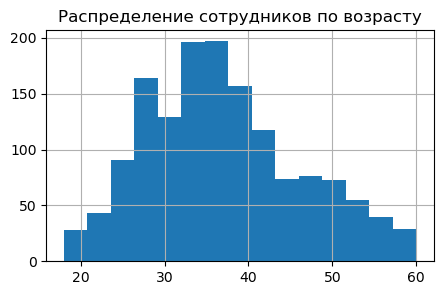

In [39]:
df['Age'].hist(bins=15, figsize=(5, 3)) 
plt.title('Распределение сотрудников по возрасту')
plt.show() 

посмотрим первые пять по самому большому проценту оттока и первые 10 по самому большому проценту оставшихся

In [40]:
print('\n---Самый большой процент ушедших---\n')
print((df.groupby('Age')['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False)[:10])*100)
print('\n---Самый большой процент неушедших---\n')
print((df.groupby('Age')['Attrition'].value_counts(normalize=True).xs('No', level='Attrition').sort_values(ascending=False)[:10])*100)


---Самый большой процент ушедших---

Age
19    66.666667
20    54.545455
18    50.000000
21    46.153846
58    35.714286
22    31.250000
26    30.769231
28    29.166667
23    28.571429
24    26.923077
Name: proportion, dtype: float64

---Самый большой процент неушедших---

Age
60    100.000000
54    100.000000
59    100.000000
57    100.000000
38     96.551724
42     95.652174
45     95.121951
27     93.750000
43     93.750000
49     91.666667
Name: proportion, dtype: float64


изобразим на графике

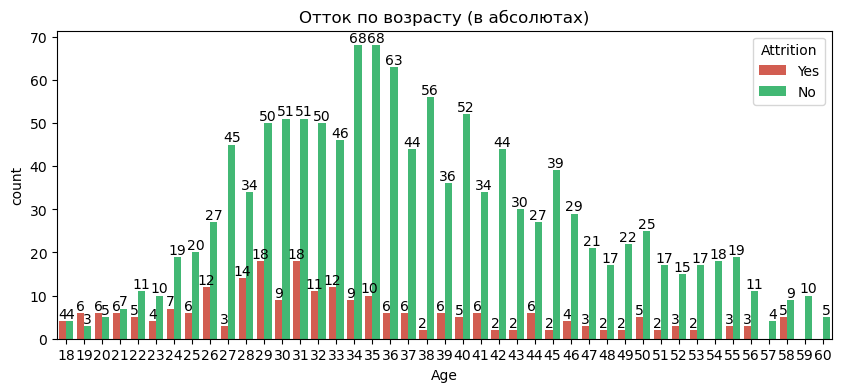

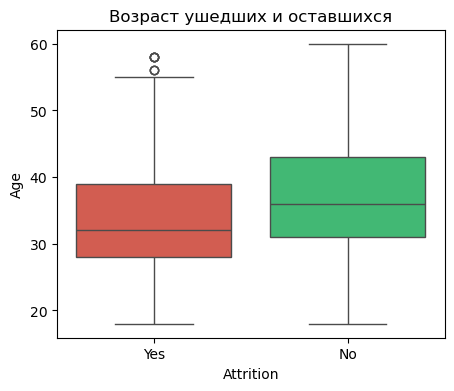

In [41]:
fig, ax = plt.subplots(figsize=(10, 4))
ax = sns.countplot(data=df, x='Age', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
for label in ax.containers:
    ax.bar_label(label)
ax.set_title('Отток по возрасту (в абсолютах)')
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=df, x='Attrition', y='Age', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
ax.set_title('Возраст ушедших и оставшихся')
plt.show()

Видим, что самый большой отток среди молодежи. Есть конечно исключение в 58 лет, но я думаю это скорее всего исключение, а не какой-то сокральный смысл. Что и подтверждается боксплотом, что это всего лишь выброс. А самый маленький отток среди людей предпенсионного возраста (0%)  и людей старше 36 лет (меньше 15%)

**Итог по возрасту: уходит чаще молодежь (до 28 лет)** 

**Вывод: Уходят чаще мужчины, одинокие, более молодые сотрудники.**

### 2.2. Кто уходит - Поколенческий слой 
(Generation)

**Цель:** проверить свою гипотезу о поколенческих различиях.

In [42]:
# всего сотрудников в зависимости от поколений
print("\n--- Всего сотрудников в зависимости от поколений ---\n")
print(df['Generation'].value_counts())

# Доля и количество ушедших
print("\n--Отток по поколениям--\n")
print(df.groupby('Generation')['Attrition'].value_counts())
print(df.groupby('Generation')['Attrition'].value_counts(normalize=True) * 100)


--- Всего сотрудников в зависимости от поколений ---

Generation
Y    871
Z    326
X    273
Name: count, dtype: int64

--Отток по поколениям--

Generation  Attrition
X           No           239
            Yes           34
Y           No           759
            Yes          112
Z           No           235
            Yes           91
Name: count, dtype: int64
Generation  Attrition
X           No           87.545788
            Yes          12.454212
Y           No           87.141217
            Yes          12.858783
Z           No           72.085890
            Yes          27.914110
Name: proportion, dtype: float64


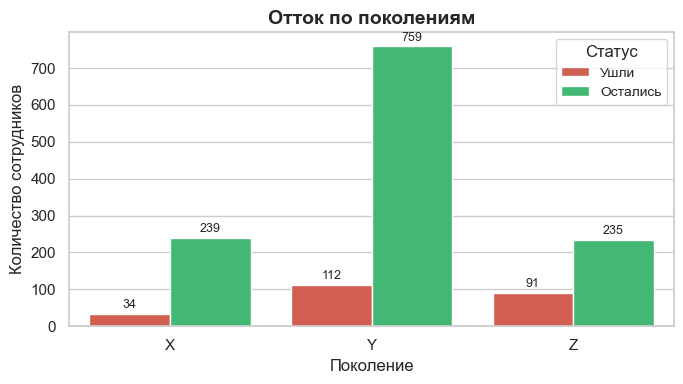

In [379]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.countplot(data=df, x='Generation', hue='Attrition', palette=['#e74c3c', '#2ecc71'], order=['X', 'Y', 'Z'])

ax.set_title('Отток по поколениям', fontsize=14, fontweight='bold')
ax.set_xlabel('Поколение', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)

# Легенда
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Ушли', 'Остались'], title='Статус', fontsize=10)

# Подписи значений над столбцами
for container in ax.containers:
    ax.bar_label(container, fontsize=9, padding=2)

plt.tight_layout()
plt.savefig("figures/bar_ratio_Generation.png", dpi=300)
plt.show()

Посмотрим только ушедших внутри каждого поколения


--- Доля ушедших внутри каждого поколения ---

  Generation  Attrition_code
0          X        0.124542
1          Y        0.128588
2          Z        0.279141


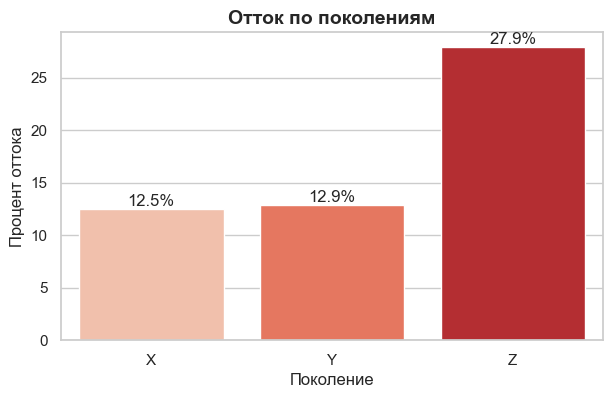

In [378]:
# Доля ушедших внутри каждого поколения
print('\n--- Доля ушедших внутри каждого поколения ---\n')
pct = df.groupby('Generation')['Attrition_code'].mean().reset_index()
print(pct)
pct['Attrition_code'] = pct['Attrition_code'] * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=pct, x='Generation', y='Attrition_code', hue='Generation', palette='Reds')
ax.set_title('Отток по поколениям', fontsize=14, fontweight='bold')
ax.set_xlabel('Поколение', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%')
plt.savefig("figures/bar_Generation.png", dpi=300)
plt.show()

**Вывод:** Поколение Z уходит чаще — почти 28% против 12% у X и Y. Что в принципе мы и наблюдали, когда сравнивали по возрастам.

#### Расширенное исследование поколенческого слоя в сочетании с другими признаками 

#### Поколение+Пол

In [45]:
# Доля и количество ушедших
print("\n--Отток по поколению и полу--\n")
print(df.groupby(['Generation','Gender'])['Attrition'].value_counts())
print(df.groupby(['Generation','Gender'])['Attrition'].value_counts(normalize=True) * 100)


--Отток по поколению и полу--

Generation  Gender  Attrition
X           Female  No           111
                    Yes           10
            Male    No           128
                    Yes           24
Y           Female  No           306
                    Yes           41
            Male    No           453
                    Yes           71
Z           Female  No            84
                    Yes           36
            Male    No           151
                    Yes           55
Name: count, dtype: int64
Generation  Gender  Attrition
X           Female  No           91.735537
                    Yes           8.264463
            Male    No           84.210526
                    Yes          15.789474
Y           Female  No           88.184438
                    Yes          11.815562
            Male    No           86.450382
                    Yes          13.549618
Z           Female  No           70.000000
                    Yes          30.000000
        

Посмотрим только ушедших


--- Доля ушедших внутри каждого поколения и с разделением по полу---

Generation  Gender
Z           Female    30.000000
            Male      26.699029
X           Male      15.789474
Y           Male      13.549618
            Female    11.815562
X           Female     8.264463
Name: proportion, dtype: float64


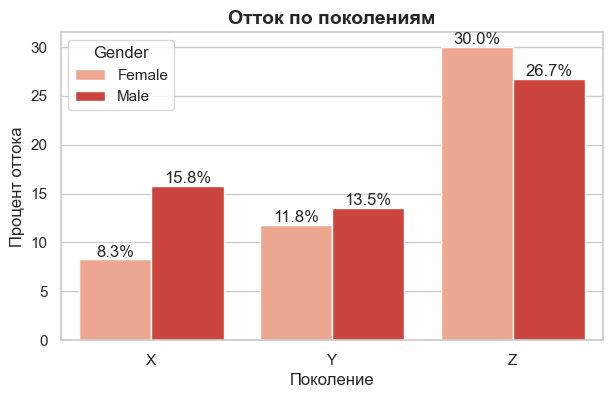

In [377]:
# Доля ушедших внутри каждого поколения  и с разделением по полу
print('\n--- Доля ушедших внутри каждого поколения и с разделением по полу---\n')
print((df.groupby(['Generation','Gender'])['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False))*100)

pct = df.groupby(['Generation','Gender'])['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=pct, x='Generation', y='Attrition_code', hue='Gender', palette='Reds')
ax.set_title('Отток по поколениям', fontsize=14, fontweight='bold')
ax.set_xlabel('Поколение', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%')
plt.savefig("figures/bar_Generation_gender.png", dpi=300)
plt.show()

**Вывод:**
- Поколение Z имеют почти одинаково высокие показатели оттока независимо от пола, у женщин отток немного выше.
- А вот у поколения X и Y перевес по оттоку в сторону мужчин, у Y - еле заметная разница, а у X - перевес значительно больший.
- На третьем месте по оттоку являются мужчины в поколении Х, у них значительный перевес с женщинами их поколения, которые в свою очередь наоборот уходят меньше всего
- У поколения Y (милениалов) отток небольшой и слабо различается среди мужчин и женщин, с небольшим перевесом в сторону мужчин

#### Поколение+Семейное_положение

In [47]:
# Доля и количество ушедших
print("\n--Отток по поколению и семейному положению--\n")
print(df.groupby(['Generation','MaritalStatus'])['Attrition'].value_counts())
print(df.groupby(['Generation','MaritalStatus'])['Attrition'].value_counts(normalize=True) * 100)


--Отток по поколению и семейному положению--

Generation  MaritalStatus  Attrition
X           Divorced       No            57
                           Yes            4
            Married        No           123
                           Yes           17
            Single         No            59
                           Yes           13
Y           Divorced       No           182
                           Yes           19
            Married        No           363
                           Yes           40
            Single         No           214
                           Yes           53
Z           Divorced       No            55
                           Yes           10
            Married        No           103
                           Yes           27
            Single         No            77
                           Yes           54
Name: count, dtype: int64
Generation  MaritalStatus  Attrition
X           Divorced       No           93.442623
           


--- Доля ушедших внутри каждого поколения и семейного положения---

Generation  MaritalStatus
Z           Single           41.221374
            Married          20.769231
Y           Single           19.850187
X           Single           18.055556
Z           Divorced         15.384615
X           Married          12.142857
Y           Married           9.925558
            Divorced          9.452736
X           Divorced          6.557377
Name: proportion, dtype: float64


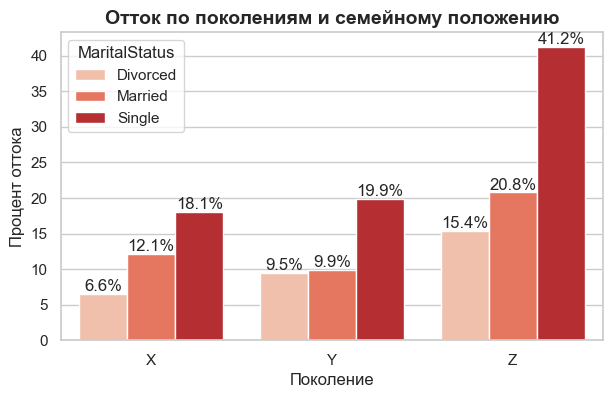

In [376]:
# Доля ушедших внутри каждого поколения  и семейного положения
print('\n--- Доля ушедших внутри каждого поколения и семейного положения---\n')
print((df.groupby(['Generation','MaritalStatus'])['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False))*100)

pct = df.groupby(['Generation','MaritalStatus'])['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=pct, x='Generation', y='Attrition_code', hue='MaritalStatus', palette='Reds')
ax.set_title('Отток по поколениям и семейному положению', fontsize=14, fontweight='bold')
ax.set_xlabel('Поколение', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%')
plt.savefig("figures/bar_Generation_status.png", dpi=300)
plt.show()

**Вывод:**
- Самые опасные по оттоку - это одинокие зумеры (поколение Z) - 41% оттока
- И следующие по оттоку с большим отрывом почти на одном уровне друг с другом находятся семейные зумеры Z (20.8%), одинокие милениалы Y и Х (19.9% и одинокие X - 18%
- небольшой процент оттока у развденных зумеров - 15.4%
- Почти не уходят (меньше 12%) - семейные и разведеные X и Y

#### Поколение+Пол+Семейное положение

In [49]:
# Доля и количество ушедших
print("\n--Отток по поколению, семейному положению и полу--\n")
print(df.groupby(['Generation', 'MaritalStatus','Gender'])['Attrition'].value_counts())
print(df.groupby(['Generation', 'MaritalStatus','Gender'])['Attrition'].value_counts(normalize=True) * 100)


--Отток по поколению, семейному положению и полу--

Generation  MaritalStatus  Gender  Attrition
X           Divorced       Female  No            24
                           Male    No            33
                                   Yes            4
            Married        Female  No            59
                                   Yes            9
                           Male    No            64
                                   Yes            8
            Single         Female  No            28
                                   Yes            1
                           Male    No            31
                                   Yes           12
Y           Divorced       Female  No            62
                                   Yes            6
                           Male    No           120
                                   Yes           13
            Married        Female  No           147
                                   Yes           10
                  

In [50]:
# Доля ушедших внутри каждого поколения  и с разделением по полу
print('\n--- Доля ушедших внутри каждого поколения и с разделением по полу---\n')
print((df.groupby(['Generation', 'MaritalStatus','Gender'])['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False))*100)


--- Доля ушедших внутри каждого поколения и с разделением по полу---

Generation  MaritalStatus  Gender
Z           Single         Female    43.750000
                           Male      39.759036
X           Single         Male      27.906977
Z           Married        Female    25.531915
Y           Single         Female    20.491803
                           Male      19.310345
Z           Married        Male      18.072289
            Divorced       Male      17.500000
X           Married        Female    13.235294
Y           Married        Male      12.195122
Z           Divorced       Female    12.000000
X           Married        Male      11.111111
            Divorced       Male      10.810811
Y           Divorced       Male       9.774436
                           Female     8.823529
            Married        Female     6.369427
X           Single         Female     3.448276
Name: proportion, dtype: float64


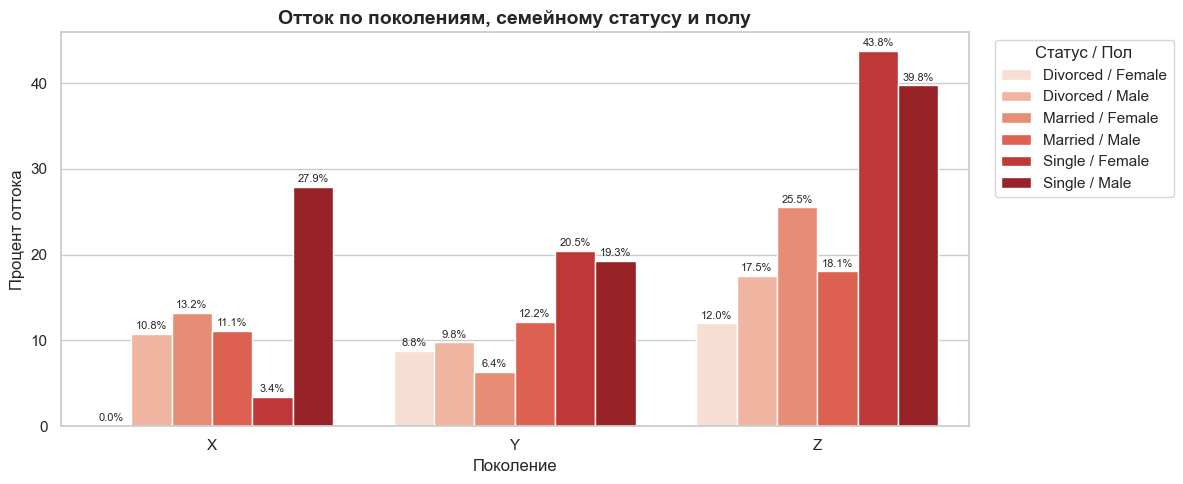

In [374]:
pct = (df.groupby(['Generation', 'MaritalStatus', 'Gender'])['Attrition_code']
         .mean().mul(100).reset_index())
pct['Group'] = pct['MaritalStatus'] + ' / ' + pct['Gender']

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=pct, x='Generation', y='Attrition_code',
            hue='Group', palette='Reds', ax=ax)

for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', fontsize=8, padding=2)

ax.set_title('Отток по поколениям, семейному статусу и полу',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Поколение')
ax.set_ylabel('Процент оттока')
ax.legend(title='Статус / Пол', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig("figures/bar_Generation_status_gender.png", dpi=300)
plt.show()

**Вывод:**
- **Cамый большой отток у одиноких мужчин и женщин поколения Z (39.8% и 43.8% соответственно) и одиноких мужчин поколения Х (27.9%)**
- так же высокий уровень оттока (25.5%) имеют семейные женщины поколения Z
- Относительно высокий уровень оттока сохраняют одинокие мужчины и женщины поколения Х (19.3% и 20.5% соответственно)
- Далее идут разведенные и семейные мужчины поколения Z (17.5% и 18.1% соответственно)
- **Почти не уходят (меньше 13%)**:
  - Разведенные женщины всех поколений
  - Разведенные и женатые мужчины среднего и старшего поколения (X и Y)
  - Замужние женщины среднего и старшего поколения (X и Y)
  - свободные женщины старшего поколения Х
    
**Среди женщин** уходят только свободные и замужние женщины поколения Z и свободные женщины поколения Y. Остальные почти не уходят.

**Среди мужчин** разведенных и семейных также низкий отток можно сказать во всех поколениях, есть немного выше показатель у молодого поколения, но он тоже не превышает порог 20%. Предположим, что это связано с большей ответственностью, которая лежит на них в этих статусах. 

#### Есть ли связь между и поколением и уровнем удовлетворенности


--- Всего сотрудников в зависимости от образования ---

Satisfaction_Level
Medium    1083
High       287
Low        100
Name: count, dtype: int64


<Axes: >

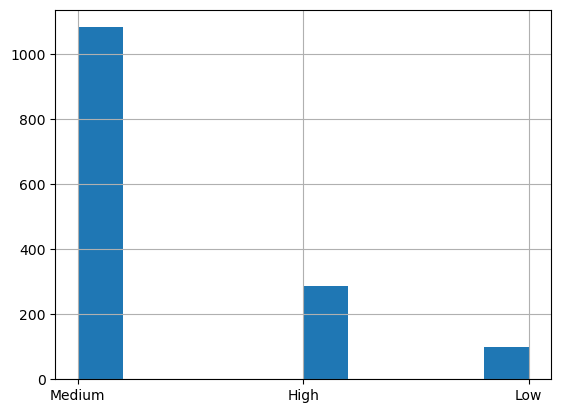

In [52]:
# распределение уровней удовлетвореннности
print("\n--- Всего сотрудников в зависимости от образования ---\n")
print(df['Satisfaction_Level'].value_counts())

df['Satisfaction_Level'].hist()


--Отток по образованию--

Generation  Satisfaction_Level
X           Medium                206
            High                   52
            Low                    15
Y           Medium                642
            High                  174
            Low                    55
Z           Medium                235
            High                   61
            Low                    30
Name: count, dtype: int64
Generation  Satisfaction_Level
X           Medium                75.457875
            High                  19.047619
            Low                    5.494505
Y           Medium                73.708381
            High                  19.977038
            Low                    6.314581
Z           Medium                72.085890
            High                  18.711656
            Low                    9.202454
Name: proportion, dtype: float64


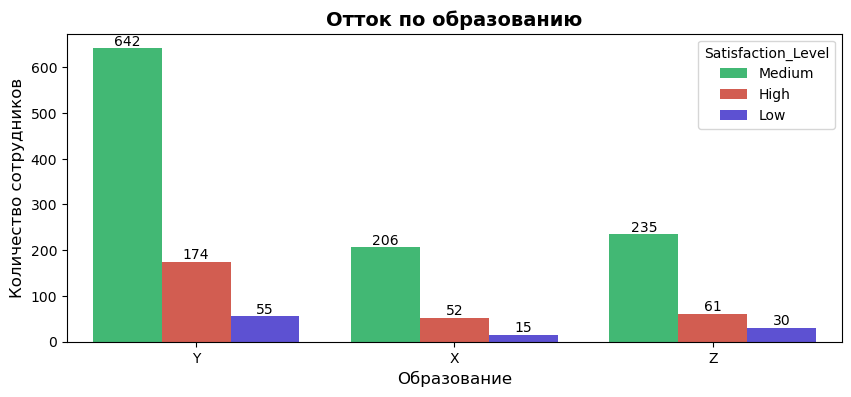

In [53]:
# Доля и количество ушедших
print("\n--Отток по образованию--\n")
print(df.groupby('Generation')['Satisfaction_Level'].value_counts())
print(df.groupby('Generation')['Satisfaction_Level'].value_counts(normalize=True) * 100)

fig, ax = plt.subplots(figsize=(10, 4))
ax = sns.countplot(data=df, x='Generation', hue='Satisfaction_Level', palette=['#2ecc71', '#e74c3c', '#4c3ce7'])
for label in ax.containers:
    ax.bar_label(label)
ax.set_title('Отток по образованию', fontsize=14, fontweight='bold')
ax.set_xlabel('Образование', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)
plt.show()

In [54]:
# Доля ушедших внутри каждого образования
print('\n---Процентное распределение уровней удовлетворенности среди разных поколений---\n')
print('\n---Низкая удовлетворенность---\n')
print((df.groupby('Generation')['Satisfaction_Level'].value_counts(normalize=True).xs('Low', level='Satisfaction_Level').sort_values(ascending=False))*100)

print('\n---Средняя удовлетворенность---\n')
print((df.groupby('Generation')['Satisfaction_Level'].value_counts(normalize=True).xs('Medium', level='Satisfaction_Level').sort_values(ascending=False))*100)

print('\n---Высокая удовлетворенность---\n')
print((df.groupby('Generation')['Satisfaction_Level'].value_counts(normalize=True).xs('High', level='Satisfaction_Level').sort_values(ascending=False))*100)


---Процентное распределение уровней удовлетворенности среди разных поколений---


---Низкая удовлетворенность---

Generation
Z    9.202454
Y    6.314581
X    5.494505
Name: proportion, dtype: float64

---Средняя удовлетворенность---

Generation
X    75.457875
Y    73.708381
Z    72.085890
Name: proportion, dtype: float64

---Высокая удовлетворенность---

Generation
Y    19.977038
X    19.047619
Z    18.711656
Name: proportion, dtype: float64


**Вывод:**
- Степени удовлетворенности распределились равномерно во всех поколениях
- **Гипотеза о различной степени удовлетворенности среди разных поколений не подтверждена**

### 2.3. Кто уходит - Образование
(Education, EducationField)

#### Education


--- Всего сотрудников в зависимости от образования ---

Education
3    572
4    398
2    282
1    170
5     48
Name: count, dtype: int64

--Отток по образованию--

Education  Attrition
1          No           139
           Yes           31
2          No           238
           Yes           44
3          No           473
           Yes           99
4          No           340
           Yes           58
5          No            43
           Yes            5
Name: count, dtype: int64
Education  Attrition
1          No           81.764706
           Yes          18.235294
2          No           84.397163
           Yes          15.602837
3          No           82.692308
           Yes          17.307692
4          No           85.427136
           Yes          14.572864
5          No           89.583333
           Yes          10.416667
Name: proportion, dtype: float64


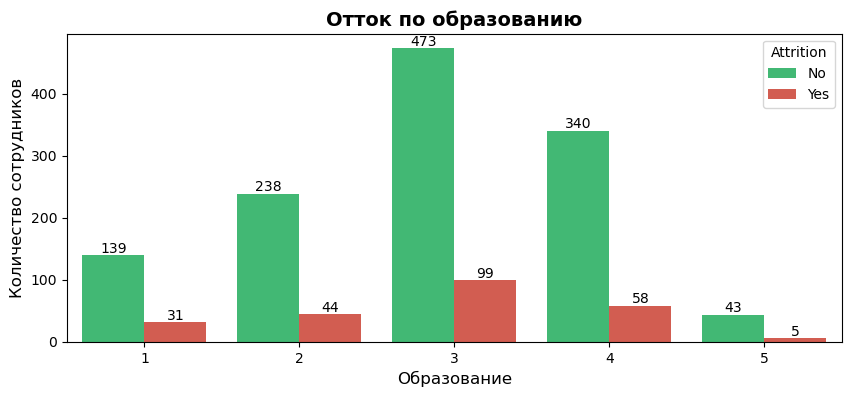

In [55]:
# всего сотрудников в зависимости от образования
print("\n--- Всего сотрудников в зависимости от образования ---\n")
print(df['Education'].value_counts())

# Доля и количество ушедших
print("\n--Отток по образованию--\n")
print(df.groupby('Education')['Attrition'].value_counts())
print(df.groupby('Education')['Attrition'].value_counts(normalize=True) * 100)

fig, ax = plt.subplots(figsize=(10, 4))
ax = sns.countplot(data=df, x='Education', hue='Attrition', palette=['#2ecc71', '#e74c3c'])
for label in ax.containers:
    ax.bar_label(label)
ax.set_title('Отток по образованию', fontsize=14, fontweight='bold')
ax.set_xlabel('Образование', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)
plt.show()


---Процент ушедших---

Education
1    18.235294
3    17.307692
2    15.602837
4    14.572864
5    10.416667
Name: proportion, dtype: float64


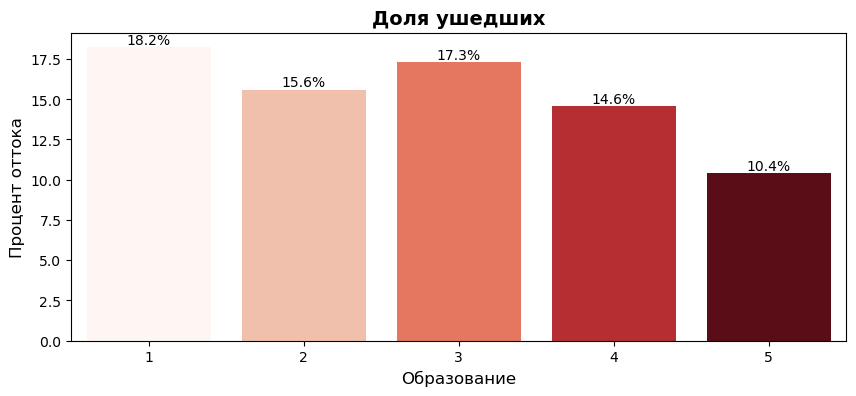

In [56]:
# Доля ушедших внутри каждого образования
print('\n---Процент ушедших---\n')
print((df.groupby('Education')['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False))*100)

pct = df.groupby('Education')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=pct, x='Education', y='Attrition_code', hue='Education', palette='Reds', legend=False)
ax.set_title('Доля ушедших', fontsize=14, fontweight='bold')
ax.set_xlabel('Образование', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%')
plt.show()

**Итог:** Самый большой процент ушедших у сотрудников с низким уровнем образования. С высоким уровнем образования уходят реже

#### EducationField


--- Всего сотрудников в зависимости от сферы образования ---

EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

--Отток по сфере образования--

EducationField    Attrition
Human Resources   No            20
                  Yes            7
Life Sciences     No           517
                  Yes           89
Marketing         No           124
                  Yes           35
Medical           No           401
                  Yes           63
Other             No            71
                  Yes           11
Technical Degree  No           100
                  Yes           32
Name: count, dtype: int64
EducationField    Attrition
Human Resources   No           74.074074
                  Yes          25.925926
Life Sciences     No           85.313531
                  Yes          14.686469
Marketing         No           77.987421
            

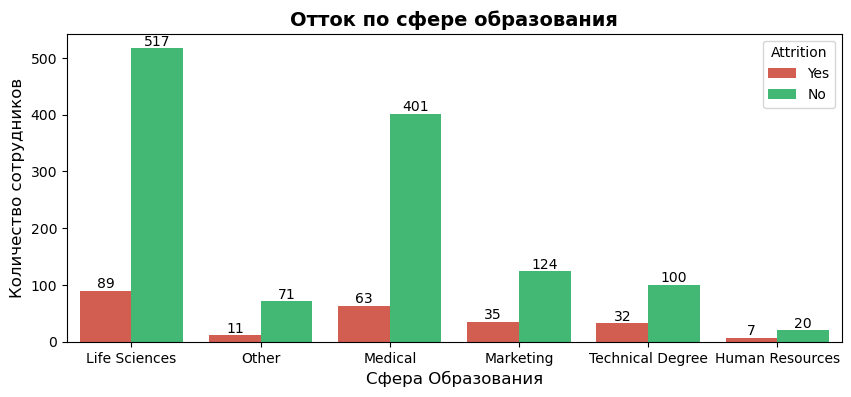

In [57]:
# всего сотрудников в зависимости от образования
print("\n--- Всего сотрудников в зависимости от сферы образования ---\n")
print(df['EducationField'].value_counts())

# Доля и количество ушедших
print("\n--Отток по сфере образования--\n")
print(df.groupby('EducationField')['Attrition'].value_counts())
print(df.groupby('EducationField')['Attrition'].value_counts(normalize=True) * 100)

fig, ax = plt.subplots(figsize=(10, 4))
ax = sns.countplot(data=df, x='EducationField', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
for label in ax.containers:
    ax.bar_label(label)
ax.set_title('Отток по сфере образования', fontsize=14, fontweight='bold')
ax.set_xlabel('Сфера Образования', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)
plt.show()


---Процент ушедших---

EducationField
Human Resources     25.925926
Technical Degree    24.242424
Marketing           22.012579
Life Sciences       14.686469
Medical             13.577586
Other               13.414634
Name: proportion, dtype: float64


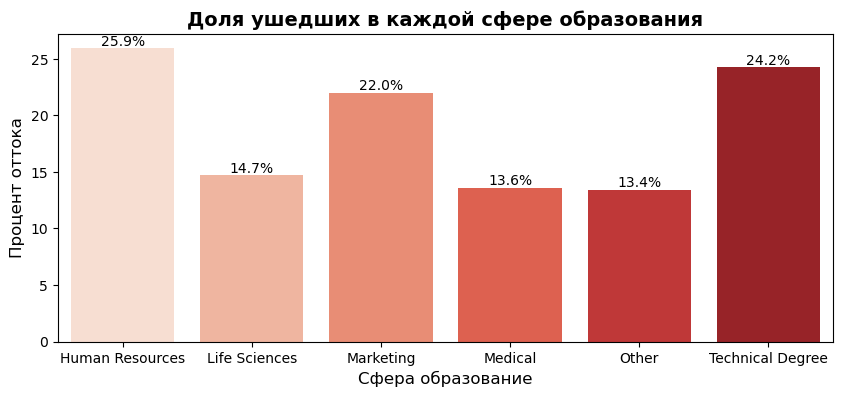

In [58]:
# Доля ушедших внутри каждого образования
print('\n---Процент ушедших---\n')
print((df.groupby('EducationField')['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False))*100)

# график
pct = df.groupby('EducationField')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=pct, x='EducationField', y='Attrition_code', hue='EducationField', palette='Reds')
ax.set_title('Доля ушедших в каждой сфере образования', fontsize=14, fontweight='bold')
ax.set_xlabel('Сфера образование', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%')
plt.show()

**Итог:** Чаще уходят с образованием в сфере Human Resources (25%), Technical Degree (24%) и Marketing (22%).

**Вывод: Чаще уходят с низким и средним уровнем образования и с образованием в сфере Human Resources (25%), Technical Degree (24%) и Marketing (22%)**

### 2.4. Кто уходит - Условия труда
(DistanceFromHome)

#### DistanceFromHome

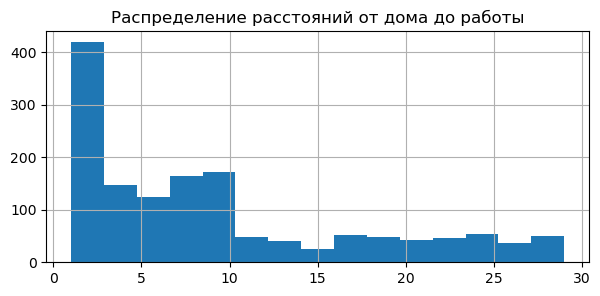

In [59]:
df['DistanceFromHome'].hist(bins=15, figsize=(7, 3)) 
plt.title('Распределение расстояний от дома до работы')
plt.show() 

По гистограмме видно, что основное количество сотрудников живет недалеко от работы.

Теперь посмотрим как разделилась доля ушедших в зависимости от расстояния.

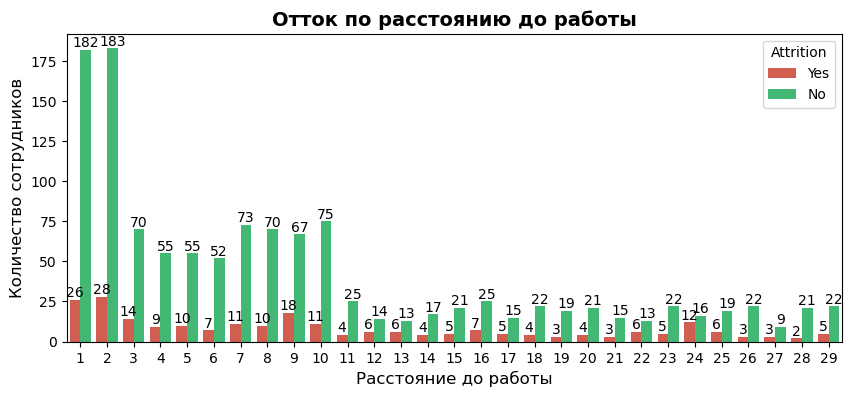

In [60]:
# Доля и количество ушедших
fig, ax = plt.subplots(figsize=(10, 4))
ax = sns.countplot(data=df, x='DistanceFromHome', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
for label in ax.containers:
    ax.bar_label(label)
ax.set_title('Отток по расстоянию до работы', fontsize=14, fontweight='bold')
ax.set_xlabel('Расстояние до работы', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)
plt.show()


---Первые 10 самых больших процент ушедших---

DistanceFromHome
24    42.857143
13    31.578947
22    31.578947
12    30.000000
27    25.000000
17    25.000000
25    24.000000
16    21.875000
9     21.176471
15    19.230769
Name: proportion, dtype: float64


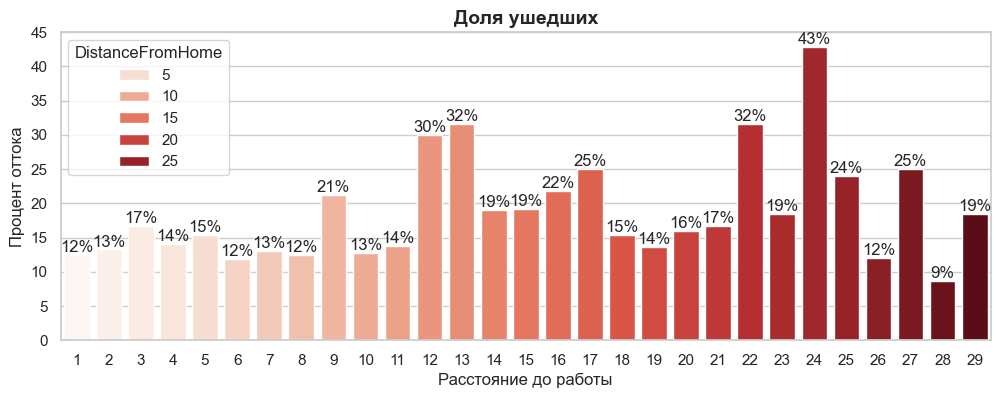

In [373]:
# Доля ушедших внутри каждого образования
print('\n---Первые 10 самых больших процент ушедших---\n')
print((df.groupby('DistanceFromHome')['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False)[:10])*100)

pct = df.groupby('DistanceFromHome')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=pct, x='DistanceFromHome', y='Attrition_code', hue='DistanceFromHome', palette='Reds')
ax.set_title('Доля ушедших', fontsize=14, fontweight='bold')
ax.set_xlabel('Расстояние до работы', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%')
plt.savefig("figures/bar_DistanceFromHome.png", dpi=300)
plt.show()

**Вывод:**  Проценты оттока расспределились почти равномерно. Из чего следует вывод, что **Растояние от дома до работы на отток не влияет**.

### 2.5. Кто уходит - Структура
(Department, JobRole, JobLevel, BusinessTravel)

#### Department

In [62]:
# всего сотрудников в зависимости от образования
print("\n--- Распределение сотрудников по департаментам ---\n")
print(df['Department'].value_counts())


--- Распределение сотрудников по департаментам ---

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64


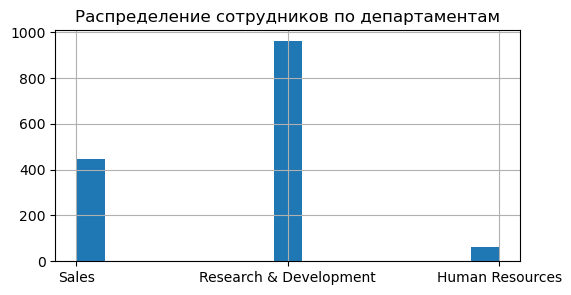

In [63]:
df['Department'].hist(bins=15, figsize=(6, 3)) 
plt.title('Распределение сотрудников по департаментам')
plt.show() 


--Отток по департаментам--


--В абсолютах--

Department              Attrition
Human Resources         No            51
                        Yes           12
Research & Development  No           828
                        Yes          133
Sales                   No           354
                        Yes           92
Name: count, dtype: int64

--В процентах--

Department              Attrition
Human Resources         No           80.952381
                        Yes          19.047619
Research & Development  No           86.160250
                        Yes          13.839750
Sales                   No           79.372197
                        Yes          20.627803
Name: proportion, dtype: float64


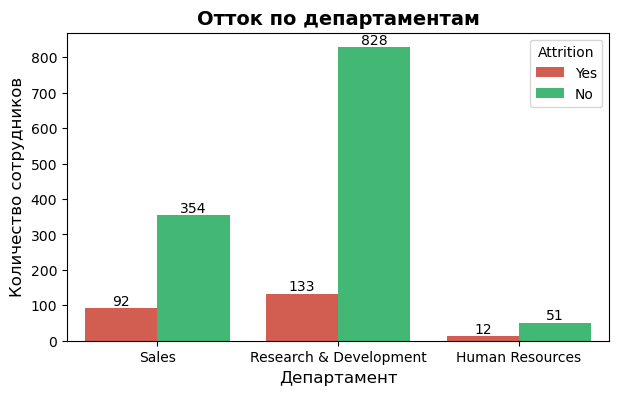

In [64]:
# Доля и количество ушедших
print("\n--Отток по департаментам--\n")
print("\n--В абсолютах--\n")
print(df.groupby('Department')['Attrition'].value_counts())
print("\n--В процентах--\n")
print(df.groupby('Department')['Attrition'].value_counts(normalize=True) * 100)

fig, ax = plt.subplots(figsize=(7, 4))
ax = sns.countplot(data=df, x='Department', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
for label in ax.containers:
    ax.bar_label(label)
ax.set_title('Отток по департаментам', fontsize=14, fontweight='bold')
ax.set_xlabel('Департамент', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)
plt.show()


---Доля ушедших---

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: proportion, dtype: float64


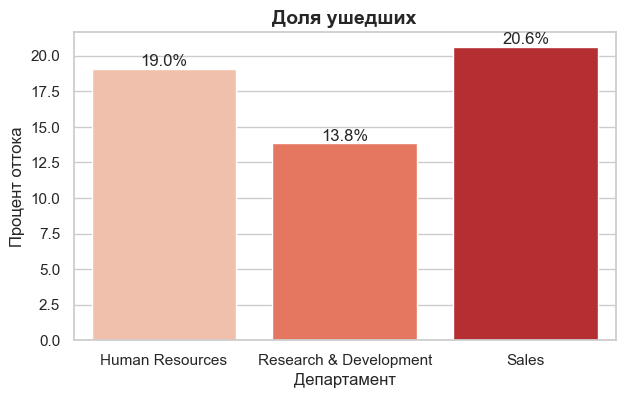

In [372]:
# Доля ушедших внутри каждого департамента
print('\n---Доля ушедших---\n') # отсортированно
print((df.groupby('Department')['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False))*100)

pct = df.groupby('Department')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=pct, x='Department', y='Attrition_code', hue='Department', palette='Reds')
ax.set_title('Доля ушедших', fontsize=14, fontweight='bold')
ax.set_xlabel('Департамент', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%')
plt.savefig("figures/bar_Department.png", dpi=300)
plt.show()

**Итог:** Основной отток идет по департаменту Продаж (20.6%) и HR (19%)

#### JobRole

In [66]:
# всего сотрудников в зависимости от должности
print("\n--- Распределение сотрудников по должностям ---\n")
print(df['JobRole'].value_counts())


--- Распределение сотрудников по должностям ---

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64


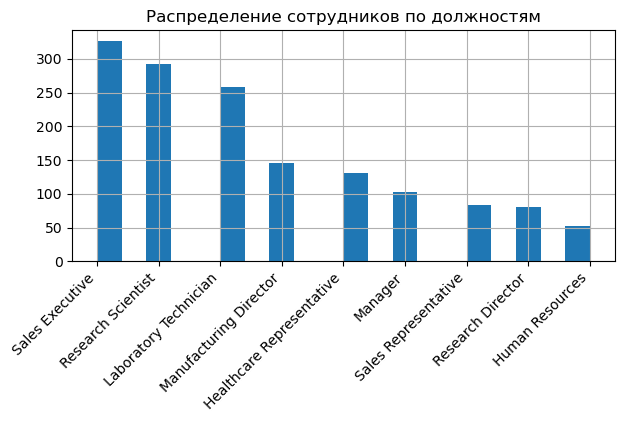

In [67]:
df['JobRole'].hist(bins=20, figsize=(7, 3)) 
plt.title('Распределение сотрудников по должностям')
plt.xticks(rotation=45, ha='right')  # поворот подписей по X
plt.show() 


--Отток по должностям--

--В абсолютах--

JobRole                    Attrition
Healthcare Representative  No           122
                           Yes            9
Human Resources            No            40
                           Yes           12
Laboratory Technician      No           197
                           Yes           62
Manager                    No            97
                           Yes            5
Manufacturing Director     No           135
                           Yes           10
Research Director          No            78
                           Yes            2
Research Scientist         No           245
                           Yes           47
Sales Executive            No           269
                           Yes           57
Sales Representative       No            50
                           Yes           33
Name: count, dtype: int64

--В процентах--

JobRole                    Attrition
Healthcare Representative  No           93.1297

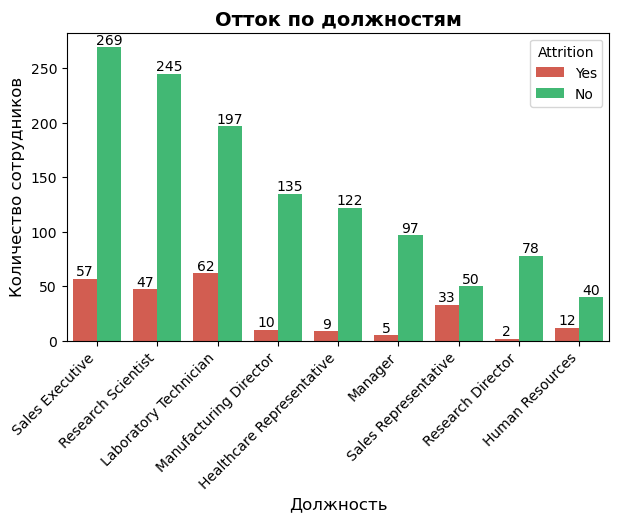

In [68]:
# Доля и количество ушедших
print("\n--Отток по должностям--\n")
print("--В абсолютах--\n")
print(df.groupby('JobRole')['Attrition'].value_counts())
print("\n--В процентах--\n")
print(df.groupby('JobRole')['Attrition'].value_counts(normalize=True) * 100)

fig, ax = plt.subplots(figsize=(7, 4))
ax = sns.countplot(data=df, x='JobRole', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
for label in ax.containers:
    ax.bar_label(label)
ax.set_title('Отток по должностям', fontsize=14, fontweight='bold')
ax.set_xlabel('Должность', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)
plt.xticks(rotation=45, ha='right')  
plt.show()


---Доля ушедших---

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: proportion, dtype: float64


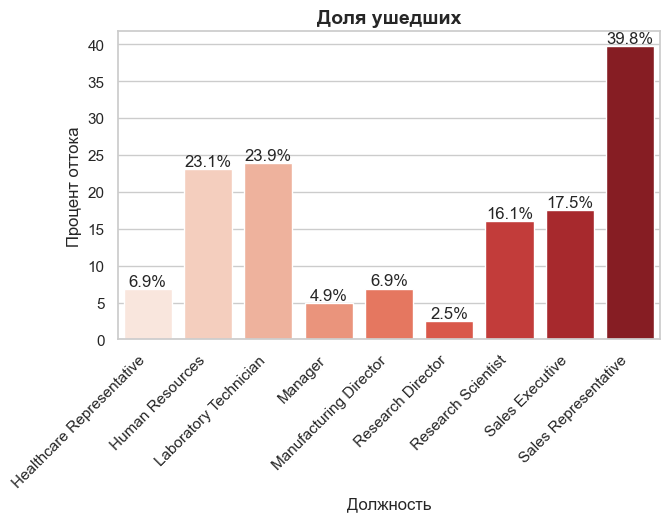

In [371]:
# Доля ушедших внутри каждой должности
print('\n---Доля ушедших---\n')
print((df.groupby('JobRole')['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False))*100)

pct = df.groupby('JobRole')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=pct, x='JobRole', y='Attrition_code', hue='JobRole', palette='Reds')
ax.set_title('Доля ушедших', fontsize=14, fontweight='bold')
ax.set_xlabel('Должность', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%')
plt.xticks(rotation=45, ha='right')
plt.savefig("figures/bar_JobRole.png", dpi=300)
plt.show()

**Итог:** Чаще всего с большим отрывом уходят Торговые представители (39.8), на втором месте по оттоку 23% HR и лаборанты. Меньше всего уходят с руководящих должностей (меньше 7%). Вывод должность для оттока имеет ключевое значение.

#### JobLevel


--- Распределение сотрудников по уровням должности ---

JobLevel
1    543
2    534
3    218
4    106
5     69
Name: count, dtype: int64


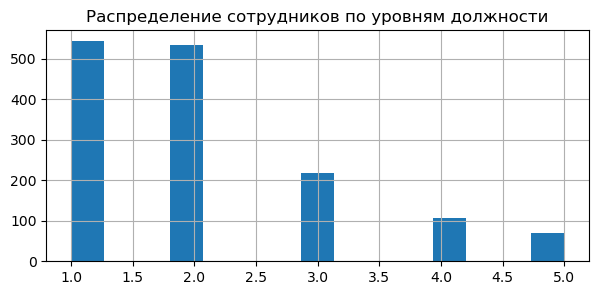

In [70]:
# всего сотрудников в зависимости от уровня должности
print("\n--- Распределение сотрудников по уровням должности ---\n")
print(df['JobLevel'].value_counts())

df['JobLevel'].hist(bins=15, figsize=(7, 3)) 
plt.title('Распределение сотрудников по уровням должности')
plt.show() 


--Отток по уровню должности--

--В абсолютах--

JobLevel  Attrition
1         No           400
          Yes          143
2         No           482
          Yes           52
3         No           186
          Yes           32
4         No           101
          Yes            5
5         No            64
          Yes            5
Name: count, dtype: int64
--В процентах--

JobLevel  Attrition
1         No           73.664825
          Yes          26.335175
2         No           90.262172
          Yes           9.737828
3         No           85.321101
          Yes          14.678899
4         No           95.283019
          Yes           4.716981
5         No           92.753623
          Yes           7.246377
Name: proportion, dtype: float64


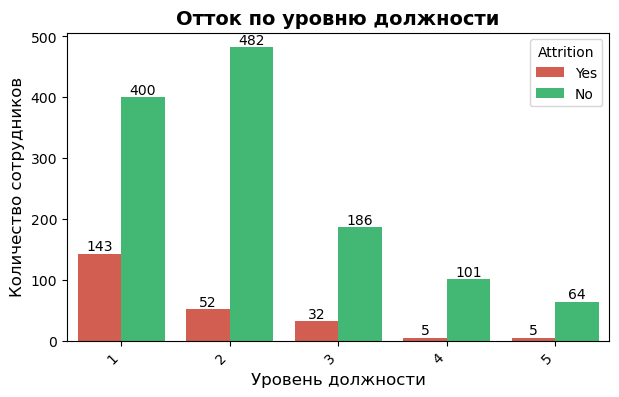

In [71]:
# Доля и количество ушедших
print("\n--Отток по уровню должности--\n")
print("--В абсолютах--\n")
print(df.groupby('JobLevel')['Attrition'].value_counts())
print("--В процентах--\n")
print(df.groupby('JobLevel')['Attrition'].value_counts(normalize=True) * 100)

fig, ax = plt.subplots(figsize=(7, 4))
ax = sns.countplot(data=df, x='JobLevel', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
for label in ax.containers:
    ax.bar_label(label)
ax.set_title('Отток по уровню должности', fontsize=14, fontweight='bold')
ax.set_xlabel('Уровень должности', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)
plt.xticks(rotation=45, ha='right')  
plt.show()


---Процент ушедших---

JobLevel
1    26.335175
3    14.678899
2     9.737828
5     7.246377
4     4.716981
Name: proportion, dtype: float64


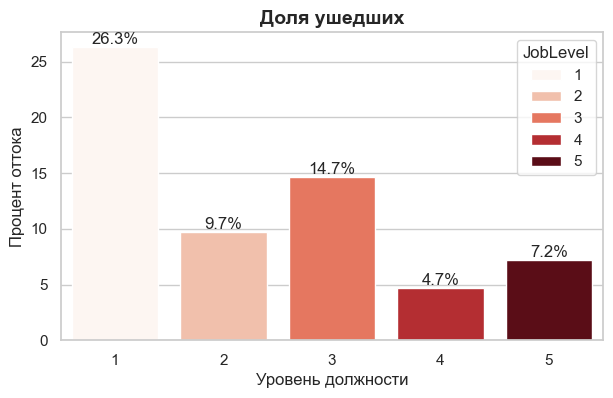

In [370]:
# Доля ушедших внутри каждого уровня должности
print('\n---Процент ушедших---\n')
print((df.groupby('JobLevel')['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False))*100)

pct = df.groupby('JobLevel')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=pct, x='JobLevel', hue='JobLevel', y='Attrition_code', palette='Reds')
ax.set_title('Доля ушедших', fontsize=14, fontweight='bold')
ax.set_xlabel('Уровень должности', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%')
plt.savefig("figures/bar_JobLevel.png", dpi=300)
plt.show()

**Итог:** Чаще уходят с самого низкого уровня должности (26.3%) и реже всего с высоких 4 и 5 (меньше 7.2%). **Вывод: уровень должности имеет значение для оттока**

#### BusinessTravel


--- Распределение сотрудников по частоте командировок ---

BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64


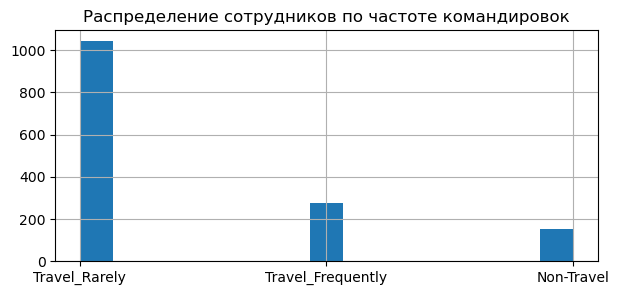

In [73]:
# всего сотрудников в зависимости от частоты командировок
print("\n--- Распределение сотрудников по частоте командировок ---\n")
print(df['BusinessTravel'].value_counts())

df['BusinessTravel'].hist(bins=15, figsize=(7, 3)) 
plt.title('Распределение сотрудников по частоте командировок')
plt.show() 


--Отток по частоте командировок--

--В абсолютах--

BusinessTravel     Attrition
Non-Travel         No           138
                   Yes           12
Travel_Frequently  No           208
                   Yes           69
Travel_Rarely      No           887
                   Yes          156
Name: count, dtype: int64

--В процентах--

BusinessTravel     Attrition
Non-Travel         No           92.000000
                   Yes           8.000000
Travel_Frequently  No           75.090253
                   Yes          24.909747
Travel_Rarely      No           85.043145
                   Yes          14.956855
Name: proportion, dtype: float64


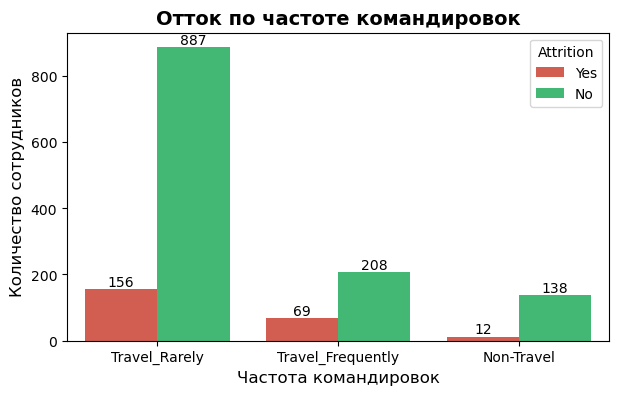

In [74]:
# Доля и количество ушедших
print("\n--Отток по частоте командировок--\n")
print("--В абсолютах--\n")
print(df.groupby('BusinessTravel')['Attrition'].value_counts())
print("\n--В процентах--\n")
print(df.groupby('BusinessTravel')['Attrition'].value_counts(normalize=True) * 100)

fig, ax = plt.subplots(figsize=(7, 4))
ax = sns.countplot(data=df, x='BusinessTravel', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
for label in ax.containers:
    ax.bar_label(label)
ax.set_title('Отток по частоте командировок', fontsize=14, fontweight='bold')
ax.set_xlabel('Частота командировок', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)
plt.show()


---Процент ушедших---

BusinessTravel
Travel_Frequently    24.909747
Travel_Rarely        14.956855
Non-Travel            8.000000
Name: proportion, dtype: float64


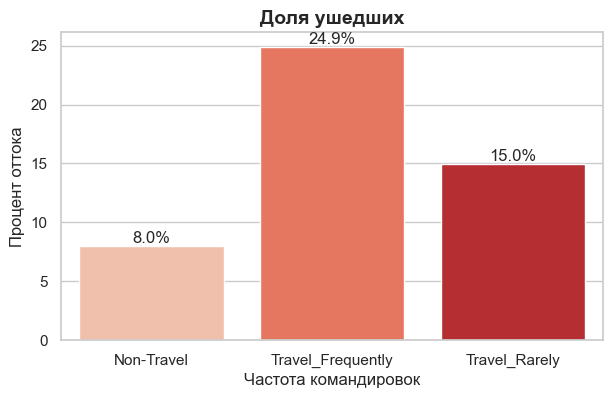

In [369]:
# Доля ушедших внутри каждой группы
print('\n---Процент ушедших---\n')
print((df.groupby('BusinessTravel')['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False))*100)

pct = df.groupby('BusinessTravel')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=pct, x='BusinessTravel', hue='BusinessTravel', y='Attrition_code', palette='Reds')
ax.set_title('Доля ушедших', fontsize=14, fontweight='bold')
ax.set_xlabel('Частота командировок', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%')
plt.savefig("figures/bar_BusinessTravel.png", dpi=300)
plt.show()

**Итог:** Основная часть коллектива - это редко ездящие в коммандировки сотрудники. Чаще уходят те, кто чаще ездит в командировки. **Вывод: Частота командировок влияет.**

**Вывод:**
- **Все структурные признаки** Department, JobRole, JobLevel, BusinessTravel **влияют на отток.**
- Чаще уходят из отдела продаж (20.6%) и HR (19%)
- Чаще всего с большим отрывом уходят торговые представители (39.8%), на втором месте по оттоку (23%) HR и лаборанты
- Чаще всего уходят с низкого уровня должности (26.3%)
- Чем чаще сотрудник ездит в командировки, тем выше отток

### 2.6. Кто уходит - Стаж
(TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager, NumCompaniesWorked)

Попробуем посмотреть все на одном полотне как распределилось количество сотрудников в компании в зависимости от разного вида стажей.

In [76]:
# всего сотрудников в зависимости от стажа (сортировка от большего стажа к меньшему)
print("\n--- Распределение сотрудников по стажу ---\n")

# Общий стаж работы 
print("\n---Общий стаж работы---\n")
print(df['TotalWorkingYears'].value_counts().sort_index(ascending=False).to_frame().T)

# Стаж работы в компании
print("\n---Стаж работы в компании---\n")
print(df['YearsAtCompany'].value_counts().sort_index(ascending=False).to_frame().T)

# Стаж на текущей должности
print("\n---Стаж на текущей должности---\n")
print(df['YearsInCurrentRole'].value_counts().sort_index(ascending=False).to_frame().T)

# Лет с момента последнего повышения
print("\n---Лет с момента последнего повышения---\n")
print(df['YearsSinceLastPromotion'].value_counts().sort_index(ascending=False).to_frame().T)

# Стаж работы с текущим руководителем
print("\n---Стаж работы с текущим руководителем---\n")
print(df['YearsWithCurrManager'].value_counts().sort_index(ascending=False).to_frame().T)

# Количество мест работы
print("\n---Количество мест работы---\n")
print(df['NumCompaniesWorked'].value_counts().sort_index(ascending=False).to_frame().T)


--- Распределение сотрудников по стажу ---


---Общий стаж работы---

TotalWorkingYears  40  38  37  36  35  34  33  32  31  30  ...  9    8   7   \
count               2   1   4   6   3   5   7   9   9   7  ...  96  103  81   

TotalWorkingYears   6   5   4   3   2   1   0   
count              125  88  63  42  31  81  11  

[1 rows x 40 columns]

---Стаж работы в компании---

YearsAtCompany  40  37  36  34  33  32  31  30  29  27  ...  9   8   7   6   \
count            1   1   2   1   5   3   3   1   2   2  ...  82  80  90  76   

YearsAtCompany   5    4    3    2    1   0   
count           196  110  128  127  171  44  

[1 rows x 37 columns]

---Стаж на текущей должности---

YearsInCurrentRole  18  17  16  15  14  13  12  11  10  9   8    7   6   5   \
count                2   4   7   8  11  14  10  22  29  67  89  222  37  36   

YearsInCurrentRole   4    3    2   1    0   
count               104  135  372  57  244  

---Лет с момента последнего повышения---

YearsSinceLastProm

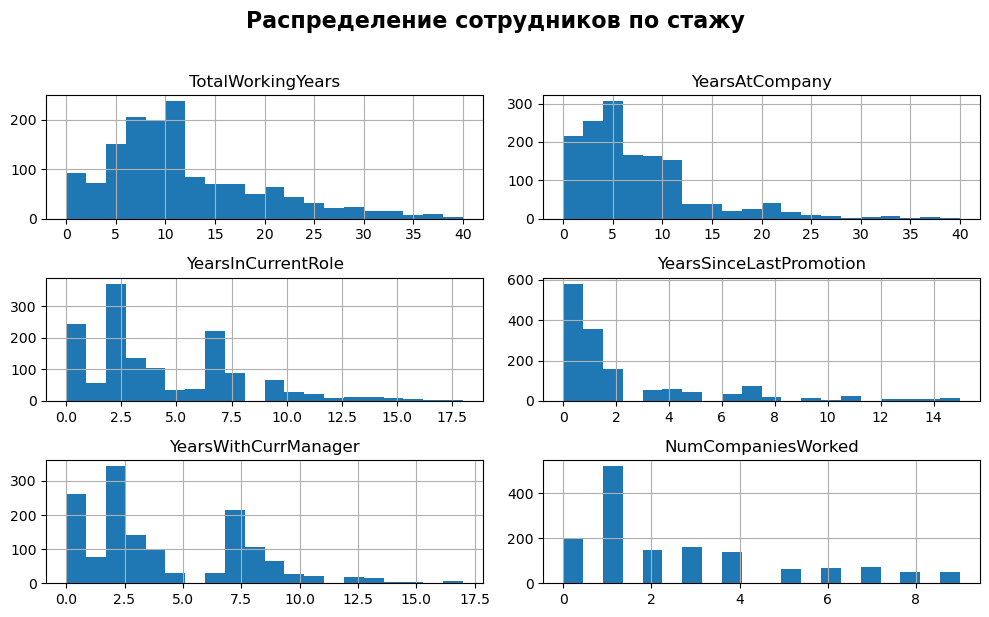

In [77]:
# Теперь на графике
axes = df[['TotalWorkingYears', 'YearsAtCompany',
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 
    'YearsWithCurrManager', 'NumCompaniesWorked']].hist(bins=20, figsize=(10, 6))

fig = axes.ravel()[0].figure          
fig.suptitle('Распределение сотрудников по стажу', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout() 
plt.show()

Так как видно, что есть выбросы в распределении, лучше изобразить все с помощью ящика с усами.

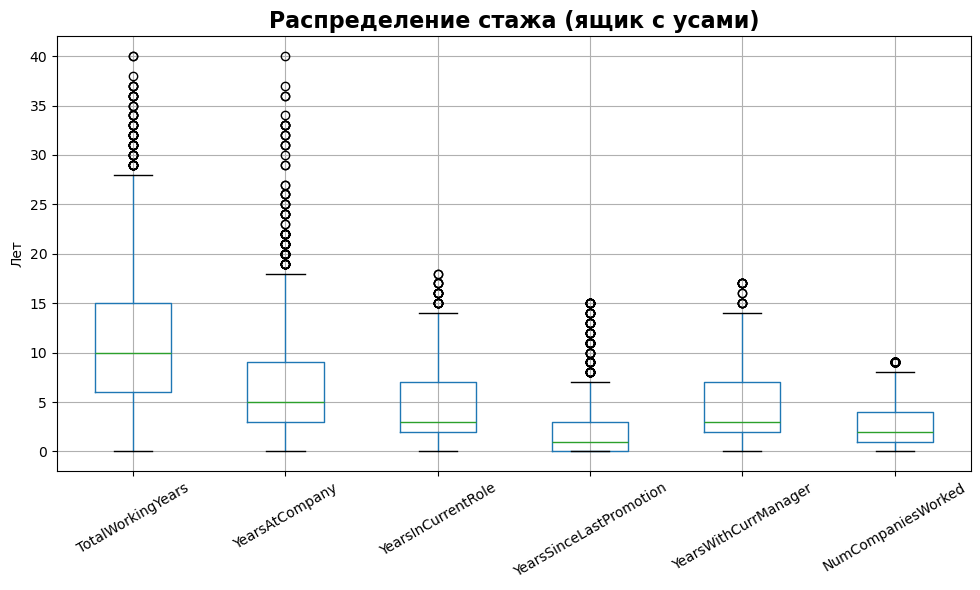

In [78]:
# визуализация боксплот
cols = ['TotalWorkingYears', 'YearsAtCompany',
        'YearsInCurrentRole', 'YearsSinceLastPromotion',
        'YearsWithCurrManager', 'NumCompaniesWorked']

fig, ax = plt.subplots(figsize=(10, 6))
df[cols].boxplot(ax=ax, rot=30)
ax.set_title('Распределение стажа (ящик с усами)', fontsize=16, fontweight='bold')
ax.set_ylabel('Лет')
plt.tight_layout()
plt.show()

**Вывод:**
видим, что в компании присутствуют сотрудники, которые имеют большой стаж, но их мало и на нашем ящике с усами они показались как выбросы, но для нашей аналитики такие "долгожители" я считаю ценны, так как показывают, что есть сотрудники которые не смотря не на что остаются лояльными к работе и не уходят. 

Но основную часть персонала все же составляют сотрудники:
- с общим стажем работы от 7 до 15 лет
- лет в компании от 3 до 9
- лет в текущей должности: 2-7
- лет с последнего повышения: 0-3
- лет с текущим руководителем: 2-7 
- Количество мест работы: от 1 до 4

Теперь **посмотрим как распределился отток** в зависимости от стажа. Посмотрим каждый отдельно.

#### Общий стаж

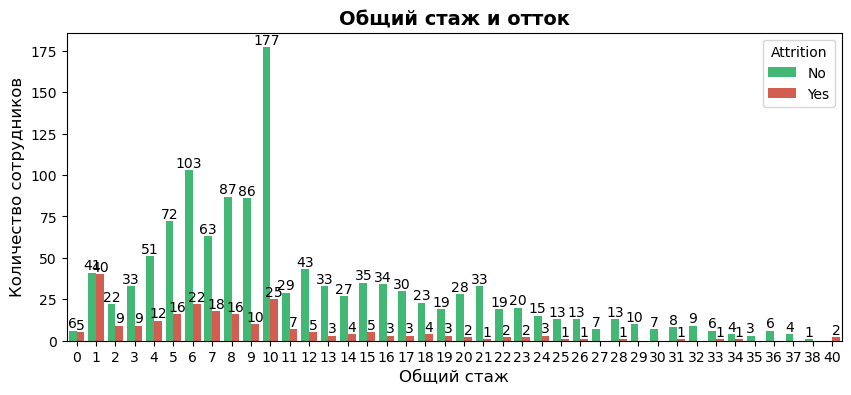

In [79]:
# Общий стаж и отток
fig, ax = plt.subplots(figsize=(10, 4))
ax = sns.countplot(data=df, x='TotalWorkingYears', hue='Attrition', palette=['#2ecc71', '#e74c3c'])
for label in ax.containers:
    ax.bar_label(label)
ax.set_title('Общий стаж и отток', fontsize=14, fontweight='bold')
ax.set_xlabel('Общий стаж', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)
plt.show()

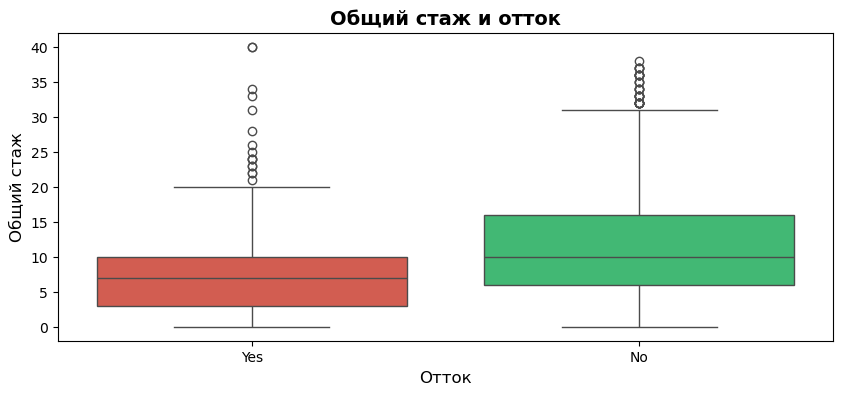

In [80]:
# Общий стаж и отток (боксплот)
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df, x='Attrition', y='TotalWorkingYears', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
ax.set_title('Общий стаж и отток', fontsize=14, fontweight='bold')
ax.set_xlabel('Отток', fontsize=12)
ax.set_ylabel('Общий стаж', fontsize=12)
plt.show()

Распределение долей с обозначением 95-го перцентила (линия, за которой аномальные значения)

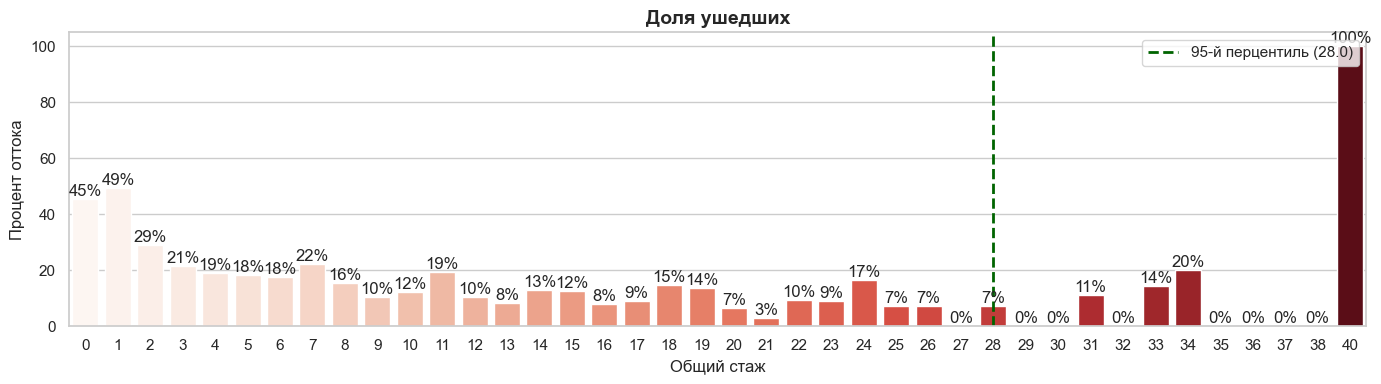

In [368]:
pct = df.groupby('TotalWorkingYears')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

q95 = df['TotalWorkingYears'].quantile(0.95)

fig, ax = plt.subplots(figsize=(14, 4))
sns.barplot(data=pct, x='TotalWorkingYears', hue='TotalWorkingYears', y='Attrition_code', legend=False, palette='Reds')
ax.axvline(q95, color='darkgreen', linestyle='--', linewidth=2, label=f'95-й перцентиль ({q95:.1f})')
ax.set_title('Доля ушедших', fontsize=14, fontweight='bold')
ax.set_xlabel('Общий стаж', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig("figures/bar_TotalWorkingYears.png", dpi=300)
plt.show()

**Итог по общему стажу:** 
- Логично, что сотрудник отработавший общий стаж 40 лет в 100% случаях уходит, предполагается на пенсию.
- Нулевой процент оттока за небольшим исключением у "долгожителей".
- Самые большие проценты оттока у сотрудников с небольшим общим стажем.
- **Общий стаж влияет на отток**

#### Стаж в компании

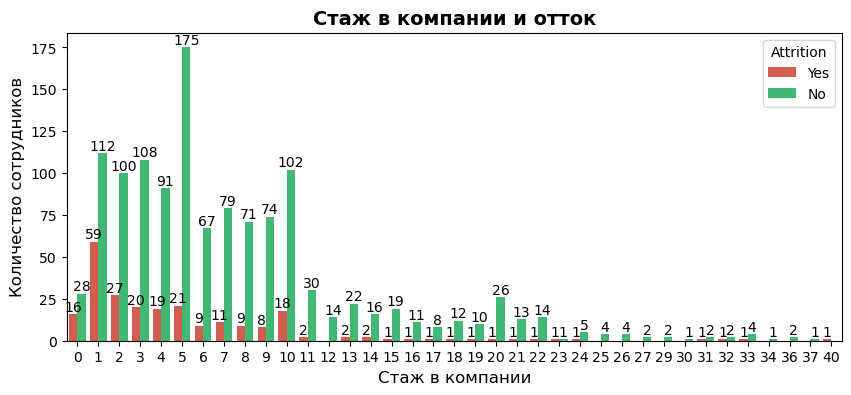

In [82]:
# Стаж в компании и отток
fig, ax = plt.subplots(figsize=(10, 4))
ax = sns.countplot(data=df, x='YearsAtCompany', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
for label in ax.containers:
    ax.bar_label(label)
ax.set_title('Стаж в компании и отток', fontsize=14, fontweight='bold')
ax.set_xlabel('Стаж в компании', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)
plt.show()

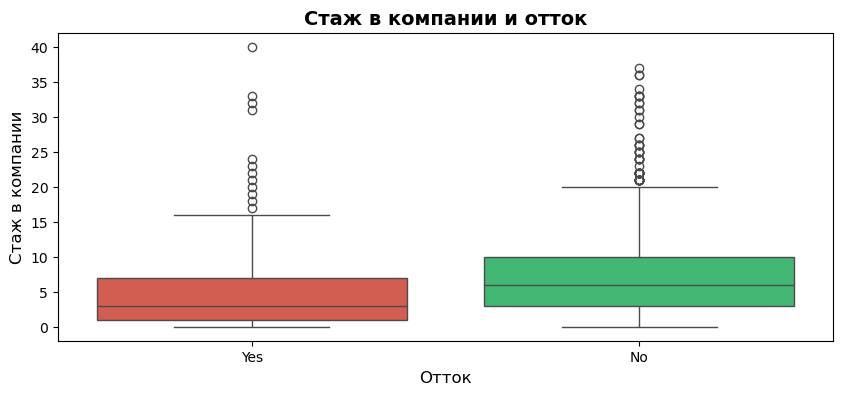

In [83]:
# Стаж в компании и отток (боксплот)
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df, x='Attrition', y='YearsAtCompany', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
ax.set_title('Стаж в компании и отток', fontsize=14, fontweight='bold')
ax.set_xlabel('Отток', fontsize=12)
ax.set_ylabel('Стаж в компании', fontsize=12)
plt.show()

Распределение долей с обозначением 95-го перцентила (линия, за которой аномальные значения)

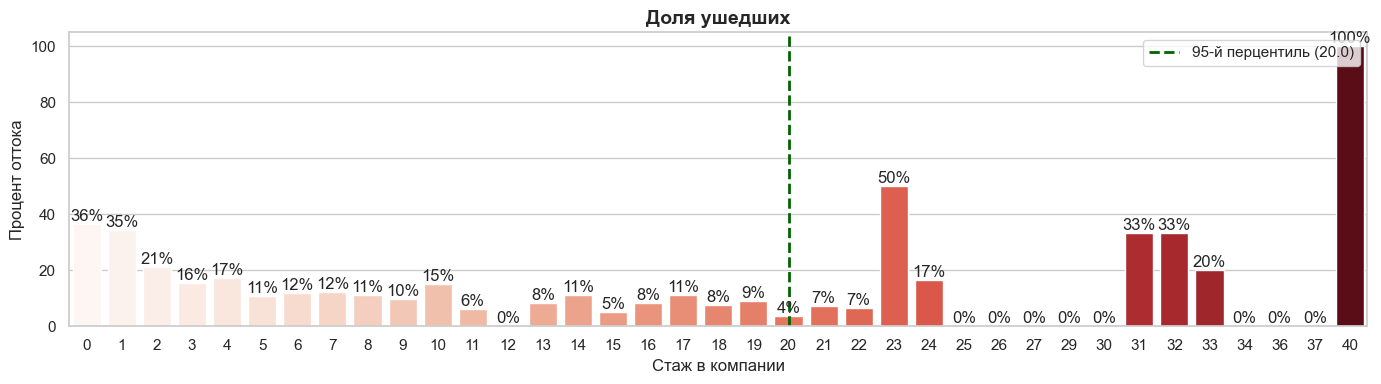

In [367]:
pct = df.groupby('YearsAtCompany')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

q95 = df['YearsAtCompany'].quantile(0.95)

fig, ax = plt.subplots(figsize=(14, 4))
sns.barplot(data=pct, x='YearsAtCompany', hue='YearsAtCompany', y='Attrition_code', legend=False, palette='Reds')
ax.axvline(q95, color='darkgreen', linestyle='--', linewidth=2, label=f'95-й перцентиль ({q95:.1f})')
ax.set_title('Доля ушедших', fontsize=14, fontweight='bold')
ax.set_xlabel('Стаж в компании', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig("figures/bar_YearsAtCompany.png", dpi=300)
plt.show()

**Итог по стажу в компании:** 
- Тот же, что и в случае с общим стажем
- Видим также, что сотрудник отработавший в компании стаж 40 лет в 100% случаях уходит.
- Также нулевой процент оттока за небольшим исключением у "долгожителей".
- Самые большие проценты оттока у сотрудников с небольшим стажем в компании.
- **Стаж в компании влияет на отток**

#### Стаж в текущей должности и отток

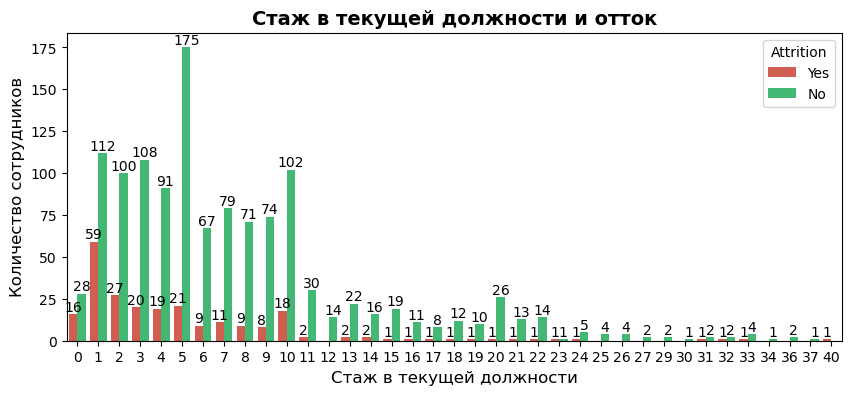

In [85]:
# Стаж в текущей должности и отток
fig, ax = plt.subplots(figsize=(10, 4))
ax = sns.countplot(data=df, x='YearsAtCompany', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
for label in ax.containers:
    ax.bar_label(label)
ax.set_title('Стаж в текущей должности и отток', fontsize=14, fontweight='bold')
ax.set_xlabel('Стаж в текущей должности', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)
plt.show()

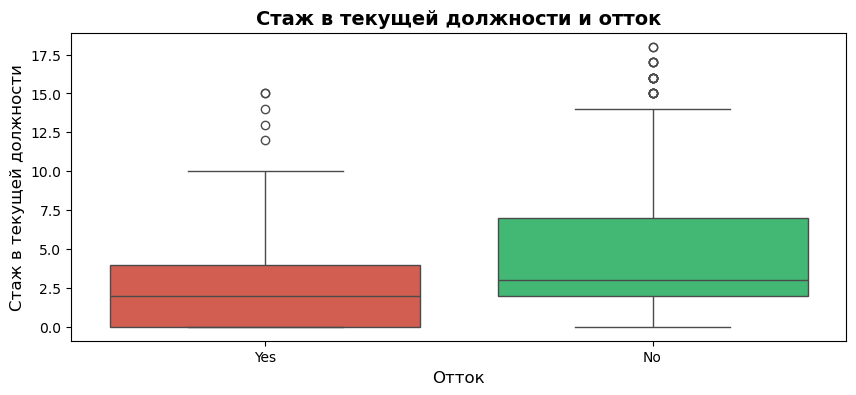

In [86]:
# Стаж в компании и отток (боксплот)
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df, x='Attrition', y='YearsInCurrentRole', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
ax.set_title('Стаж в текущей должности и отток', fontsize=14, fontweight='bold')
ax.set_xlabel('Отток', fontsize=12)
ax.set_ylabel('Стаж в текущей должности', fontsize=12)
plt.show()

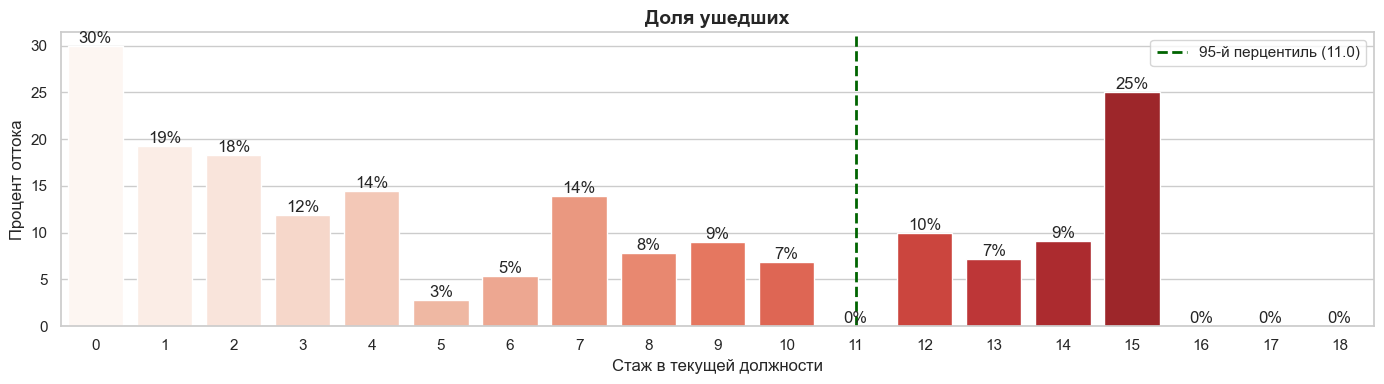

In [366]:
pct = df.groupby('YearsInCurrentRole')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

q95 = df['YearsInCurrentRole'].quantile(0.95)

fig, ax = plt.subplots(figsize=(14, 4))
sns.barplot(data=pct, x='YearsInCurrentRole', hue='YearsInCurrentRole', y='Attrition_code', legend=False, palette='Reds')
ax.axvline(q95, color='darkgreen', linestyle='--', linewidth=2, label=f'95-й перцентиль ({q95:.1f})')
ax.set_title('Доля ушедших', fontsize=14, fontweight='bold')
ax.set_xlabel('Стаж в текущей должности', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig("figures/bar_YearsInCurrentRole.png", dpi=300)
plt.show()

**Итог стажу в текущей должности:**
- Чем дольше в должности, тем реже уходят.
- Самый большой отток на 0–2 годах - новички в должности уходят в чаще, чем те, кто проработал 5+ лет.
- Хвост 12–15 лет - шум.
- **Стаж в текущей должности влияет.**

#### Лет с последнего повышения

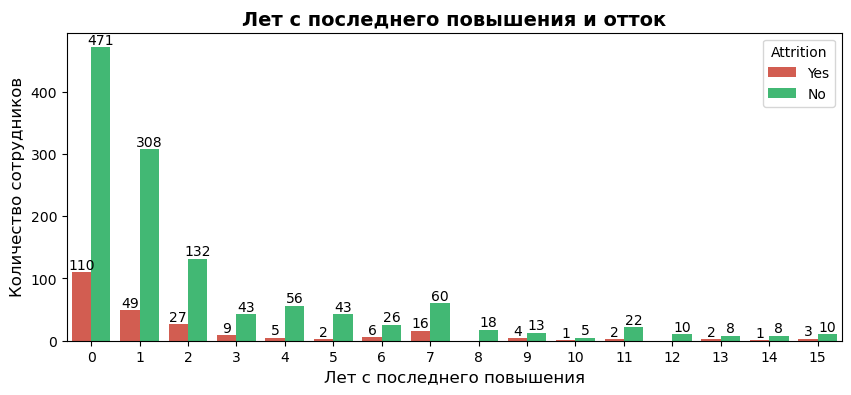

In [88]:
# Лет с последнего повышения и отток
fig, ax = plt.subplots(figsize=(10, 4))
ax = sns.countplot(data=df, x='YearsSinceLastPromotion', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
for label in ax.containers:
    ax.bar_label(label)
ax.set_title('Лет с последнего повышения и отток', fontsize=14, fontweight='bold')
ax.set_xlabel('Лет с последнего повышения', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)
plt.show()

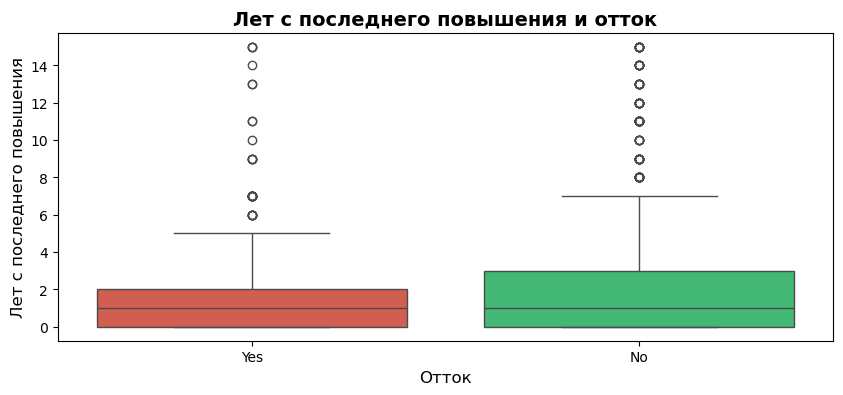

In [89]:
# Лет с последнего повышения и отток (боксплот)
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df, x='Attrition', y='YearsSinceLastPromotion', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
ax.set_title('Лет с последнего повышения и отток', fontsize=14, fontweight='bold')
ax.set_xlabel('Отток', fontsize=12)
ax.set_ylabel('Лет с последнего повышения', fontsize=12)
plt.show()

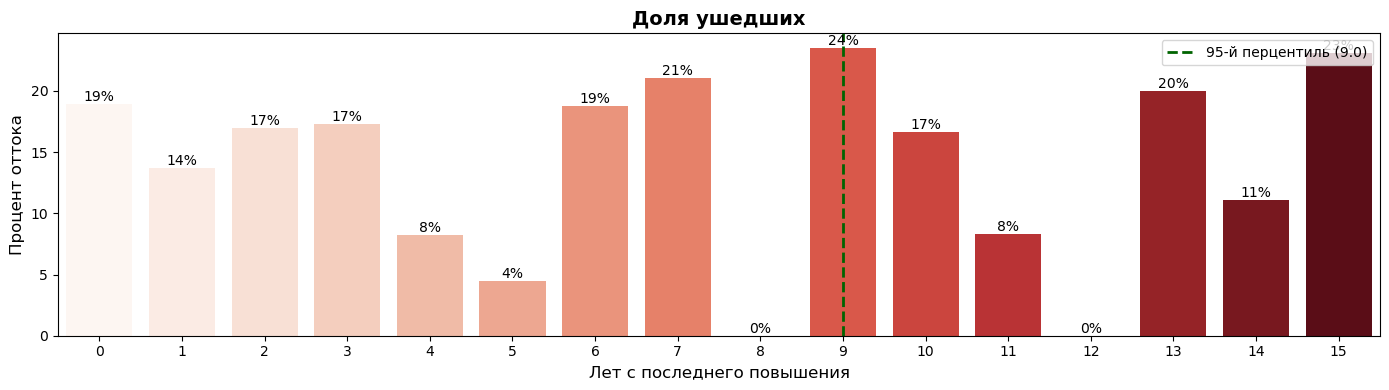

In [90]:
# распределение долей ушедших
pct = df.groupby('YearsSinceLastPromotion')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

q95 = df['YearsSinceLastPromotion'].quantile(0.95)

fig, ax = plt.subplots(figsize=(14, 4))
sns.barplot(data=pct, x='YearsSinceLastPromotion', hue='YearsSinceLastPromotion', y='Attrition_code', legend=False, palette='Reds')
ax.axvline(q95, color='darkgreen', linestyle='--', linewidth=2, label=f'95-й перцентиль ({q95:.1f})')
ax.set_title('Доля ушедших', fontsize=14, fontweight='bold')
ax.set_xlabel('Лет с последнего повышения', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [91]:
# Доля ушедших внутри каждой группы отсортированные по убыванию
print('\n---Процент ушедших---\n')
print((df.groupby('YearsSinceLastPromotion')['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False))*100)


---Процент ушедших---

YearsSinceLastPromotion
9     23.529412
15    23.076923
7     21.052632
13    20.000000
0     18.932874
6     18.750000
3     17.307692
2     16.981132
10    16.666667
1     13.725490
14    11.111111
11     8.333333
4      8.196721
5      4.444444
Name: proportion, dtype: float64


**Итог по годам с последнего повышения:**

Явной линейной связи между числом лет с последнего повышения и оттоком не обнаружено. Отток минимален в группе 4-5 лет без повышения (4-8%) и повышается как у недавно повышенных (0-2 года, 14-19%), так и у давно не повышавшихся (6-7 лет, 19-21%). Скорее всего сам по себе карьерный застой не влияет на отток, он идет бок о бок с признаком "Сколько лет в текущей должности", и надо ориентироваться на него либо его надо смотреть совместно с другими признаками, например удовлетворенностью.
- **Сколько лет с последнего повышения НЕ влияет.**

#### Лет с текущим руководителем

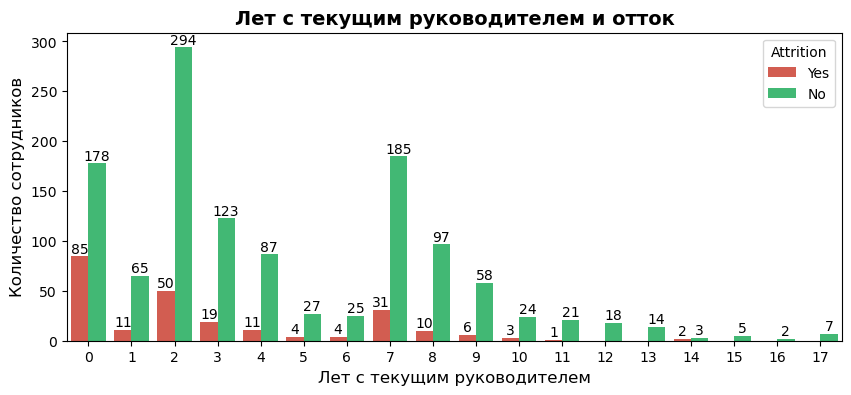

In [92]:
# Лет с текущим руководителем  и отток
fig, ax = plt.subplots(figsize=(10, 4))
ax = sns.countplot(data=df, x='YearsWithCurrManager', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
for label in ax.containers:
    ax.bar_label(label)
ax.set_title('Лет с текущим руководителем и отток', fontsize=14, fontweight='bold')
ax.set_xlabel('Лет с текущим руководителем', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)
plt.show()

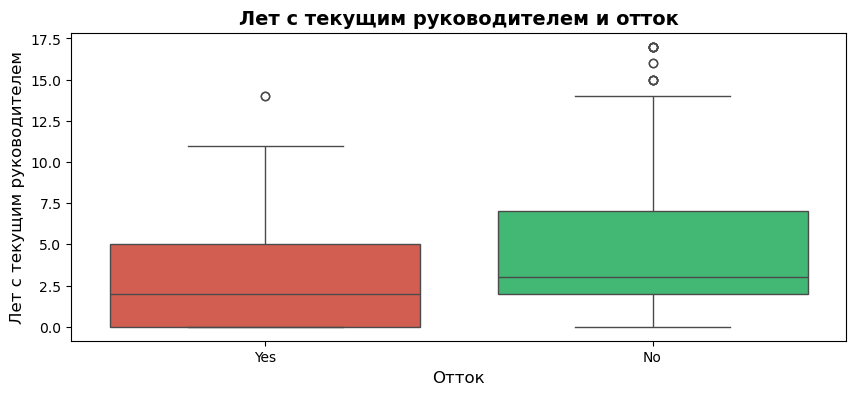

In [93]:
# Лет с текущим руководителем и отток (боксплот)
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df, x='Attrition', y='YearsWithCurrManager', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
ax.set_title('Лет с текущим руководителем и отток', fontsize=14, fontweight='bold')
ax.set_xlabel('Отток', fontsize=12)
ax.set_ylabel('Лет с текущим руководителем', fontsize=12)
plt.show()

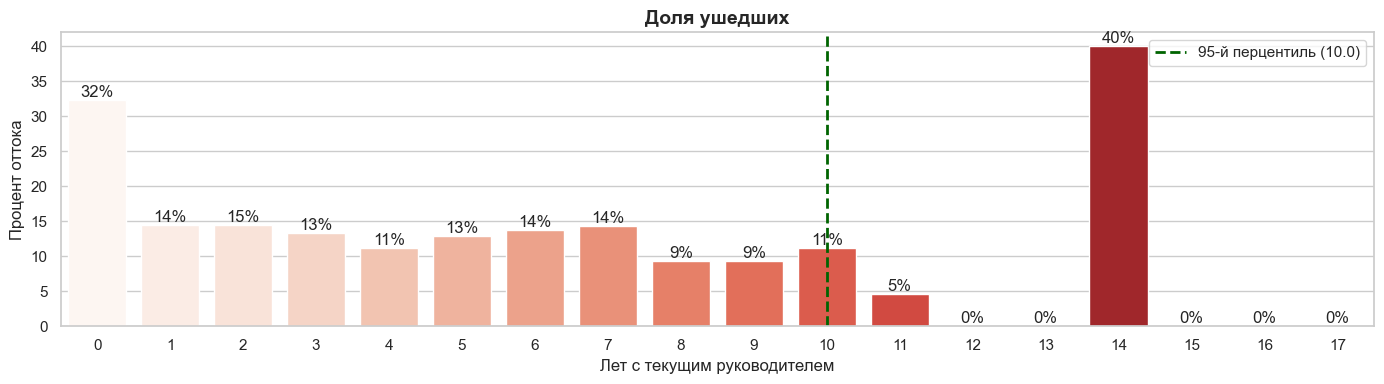

In [365]:
pct = df.groupby('YearsWithCurrManager')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

q95 = df['YearsWithCurrManager'].quantile(0.95)

fig, ax = plt.subplots(figsize=(14, 4))
sns.barplot(data=pct, x='YearsWithCurrManager', hue='YearsWithCurrManager', y='Attrition_code', legend=False, palette='Reds')
ax.axvline(q95, color='darkgreen', linestyle='--', linewidth=2, label=f'95-й перцентиль ({q95:.1f})')
ax.set_title('Доля ушедших', fontsize=14, fontweight='bold')
ax.set_xlabel('Лет с текущим руководителем', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig("figures/bar_YearsWithCurrManager.png", dpi=300)
plt.show()

In [95]:
# Доля ушедших внутри каждой группы отсортированные по убыванию
print('\n---Процент ушедших---\n')
print((df.groupby('YearsWithCurrManager')['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False))*100)


---Процент ушедших---

YearsWithCurrManager
14    40.000000
0     32.319392
2     14.534884
1     14.473684
7     14.351852
6     13.793103
3     13.380282
5     12.903226
4     11.224490
10    11.111111
9      9.375000
8      9.345794
11     4.545455
Name: proportion, dtype: float64


**Итог по годам с текущим руководителем:**
- Это один из самых сильных сигналов среди всех стажевых признаков. Смена/появление руководителя - критический период.
- Отток на 0 лет = 32.3% - это в 2-2.5 раза выше, чем у всех остальных групп. Пока это самый мощный эффект из всех, что мы видели по стажевым признакам (YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion).
- Дальше - плавное затухание. С 1 до 11 лет отток медленно падает с 14% до 5%. Линейный тренд слабый, но устойчивый.
- Ядро лояльных - 8-11 лет с одним менеджером (отток 4.5-11%). Эти люди почти не уходят.
- Строка 14 лет (40%) - это шум малой группы, не сигнал.
- Линейная зависимость - тренд есть, но слабый, основной эффект сидит в точке 0.
- **Стаж с текущим руководителем влияет. 0 - самый сильный предсказатель оттока.**

#### Количество поменяных компаний

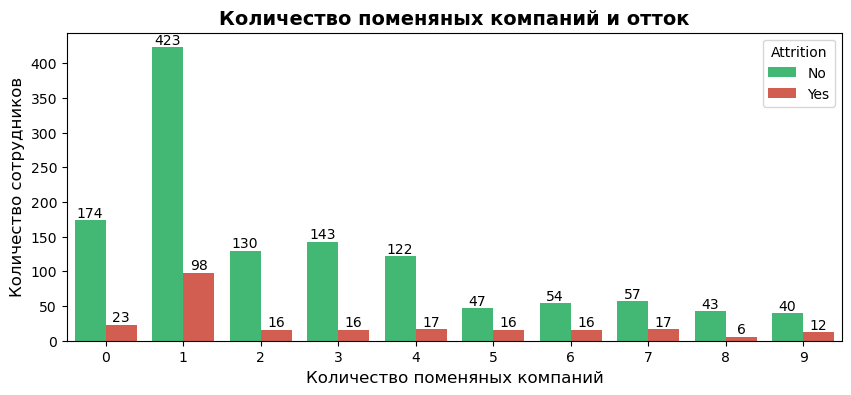

In [96]:
# Количество поменяных компаний и отток
fig, ax = plt.subplots(figsize=(10, 4))
ax = sns.countplot(data=df, x='NumCompaniesWorked', hue='Attrition', palette=['#2ecc71', '#e74c3c'])
for label in ax.containers:
    ax.bar_label(label)
ax.set_title('Количество поменяных компаний и отток', fontsize=14, fontweight='bold')
ax.set_xlabel('Количество поменяных компаний', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)
plt.show()

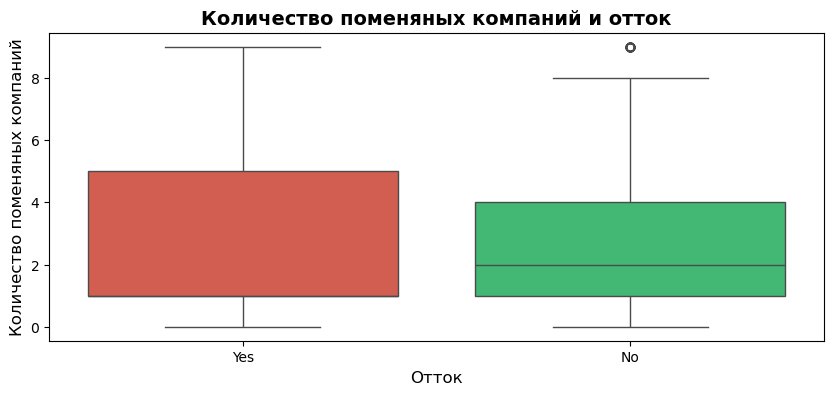

In [97]:
# Стаж в компании и отток (боксплот)
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df, x='Attrition', y='NumCompaniesWorked', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
ax.set_title('Количество поменяных компаний и отток', fontsize=14, fontweight='bold')
ax.set_xlabel('Отток', fontsize=12)
ax.set_ylabel('Количество поменяных компаний', fontsize=12)
plt.show()

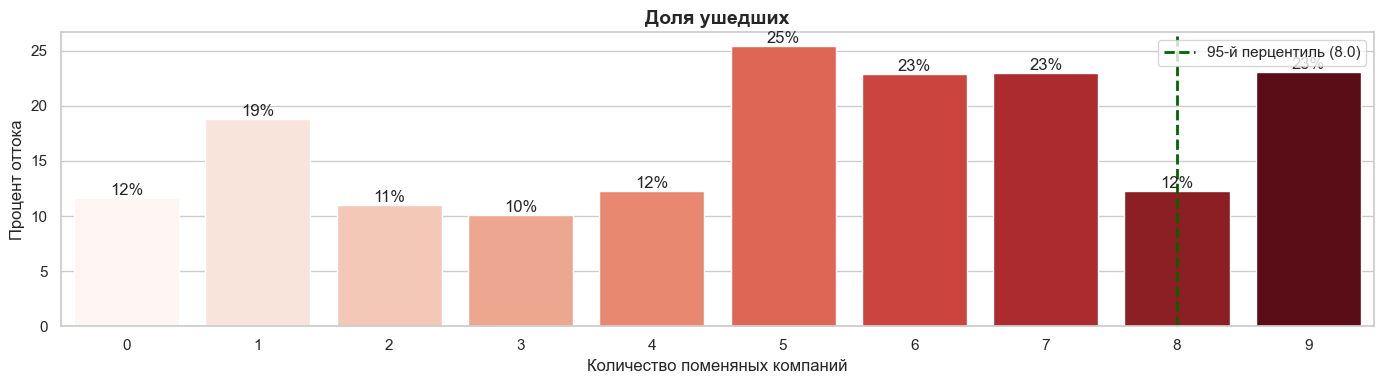

In [363]:
pct = df.groupby('NumCompaniesWorked')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

q95 = df['NumCompaniesWorked'].quantile(0.95)

fig, ax = plt.subplots(figsize=(14, 4))
sns.barplot(data=pct, x='NumCompaniesWorked', hue='NumCompaniesWorked', y='Attrition_code', legend=False, palette='Reds')
ax.axvline(q95, color='darkgreen', linestyle='--', linewidth=2, label=f'95-й перцентиль ({q95:.1f})')
ax.set_title('Доля ушедших', fontsize=14, fontweight='bold')
ax.set_xlabel('Количество поменяных компаний', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig("figures/bar_NumCompaniesWorked.png", dpi=300)
plt.show()

In [99]:
# Доля ушедших внутри каждой группы отсортированные по убыванию
print('\n---Процент ушедших---\n')
print((df.groupby('NumCompaniesWorked')['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False))*100)


---Процент ушедших---

NumCompaniesWorked
5    25.396825
9    23.076923
7    22.972973
6    22.857143
1    18.809981
8    12.244898
4    12.230216
0    11.675127
2    10.958904
3    10.062893
Name: proportion, dtype: float64


**Итог по количество поменяных компаний:**
- Обнаружен пороговый эффект: сотрудники, сменившие 5 и более компаний, уходят значительно чаще (23-25%) по сравнению с теми, кто сменил 0-4 компании (10–12%)
- **Пометка** Можно будет создать признак для использования в модели как бинарный флаг NumCompaniesWorked ≥ 5, а не как непрерывную переменную
- **Количество поменяных компаний влияет.**

#### Общий вывод по второму шагу:
- Анализ шести признаков, связанных со стажем, показал, что отток сотрудников определяется преимущественно "свежестью" их положения:
    - Все три стажевых признака (TotalWorkingYears, YearsAtCompany, YearsInCurrentRole) сильно скоррелированы между собой и дают одинаковую картину. У новичков отток в 2-4 раза выше, чем у "старожилов". Возможно это связано с проблемами в адаптации либо неоправдавшимися ожиданиями.
    - Наибольший риск наблюдается у сотрудников, недавно приступивших к работе или к взаимодействию с новым руководителем. Отток при YearsWithCurrManager = 0 составляет 32.3%, при YearsAtCompany = 0 - 36.4%, при TotalWorkingYears = 0-1 - 45-49%, что в 3-4 раза превышает средний уровень по компании.
    - По мере роста стажа отток монотонно снижается и достигает минимума (5-12%) после 5-6 лет в компании, должности или с руководителем.
    - Самый сильный сигнал - YearsWithCurrManager = 0. Отток 32.3% - выше, чем у любого другого признака в точке 0. Это не просто новичок, это человек без устоявшихся отношений с руководителем. Смена руководителя и первый контакт - критическая точка. Практический смысл: работа с руководителем важнее, чем работа с компанией или должностью.
    - Стаж без повышения (YearsSinceLastPromotion) не показывает линейного тренда: отток минимален при 4–5 годах без повышения и повышается как у недавно повышенных, так и у давно не повышавшихся. На отток не влияет.
    - Число предыдущих компаний (NumCompaniesWorked) демонстрирует пороговый эффект: при 5+ компаниях отток достигает 23-25% против 10-12% у сменивших 0-4 компании.

**Рекомендация:** приоритетными точками HR-вмешательства являются онбординг новых сотрудников и период смены руководителя. Для дальнейшей работы прогнозной модели достаточно включить YearsWithCurrManager, YearsInCurrentRole и бинарный флаг NumCompaniesWorked ≥ 5 - остальные стажевые признаки избыточны из-за высокой корреляции.

**Ключевая мысль**

**Уходят не "старые", а "новые" - и в первую очередь те, у кого ещё не сложились отношения с руководителем.**

## Шаг 3: Почему уходят — поведенческие и другие факторы (в том числе гипотеза про сизонные биоритмы)

**Цель:** найти поведенческие и другие драйверы оттока.

### 3.1. Почему уходят - Компенсация (материальная составляющая)
(MonthlyIncome, DailyRate, HourlyRate, MonthlyRate, PercentSalaryHike, StockOptionLevel)

**Цель:** проверить классические факторы.

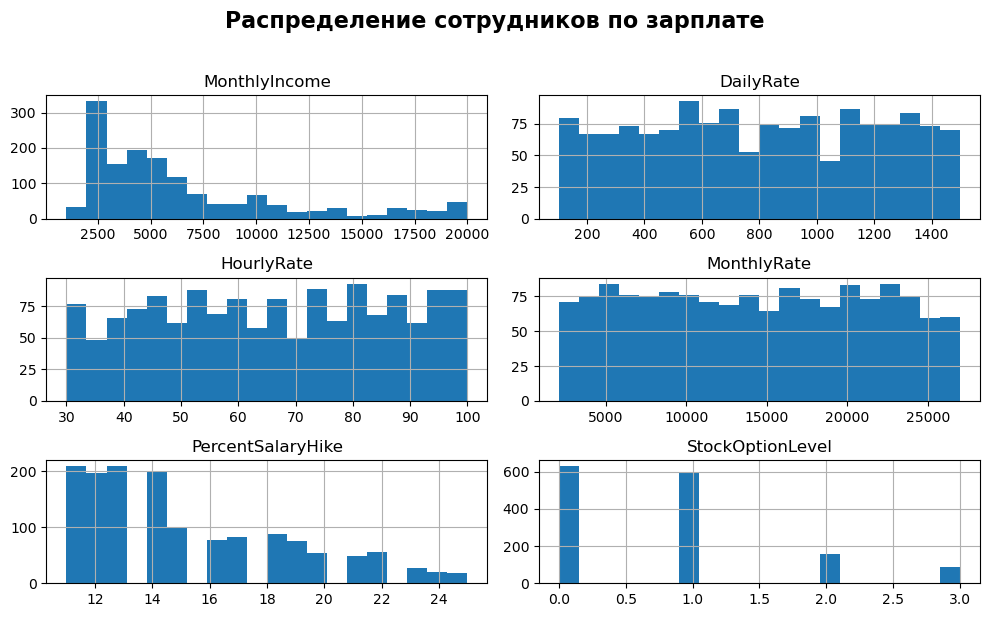

In [100]:
# Распределение
axes = df[['MonthlyIncome', 'DailyRate',
    'HourlyRate', 'MonthlyRate', 
    'PercentSalaryHike', 'StockOptionLevel']].hist(bins=20, figsize=(10, 6))

fig = axes.ravel()[0].figure          
fig.suptitle('Распределение сотрудников по зарплате', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout() 
plt.show()

In [101]:
df[['MonthlyIncome', 'DailyRate',
    'HourlyRate', 'MonthlyRate', 
    'PercentSalaryHike', 'StockOptionLevel']].corr()

,MonthlyIncome,DailyRate,HourlyRate,MonthlyRate,PercentSalaryHike,StockOptionLevel
MonthlyIncome,1.000000,0.007707,-0.015794,0.034814,-0.027269,0.005408
DailyRate,0.007707,1.000000,0.023381,-0.032182,0.022704,0.042143
HourlyRate,-0.015794,0.023381,1.000000,-0.015297,-0.009062,0.050263
MonthlyRate,0.034814,-0.032182,-0.015297,1.000000,-0.006429,-0.034323
PercentSalaryHike,-0.027269,0.022704,-0.009062,-0.006429,1.000000,0.007528
StockOptionLevel,0.005408,0.042143,0.050263,-0.034323,0.007528,1.000000


все *Rate показатели не коррелируют с месячной зарплатой, значит на нее не влияют и являются просто шумом. К тому же по распределению видно, что у них оно равномерное, что говорит о том, что это просто синтетические данные.

На всяки случай проверим, действительно ли эти три признаки шум в данных 

In [102]:
from scipy.stats import chi2_contingency

for col in ['DailyRate', 'HourlyRate', 'MonthlyRate']:
    b = pd.qcut(df[col], q=5, duplicates='drop')
    table = pd.crosstab(b, df['Attrition'])
    chi2, p, _, _ = chi2_contingency(table)
    print(f'{col}: chi2={chi2:.2f}, p={p:.4f}')

DailyRate: chi2=6.77, p=0.1485
HourlyRate: chi2=5.78, p=0.2160
MonthlyRate: chi2=3.20, p=0.5250


У всех трёх p > 0.05 — гипотеза "не влияют" подтверждена статистически.

При подготовке данных к модели надо будет их удалить, чтобы не создать переобучения

### Ежемесячный доход и отток.
(MonthlyIncome)

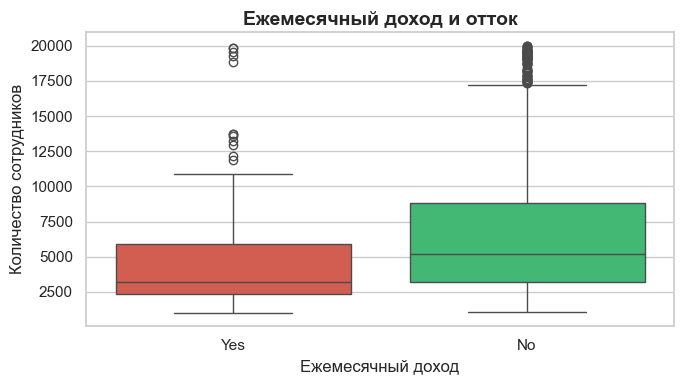

In [364]:
# так как это непрерывная величина строим ящик с усами
fig, ax = plt.subplots(figsize=(7, 4))

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition', 
            palette=['#e74c3c', '#2ecc71'], ax=ax)

ax.set_title('Ежемесячный доход и отток', fontsize=14, fontweight='bold')
ax.set_xlabel('Ежемесячный доход', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)
plt.tight_layout()
plt.savefig("figures/bar_MonthlyIncome.png", dpi=300)
plt.show()

Из-за непрерывности величины зарплаты **сделаем бакеты по доходным квантилям**

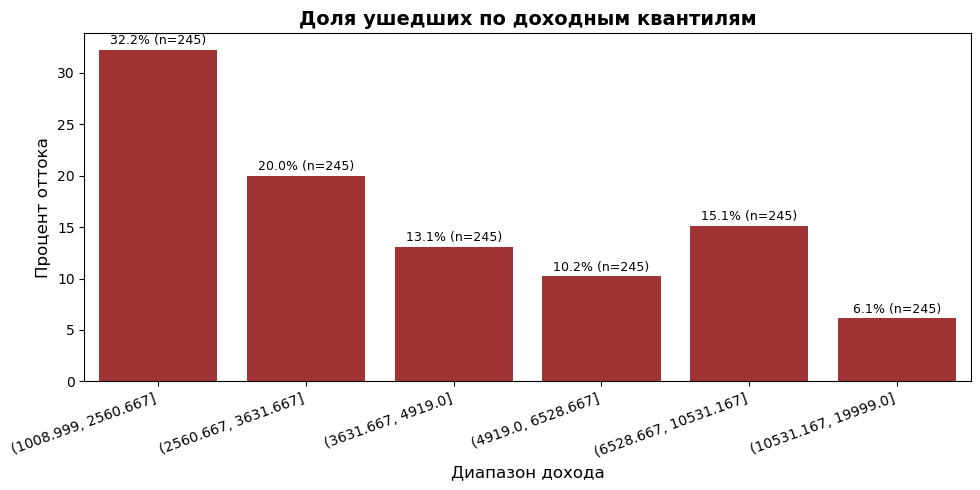

In [104]:
df['IncomeBucket'] = pd.qcut(df['MonthlyIncome'], q=6, duplicates='drop')

pct = (df.groupby('IncomeBucket', observed=True)['Attrition_code']
         .agg(n='count', pct=lambda s: s.mean() * 100)
         .reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=pct, x='IncomeBucket', y='pct',
            color='firebrick', ax=ax)

for c, n in zip(ax.containers, pct['n']):
    ax.bar_label(c, labels=[f'{v:.1f}% (n={n})' for v in pct['pct']],
                 fontsize=9, padding=2)

plt.xticks(rotation=20, ha='right')
ax.set_title('Доля ушедших по доходным квантилям',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Диапазон дохода', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
plt.tight_layout()
plt.show()

In [105]:
# Доля ушедших внутри каждой группы отсортированные по убыванию
print('\n---Процент ушедших---\n')
print((df.groupby('IncomeBucket', observed=True)['Attrition']
    .value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False))*100)


---Процент ушедших---

IncomeBucket
(1008.999, 2560.667]     32.244898
(2560.667, 3631.667]     20.000000
(6528.667, 10531.167]    15.102041
(3631.667, 4919.0]       13.061224
(4919.0, 6528.667]       10.204082
(10531.167, 19999.0]      6.122449
Name: proportion, dtype: float64


**Вывод:**
- Читается четкая линейная зависимость оттока от зарплаты - Чем ниже зарплата, тем чаще уходят. 
- **Зарплата на отток ВЛИЯЕТ**

### Ежедневная, почасовая и ежемесячная ставка и отток.
(DailyRate, HourlyRate, MonthlyRate)

Не смотря на то, что мы уже решили, что эти признаки являются шумом убедимся в этом еще раз, посмотрев как распредеоляться данные в разрезе по оттоку. И для наглядности посмотрим на ежемесячный доход, чтобы сравнить.

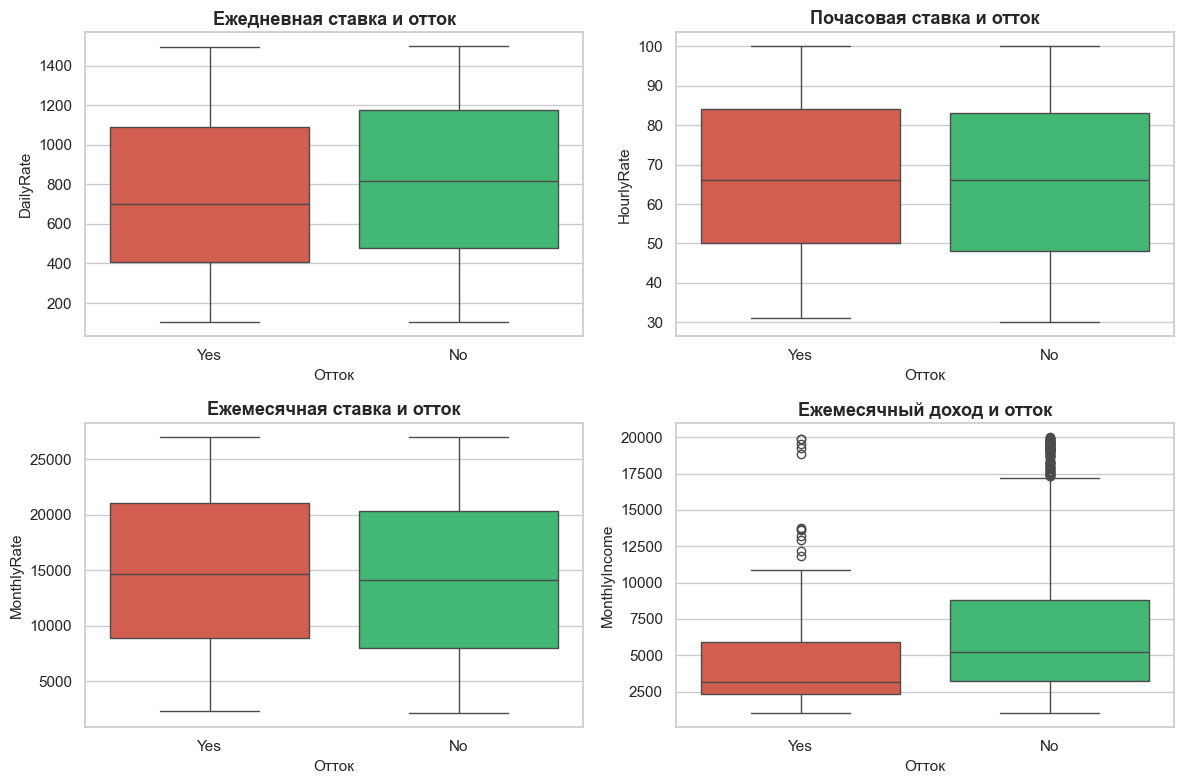

In [362]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()  # превращаем в плоский список [ax0, ax1, ax2, ax3]

# Ежедневная ставка и отток
sns.boxplot(data=df, x='Attrition', y='DailyRate', hue='Attrition',
            palette=['#e74c3c', '#2ecc71'], legend=False, ax=axes[0])
axes[0].set_title('Ежедневная ставка и отток', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Отток', fontsize=11)
axes[0].set_ylabel('DailyRate', fontsize=11)

# Почасовая ставка и отток
sns.boxplot(data=df, x='Attrition', y='HourlyRate', hue='Attrition',
            palette=['#e74c3c', '#2ecc71'], legend=False, ax=axes[1])
axes[1].set_title('Почасовая ставка и отток', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Отток', fontsize=11)
axes[1].set_ylabel('HourlyRate', fontsize=11)

# Ежемесячная ставка и отток
sns.boxplot(data=df, x='Attrition', y='MonthlyRate', hue='Attrition',
            palette=['#e74c3c', '#2ecc71'], legend=False, ax=axes[2])
axes[2].set_title('Ежемесячная ставка и отток', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Отток', fontsize=11)
axes[2].set_ylabel('MonthlyRate', fontsize=11)

# Ежемесячный доход (для сравнения — он реально связан с оттоком)
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition',
            palette=['#e74c3c', '#2ecc71'], legend=False, ax=axes[3])
axes[3].set_title('Ежемесячный доход и отток', fontsize=13, fontweight='bold')
axes[3].set_xlabel('Отток', fontsize=11)
axes[3].set_ylabel('MonthlyIncome', fontsize=11)

plt.tight_layout()
plt.savefig("figures/bar_Rates.png", dpi=300)
plt.show()

**Вывод:**
- Видим, что действительно данные распределились равномерно среди ушедших и неушедших. Что видно и в сравнении с графиком зарплаты, где данные с меньшей зарплатой смечены к ушедшим.
- Гипотеза шума подтверждена. ***Rate признаки не влияют на отток.**

### Процентное повышение заработной платы и отток.
(PercentSalaryHike)

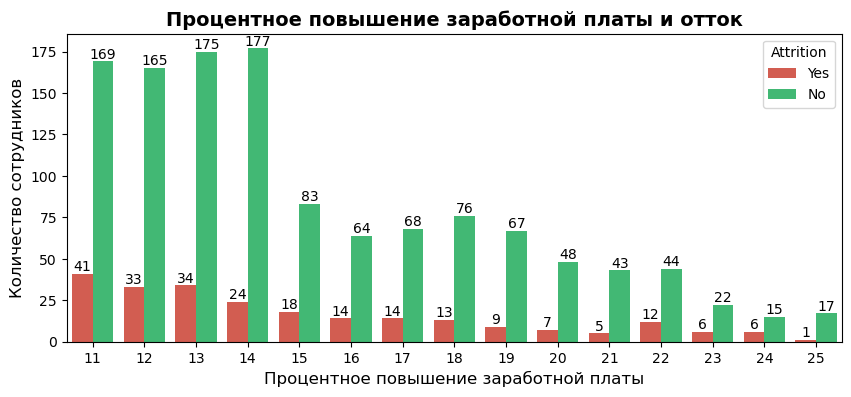

In [107]:
# Процентное повышение заработной платы  и отток
fig, ax = plt.subplots(figsize=(10, 4))
ax = sns.countplot(data=df, x='PercentSalaryHike', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
for label in ax.containers:
    ax.bar_label(label)
ax.set_title('Процентное повышение заработной платы и отток', fontsize=14, fontweight='bold')
ax.set_xlabel('Процентное повышение заработной платы', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)
plt.show()

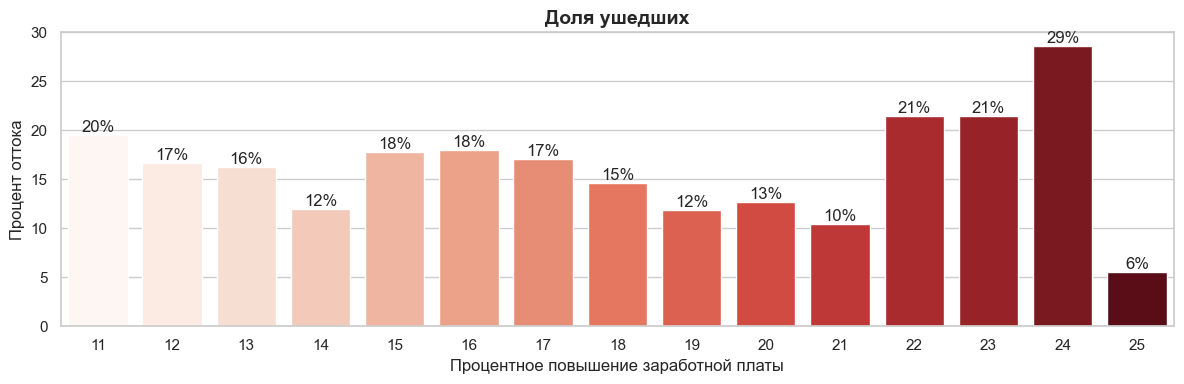

In [361]:
pct = df.groupby('PercentSalaryHike')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=pct, x='PercentSalaryHike', hue='PercentSalaryHike', y='Attrition_code', legend=False, palette='Reds')
ax.set_title('Доля ушедших', fontsize=14, fontweight='bold')
ax.set_xlabel('Процентное повышение заработной платы', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%')
plt.tight_layout()
plt.savefig("figures/bar_PercentSalaryHike.png", dpi=300)
plt.show()

In [109]:
# Доля ушедших внутри каждой группы отсортированные по убыванию
print('\n---Процент ушедших---\n')
print((df.groupby('PercentSalaryHike')['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False))*100)


---Процент ушедших---

PercentSalaryHike
24    28.571429
22    21.428571
23    21.428571
11    19.523810
16    17.948718
15    17.821782
17    17.073171
12    16.666667
13    16.267943
18    14.606742
20    12.727273
14    11.940299
19    11.842105
21    10.416667
25     5.555556
Name: proportion, dtype: float64


На графике тренда не наблюдается, показатели прыгают, что говорит о том, что это скорее всего это шум и влияния этого признака на отток нет.

На всякий случай проверим статистически.

In [110]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['PercentSalaryHike'], df['Attrition'])
chi2, p, dof, _ = chi2_contingency(table)
print(f'chi2={chi2:.2f}, p={p:.4f}')

chi2=13.35, p=0.4990


**Вывод:**
- p > 0.05 - значит признак шум
- **Процентное повышение заработной платы НЕ влияет**

### Уровень опционов на акции и отток.
(StockOptionLevel)

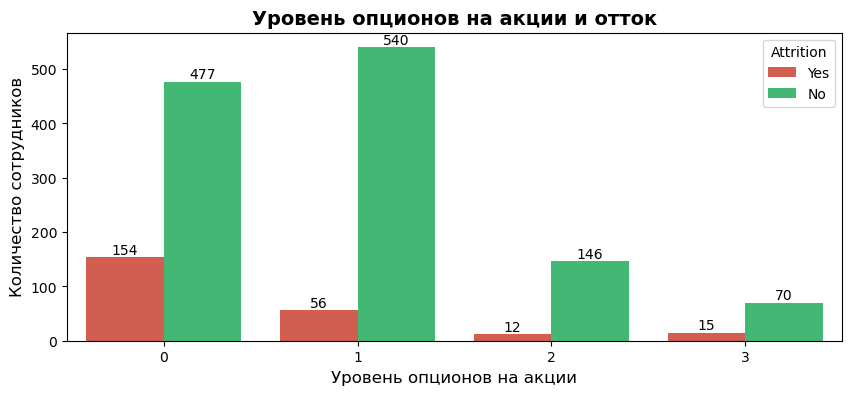

In [111]:
# Лет с текущим руководителем  и отток
fig, ax = plt.subplots(figsize=(10, 4))
ax = sns.countplot(data=df, x='StockOptionLevel', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
for label in ax.containers:
    ax.bar_label(label)
ax.set_title('Уровень опционов на акции и отток', fontsize=14, fontweight='bold')
ax.set_xlabel('Уровень опционов на акции', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)
plt.show()

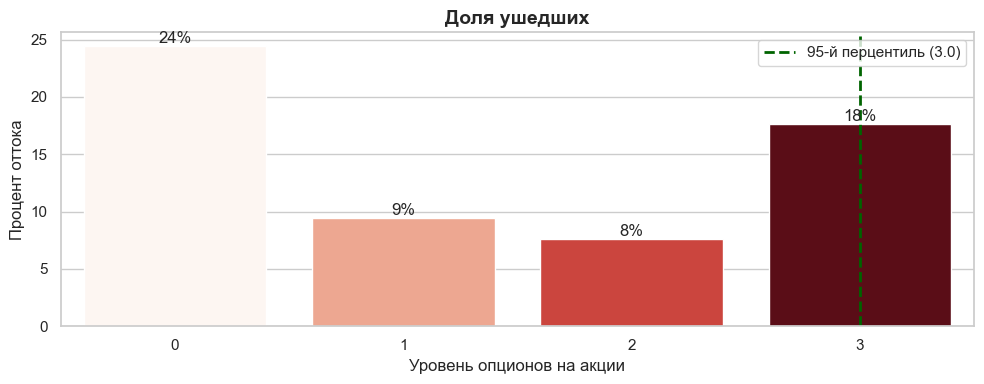

In [360]:
pct = df.groupby('StockOptionLevel')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

q95 = df['StockOptionLevel'].quantile(0.95)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=pct, x='StockOptionLevel', hue='StockOptionLevel', y='Attrition_code', legend=False, palette='Reds')
ax.axvline(q95, color='darkgreen', linestyle='--', linewidth=2, label=f'95-й перцентиль ({q95:.1f})')
ax.set_title('Доля ушедших', fontsize=14, fontweight='bold')
ax.set_xlabel('Уровень опционов на акции', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig("figures/bar_StockOptionLevel.png", dpi=300)
plt.show()

In [113]:
# Доля ушедших внутри каждой группы отсортированные по убыванию
print('\n---Процент ушедших---\n')
print((df.groupby('StockOptionLevel')['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False))*100)


---Процент ушедших---

StockOptionLevel
0    24.405705
3    17.647059
1     9.395973
2     7.594937
Name: proportion, dtype: float64


**Вывод:** 
- Наличие опционов >= 1 значимо связано с оттоком: доля ушедших падает с 24.4% среди сотрудников без опционов до 7.6–9.4% среди тех, у кого они есть. Эффект устойчив и один из сильнейших в датасете. Cвязь линейна, хотя уровень 3 демонстрирует аномально высокий отток (17.6%), но это просто малочисленная группа, что свидетельствует линия 95-го квантиля
- Этот признак — второй по силе после YearsWithCurrManager = 0. Обязательно включить в модель.

**Рекомендация:** Для модели рекомендуется создать бинарный признак HasStock

### 3.2. Почему уходят - Поведение и удовлетворённость
(OverTime, JobSatisfaction, EnvironmentSatisfaction, RelationshipSatisfaction, WorkLifeBalance, JobInvolvement, TrainingTimesLastYear, Overall_Satisfaction)

#### Отток и удовлетворенность
(JobSatisfaction, EnvironmentSatisfaction, RelationshipSatisfaction, WorkLifeBalance, JobInvolvement, Overall_Satisfaction)

Overall_Satisfaction (общая удовлетворенность) - наша целевая переменная для другой модели, поэтому мы ее ни в анализе оттока, ни в модели оттока использовать не будем, так как она мультиколлинеарна со всеми пятью признаками удовлетворенности

Сначала посмотрим на корреляцию всех признаков удовлетворенности

In [114]:
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
            'RelationshipSatisfaction', 'WorkLifeBalance',
            'JobInvolvement']
df[sat_cols].corr().round(2)

,JobSatisfaction,EnvironmentSatisfaction,RelationshipSatisfaction,WorkLifeBalance,JobInvolvement
JobSatisfaction,1.00,-0.01,-0.01,-0.02,-0.02
EnvironmentSatisfaction,-0.01,1.00,0.01,0.03,-0.01
RelationshipSatisfaction,-0.01,0.01,1.00,0.02,0.03
WorkLifeBalance,-0.02,0.03,0.02,1.00,-0.01
JobInvolvement,-0.02,-0.01,0.03,-0.01,1.00


Корреляции нет, поэтому будем рассматривать каждый признак.

Посмотрим как распределилось количество сотрудников по признакам.

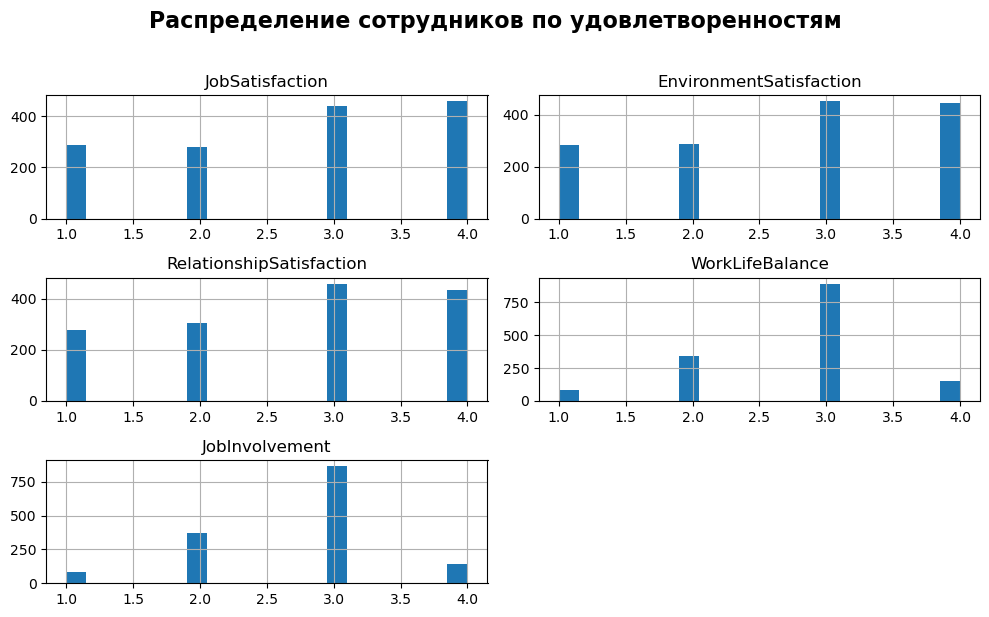

In [115]:
# Распределение
axes = df[sat_cols].hist(bins=20, figsize=(10, 6))

fig = axes.ravel()[0].figure          
fig.suptitle('Распределение сотрудников по удовлетворенностям', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout() 
plt.show()

Видим, что распределения удовлетворенностей работой, отношениями и условиями труда выглядят одинаково: Есть перевес по количеству сотрудников на отметке 3 и 4, но с небольшим перевесом к 1 и 2. Итог: **число удовлетворенных и неудовлетворенных почти одинаково**, с небольшим перевесом в сторону удовлетворенных

Распределение Баланса между работой и личной жизнью и Вовлеченностью в работу так же выглядят похоже друг на друга: Основное число сотрудников ставит эти два показателя на значении 3, этот показатель заметно преобладает над другими. Высокой отметки 4 и низких 1 и 2 очень маленькое количество. Итог: **Основное число сотрудников оценивает свою вовлеченность и баланс между работой и жизнью на 3**

Теперь посмотрим как распределились показатели в зависимости от оттока

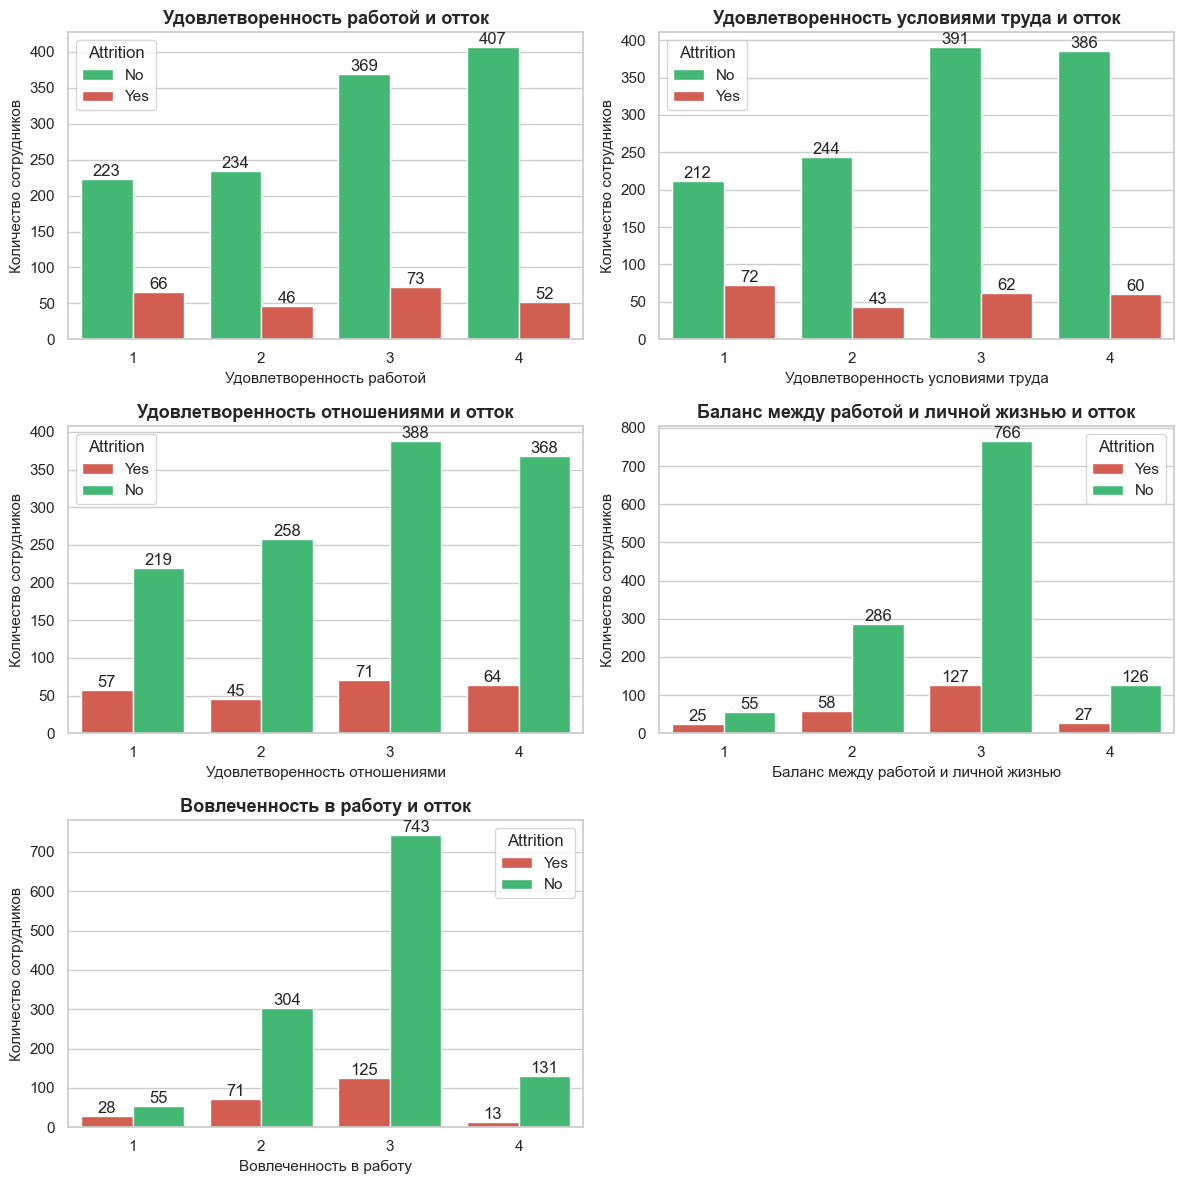

In [359]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.ravel()  # превращаем в плоский список [ax0, ax1, ax2, ax3]

# Удовлетворенность работой
sns.countplot(data=df, x='JobSatisfaction', hue='Attrition', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
for label in axes[0].containers:
    axes[0].bar_label(label)
axes[0].set_title('Удовлетворенность работой и отток', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Удовлетворенность работой', fontsize=11)
axes[0].set_ylabel('Количество сотрудников', fontsize=11)

# Удовлетворенность условиями труда
sns.countplot(data=df, x='EnvironmentSatisfaction', hue='Attrition', palette=['#2ecc71', '#e74c3c'], ax=axes[1])
for label in axes[1].containers:
    axes[1].bar_label(label)
axes[1].set_title('Удовлетворенность условиями труда и отток', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Удовлетворенность условиями труда', fontsize=11)
axes[1].set_ylabel('Количество сотрудников', fontsize=11)

# Удовлетворенность отношениями
sns.countplot(data=df, x='RelationshipSatisfaction', hue='Attrition', palette=['#e74c3c', '#2ecc71'], ax=axes[2])
for label in axes[2].containers:
    axes[2].bar_label(label)
axes[2].set_title('Удовлетворенность отношениями и отток', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Удовлетворенность отношениями', fontsize=11)
axes[2].set_ylabel('Количество сотрудников', fontsize=11)

# Баланс между работой и личной жизнью
sns.countplot(data=df, x='WorkLifeBalance', hue='Attrition', palette=['#e74c3c', '#2ecc71'], ax=axes[3])
for label in axes[3].containers:
    axes[3].bar_label(label)
axes[3].set_title('Баланс между работой и личной жизнью и отток', fontsize=13, fontweight='bold')
axes[3].set_xlabel('Баланс между работой и личной жизнью', fontsize=11)
axes[3].set_ylabel('Количество сотрудников', fontsize=11)

# Вовлеченность в работу
sns.countplot(data=df, x='JobInvolvement', hue='Attrition', palette=['#e74c3c', '#2ecc71'], ax=axes[4])
for label in axes[4].containers:
    axes[4].bar_label(label)
axes[4].set_title('Вовлеченность в работу и отток', fontsize=13, fontweight='bold')
axes[4].set_xlabel('Вовлеченность в работу', fontsize=11)
axes[4].set_ylabel('Количество сотрудников', fontsize=11)

axes[5].set_visible(False) # скрываем шестую пустую ось

plt.tight_layout()
plt.savefig("figures/bar_ratio_all_Satisfaction.png", dpi=300)
plt.show()

Теперь помотрим только по процентам оттока в каждом признаке и сделаем выводы

**Удовлетворенность работой**

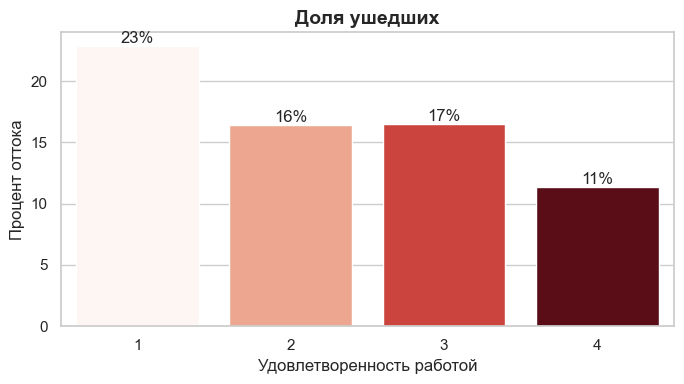

In [358]:
pct = df.groupby('JobSatisfaction')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=pct, x='JobSatisfaction', hue='JobSatisfaction', y='Attrition_code', legend=False, palette='Reds')
ax.set_title('Доля ушедших', fontsize=14, fontweight='bold')
ax.set_xlabel('Удовлетворенность работой', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%')
plt.tight_layout()
plt.savefig("figures/bar_JobSatisfaction.png", dpi=300)
plt.show()

In [118]:
# Доля ушедших внутри каждой группы отсортированные по убыванию
print('\n---Процент ушедших---\n')
print((df.groupby('JobSatisfaction')['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False))*100)


---Процент ушедших---

JobSatisfaction
1    22.837370
3    16.515837
2    16.428571
4    11.328976
Name: proportion, dtype: float64


In [119]:
table = pd.crosstab(df['JobSatisfaction'], df['Attrition'])
chi2, p, dof, _ = chi2_contingency(table)
print(f'chi2={chi2:.2f}, p={p:.4f}')

chi2=17.51, p=0.0006


**Вывод:**
- наблюдаем отрицательный линейный тренд: чем ниже удовлетворенность работой, тем выше отток
- Статистическая значимость подтверждена
- **Удовлетворенность работой влияет на отток**

**Удовлетворенность условиями труда**

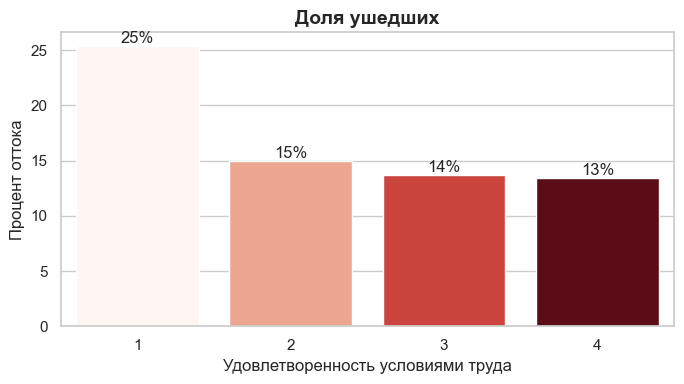

In [357]:
pct = df.groupby('EnvironmentSatisfaction')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=pct, x='EnvironmentSatisfaction', hue='EnvironmentSatisfaction', y='Attrition_code', legend=False, palette='Reds')
ax.set_title('Доля ушедших', fontsize=14, fontweight='bold')
ax.set_xlabel('Удовлетворенность условиями труда', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%')
plt.tight_layout()
plt.savefig("figures/bar_EnvironmentSatisfaction.png", dpi=300)
plt.show()

In [121]:
# Доля ушедших внутри каждой группы отсортированные по убыванию
print('\n---Процент ушедших---\n')
print((df.groupby('EnvironmentSatisfaction')['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False))*100)


---Процент ушедших---

EnvironmentSatisfaction
1    25.352113
2    14.982578
3    13.686534
4    13.452915
Name: proportion, dtype: float64


Удостоверимся с помощью стат проверки

In [122]:
table = pd.crosstab(df['EnvironmentSatisfaction'], df['Attrition'])
chi2, p, dof, _ = chi2_contingency(table)
print(f'chi2={chi2:.2f}, p={p:.4f}')

chi2=22.50, p=0.0001


**Вывод:**
- наблюдаем высокий процент оттока по низкому уровню удовлетворенности условиями труда, потом на остальных показателях 2,3,4 резкий спад и еле заметный отрицательный тренд (15%, 14%, 13%). Соответственно уходят в основном только, если очень низкая отметка удовлетворенности, а в остальном условия труда слабо влияют
- Статистическая значимость подтверждена
- **Удовлетворенность условиями труда влияет на отток**

**Удовлетворенность отношениями**

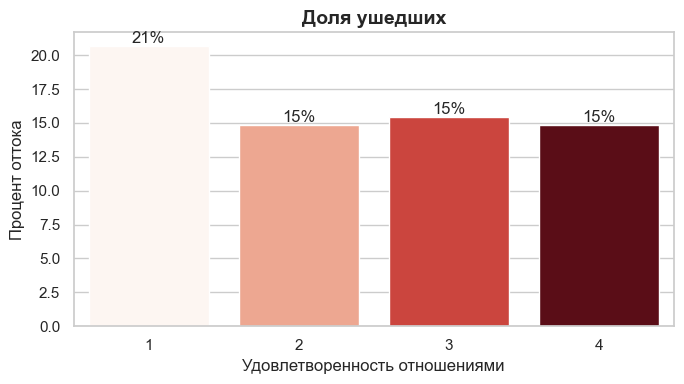

In [356]:
pct = df.groupby('RelationshipSatisfaction')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=pct, x='RelationshipSatisfaction', hue='RelationshipSatisfaction', y='Attrition_code', legend=False, palette='Reds')
ax.set_title('Доля ушедших', fontsize=14, fontweight='bold')
ax.set_xlabel('Удовлетворенность отношениями', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%')
plt.tight_layout()
plt.savefig("figures/bar_RelationshipSatisfaction.png", dpi=300)
plt.show()

In [124]:
# Доля ушедших внутри каждой группы отсортированные по убыванию
print('\n---Процент ушедших---\n')
print((df.groupby('RelationshipSatisfaction')['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False))*100)


---Процент ушедших---

RelationshipSatisfaction
1    20.652174
3    15.468410
2    14.851485
4    14.814815
Name: proportion, dtype: float64


Видим спорную картину, проверим значимость статистически Хи-квадратом.

In [125]:
table = pd.crosstab(df['RelationshipSatisfaction'], df['Attrition'])
chi2, p, dof, _ = chi2_contingency(table)
print(f'chi2={chi2:.2f}, p={p:.4f}')

chi2=5.24, p=0.1550


**Вывод:**
- наблюдаем высокий процент оттока по низкому уровню удовлетворенности отношениями, потом на остальных показателях также резкий спад и почти плато, из чего можно сделать вывод так же как и в случае с условиями труда, что уходят в основном только, если очень низкая отметка удовлетворенности, в остальных случаях отношения на работе не влияют на отток
- **Удовлетворенность отношениями с коллегами/руководством НЕ влияет на отток**  (по крайней мере, статистически НЕ значимо в наших данных).

**Баланс между работой и личной жизнью**

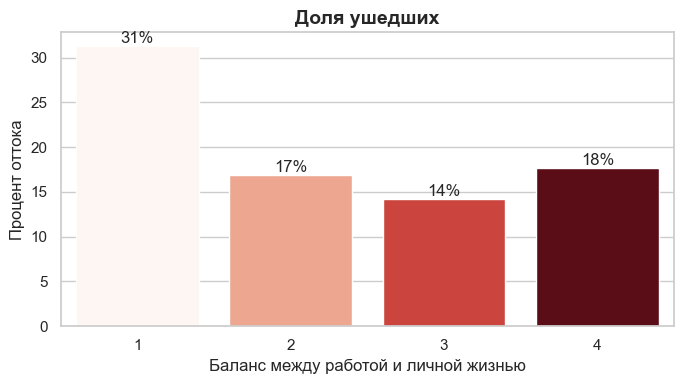

In [355]:
pct = df.groupby('WorkLifeBalance')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=pct, x='WorkLifeBalance', hue='WorkLifeBalance', y='Attrition_code', legend=False, palette='Reds')
ax.set_title('Доля ушедших', fontsize=14, fontweight='bold')
ax.set_xlabel('Баланс между работой и личной жизнью', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%')
plt.tight_layout()
plt.savefig("figures/bar_balanced.png", dpi=300)
plt.show()

In [127]:
# Доля ушедших внутри каждой группы отсортированные по убыванию
print('\n---Процент ушедших---\n')
print((df.groupby('WorkLifeBalance')['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False))*100)


---Процент ушедших---

WorkLifeBalance
1    31.250000
4    17.647059
2    16.860465
3    14.221725
Name: proportion, dtype: float64


In [128]:
# статистическая проверка
table = pd.crosstab(df['WorkLifeBalance'], df['Attrition'])
chi2, p, dof, _ = chi2_contingency(table)
print(f'chi2={chi2:.2f}, p={p:.4f}')

chi2=16.33, p=0.0010


**Вывод:**
- наблюдаем высокий процент оттока по низкому уровню баланса между жизнью и работой, потом резкий спад и еле заметный отрицательный тренд и аномальный выбег на высокой отметке баланса, но скорее всего это просто шум, что и подтверждает результат статистической проверки p=0.0010. Соответственно уходят в основном только, если очень низкая отметка баланса, а в остальном показатель баланса жизни и работы слабо влияет.
- Статистическая значимость подтверждена
- **Баланс между жизнью и работой влияет на отток**

**Вовлеченность в работу**

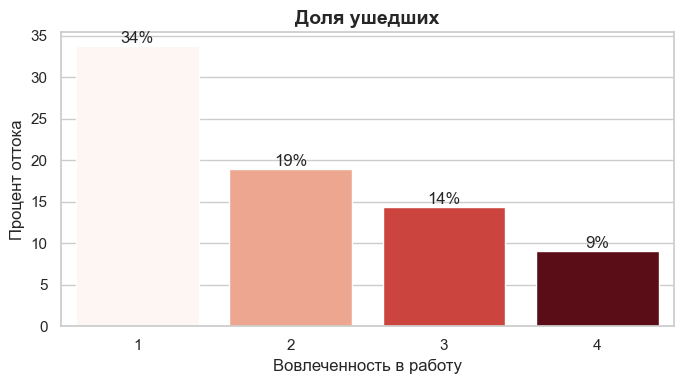

In [354]:
pct = df.groupby('JobInvolvement')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=pct, x='JobInvolvement', hue='JobInvolvement', y='Attrition_code', legend=False, palette='Reds')
ax.set_title('Доля ушедших', fontsize=14, fontweight='bold')
ax.set_xlabel('Вовлеченность в работу', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%')
plt.tight_layout()
plt.savefig("figures/bar_job_involvement.png", dpi=300)
plt.show()

In [130]:
# Доля ушедших внутри каждой группы отсортированные по убыванию
print('\n---Процент ушедших---\n')
print((df.groupby('JobInvolvement')['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False))*100)


---Процент ушедших---

JobInvolvement
1    33.734940
2    18.933333
3    14.400922
4     9.027778
Name: proportion, dtype: float64


**Вывод:**
- однозначный отрицательная линейная зависимость: чем меньше вовлеченность в работу, тем больший отток.
- **Вовлеченность влияет на отток**

#### Отток и переработки
(OverTime)

<Axes: >

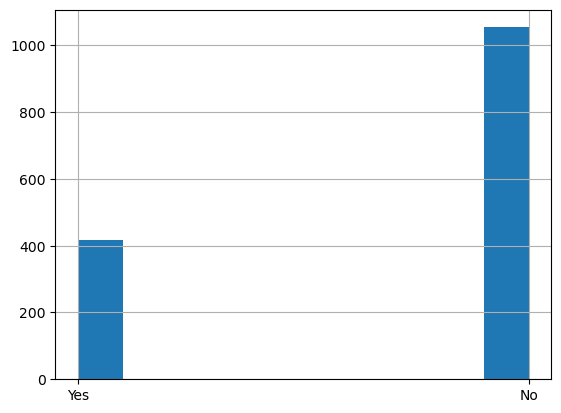

In [131]:
df['OverTime'].hist()

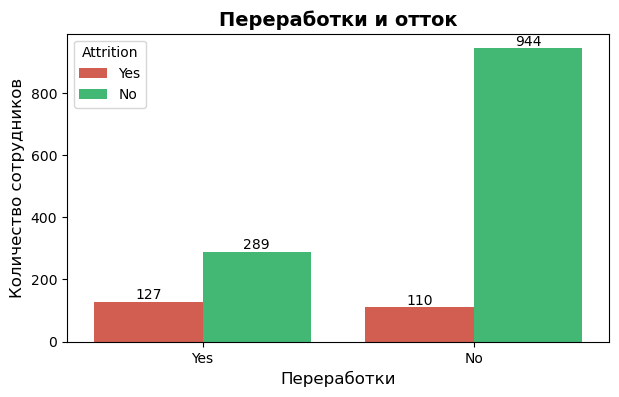

In [132]:
# Переработки и отток
fig, ax = plt.subplots(figsize=(7, 4))
ax = sns.countplot(data=df, x='OverTime', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
for label in ax.containers:
    ax.bar_label(label)
ax.set_title('Переработки и отток', fontsize=14, fontweight='bold')
ax.set_xlabel('Переработки', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)
plt.show()

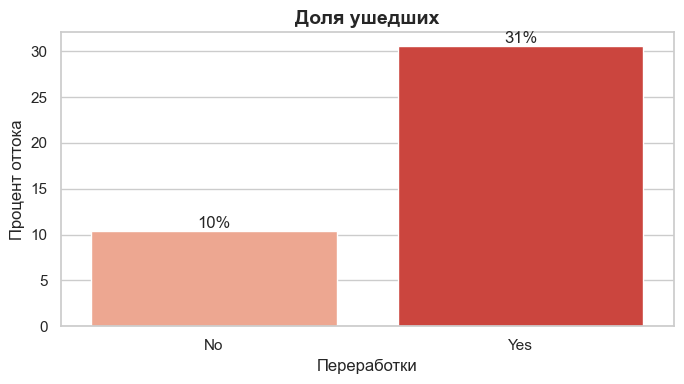

In [353]:
pct = df.groupby('OverTime')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=pct, x='OverTime', hue='OverTime', y='Attrition_code', legend=False, palette='Reds')
ax.set_title('Доля ушедших', fontsize=14, fontweight='bold')
ax.set_xlabel('Переработки', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%')
plt.tight_layout()
plt.savefig("figures/bar_over_time.png", dpi=300)
plt.show()

In [134]:
# Доля ушедших внутри каждой группы отсортированные по убыванию
print('\n---Процент ушедших---\n')
print((df.groupby('OverTime')['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False))*100)


---Процент ушедших---

OverTime
Yes    30.528846
No     10.436433
Name: proportion, dtype: float64


In [135]:
# статистическая проверка
table = pd.crosstab(df['OverTime'], df['Attrition'])
chi2, p, dof, _ = chi2_contingency(table)
print(f'chi2={chi2:.2f}, p={p:.4f}')

chi2=87.56, p=0.0000


**Вывод:** 
- Сотрудники с переработками уходят в три раза чаще, чем без переработок
- **Переработки влияют на отток**

#### Отток и Количество тренингов за прошлый год
(TrainingTimesLastYear)

<Axes: >

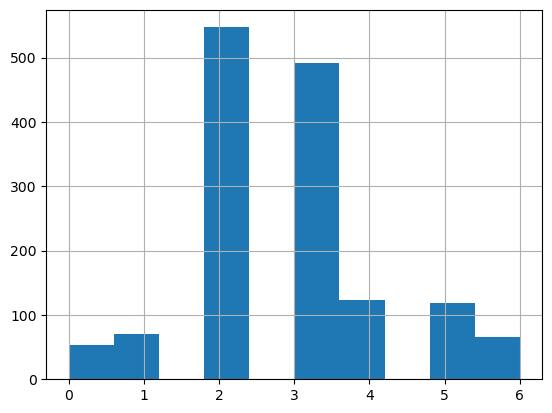

In [136]:
df['TrainingTimesLastYear'].hist()

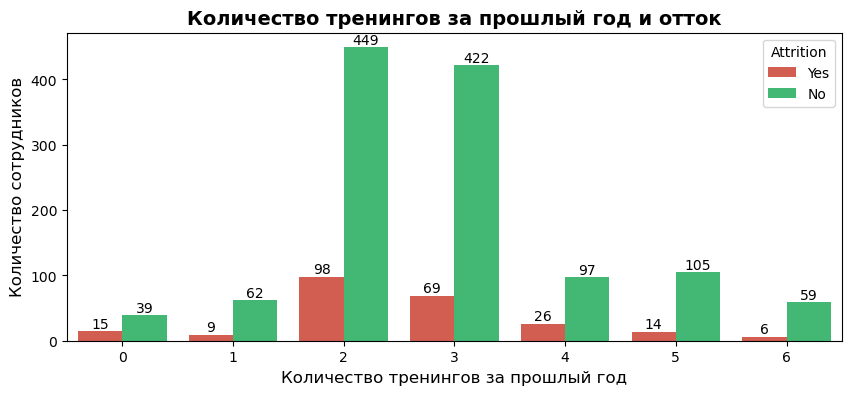

In [137]:
# Количество тренингов за прошлый год  и отток
fig, ax = plt.subplots(figsize=(10, 4))
ax = sns.countplot(data=df, x='TrainingTimesLastYear', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
for label in ax.containers:
    ax.bar_label(label)
ax.set_title('Количество тренингов за прошлый год и отток', fontsize=14, fontweight='bold')
ax.set_xlabel('Количество тренингов за прошлый год', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)
plt.show()

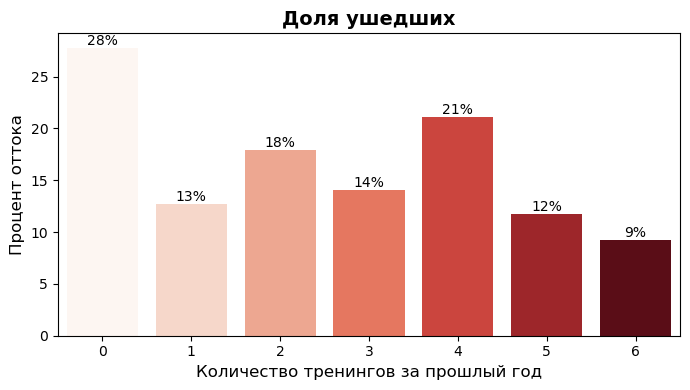

In [138]:
pct = df.groupby('TrainingTimesLastYear')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=pct, x='TrainingTimesLastYear', hue='TrainingTimesLastYear', y='Attrition_code', legend=False, palette='Reds')
ax.set_title('Доля ушедших', fontsize=14, fontweight='bold')
ax.set_xlabel('Количество тренингов за прошлый год', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%')
plt.tight_layout()
plt.show()

In [139]:
# Доля ушедших внутри каждой группы отсортированные по убыванию
print('\n---Процент ушедших---\n')
print((df.groupby('TrainingTimesLastYear')['Attrition'].value_counts(normalize=True)
    .xs('Yes', level='Attrition').sort_values(ascending=False))*100)


---Процент ушедших---

TrainingTimesLastYear
0    27.777778
4    21.138211
2    17.915905
3    14.052953
1    12.676056
5    11.764706
6     9.230769
Name: proportion, dtype: float64


In [140]:
# статистическая проверка
table = pd.crosstab(df['TrainingTimesLastYear'], df['Attrition'])
chi2, p, dof, _ = chi2_contingency(table)
print(f'chi2={chi2:.2f}, p={p:.4f}')

chi2=15.15, p=0.0191


**Вывод:** 
- Признак статистически значим, но картина НЕ монотонная. Связь есть, но она не линейная. Резкий всплеск оттока на 0 обучений, затем спад и на 4 всплеск, который нарушает картину линейности. Но если посмотреть на количество сотрудников в группе с 4 обучениями в год, то увидим, что это маленькая группа. Из чего можно сделать вывод, что это не сигнал, а просто шум. И если не учитывать этот шум, то линейность все же становится видна - чем меньше обучения у сотрудника, тем выше отток.
- **Количество тренингов Влияет на отток**

### 3.3. Почему уходят - Оценки эффективности
(PerformanceRating)

#### PerformanceRating


--- Распределение сотрудников по оценкам эффективности ---

PerformanceRating
3    1244
4     226
Name: count, dtype: int64


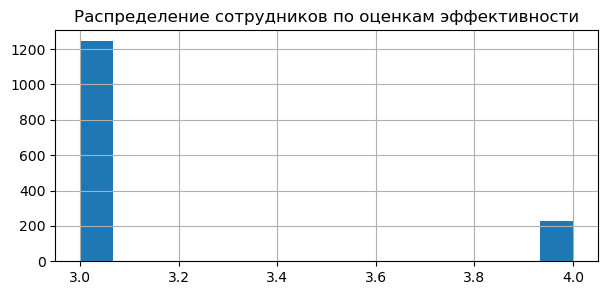

In [141]:
# всего сотрудников по оценкам эффективности
print("\n--- Распределение сотрудников по оценкам эффективности ---\n")
print(df['PerformanceRating'].value_counts())

df['PerformanceRating'].hist(bins=15, figsize=(7, 3)) 
plt.title('Распределение сотрудников по оценкам эффективности')
plt.show() 

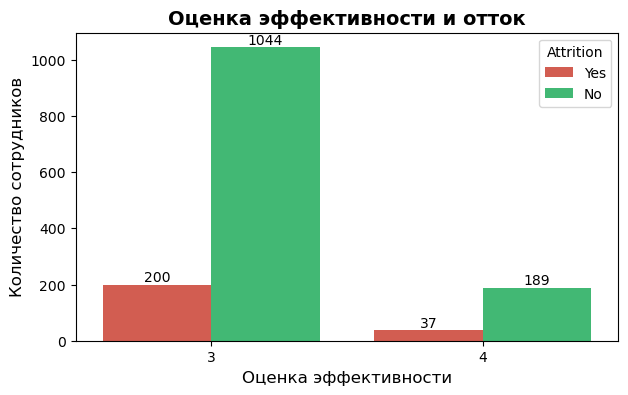

In [142]:
# Оценка эффективности  и отток
fig, ax = plt.subplots(figsize=(7, 4))
ax = sns.countplot(data=df, x='PerformanceRating', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
for label in ax.containers:
    ax.bar_label(label)
ax.set_title('Оценка эффективности и отток', fontsize=14, fontweight='bold')
ax.set_xlabel('Оценка эффективности', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)
plt.show()

In [143]:
# Доля ушедших внутри каждой группы отсортированные по убыванию
print('\n---Процент ушедших---\n')
print((df.groupby('PerformanceRating')['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False))*100)


---Процент ушедших---

PerformanceRating
4    16.371681
3    16.077170
Name: proportion, dtype: float64


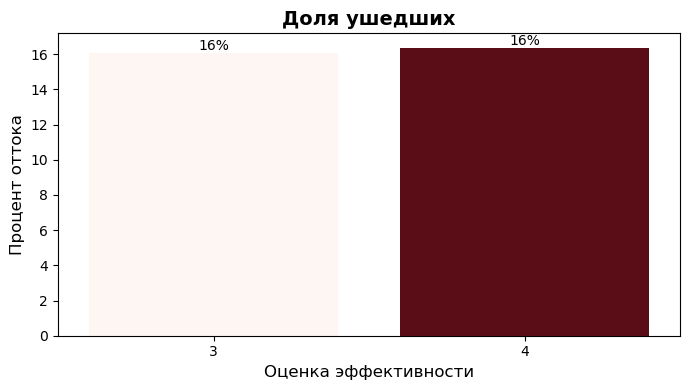

In [144]:
pct = df.groupby('PerformanceRating')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=pct, x='PerformanceRating', hue='PerformanceRating', y='Attrition_code', legend=False, palette='Reds')
ax.set_title('Доля ушедших', fontsize=14, fontweight='bold')
ax.set_xlabel('Оценка эффективности', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%')
plt.tight_layout()
plt.show()

Удостоверимся с помощью статистической проверки.

In [145]:
# статистическая проверка
table = pd.crosstab(df['PerformanceRating'], df['Attrition'])
chi2, p, dof, _ = chi2_contingency(table)
print(f'chi2={chi2:.2f}, p={p:.4f}')

chi2=0.00, p=0.9901


**Вывод:** 
- Процент оттока одинаков при обеих оценках, что говорит об отсутствии влияния этого признака на отток
- Статистическая значимость не подтверждена
- **Оценка эффективности не влияет на отток!**

### 3.4. Почему уходят - Сезонно-биоритмический слой (проверка моей гипотезы) 

#### Отток по сезону рождения 
(Season_of_Birth)

**Цель:** Проверить Сезонно-биоритмическую гипотезу.

<Axes: >

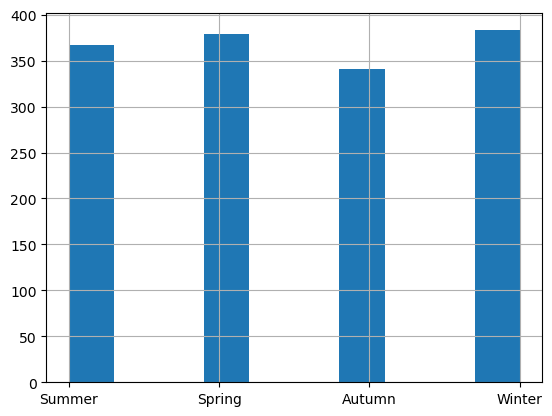

In [146]:
df['Season_of_Birth'].hist()

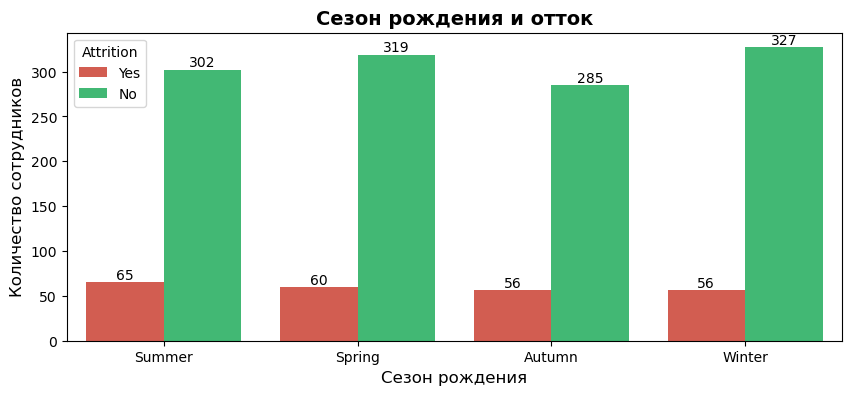

In [147]:
# Сезон рождения и отток
fig, ax = plt.subplots(figsize=(10, 4))
ax = sns.countplot(data=df, x='Season_of_Birth', hue='Attrition', palette=['#e74c3c', '#2ecc71'])
for label in ax.containers:
    ax.bar_label(label)
ax.set_title('Сезон рождения и отток', fontsize=14, fontweight='bold')
ax.set_xlabel('Сезон рождения', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)
plt.show()

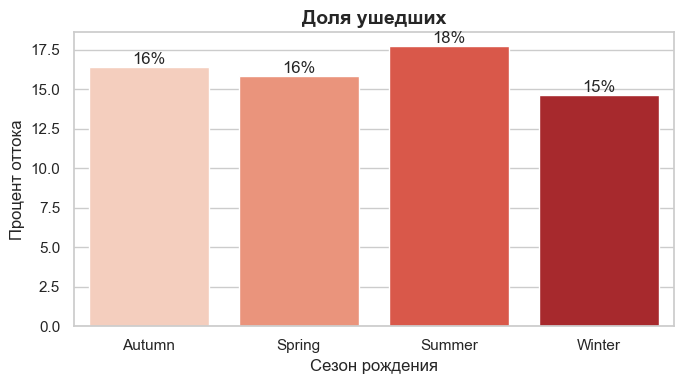

In [352]:
pct = df.groupby('Season_of_Birth')['Attrition_code'].mean().reset_index()
pct['Attrition_code'] = pct['Attrition_code'] * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=pct, x='Season_of_Birth', hue='Season_of_Birth', y='Attrition_code', legend=False, palette='Reds')
ax.set_title('Доля ушедших', fontsize=14, fontweight='bold')
ax.set_xlabel('Сезон рождения', fontsize=12)
ax.set_ylabel('Процент оттока', fontsize=12)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%')
plt.tight_layout()
plt.savefig("figures/bar_season_of_birth.png", dpi=300)
plt.show()

In [149]:
# Доля ушедших внутри каждой группы отсортированные по убыванию
print('\n---Процент ушедших---\n')
print((df.groupby('Season_of_Birth')['Attrition'].value_counts(normalize=True).xs('Yes', level='Attrition').sort_values(ascending=False))*100)


---Процент ушедших---

Season_of_Birth
Summer    17.711172
Autumn    16.422287
Spring    15.831135
Winter    14.621410
Name: proportion, dtype: float64


In [150]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,BirthYear,BirthMonth,BirthDay,BirthDate,Season_of_Birth,Generation,Attrition_code,Overall_Satisfaction,Satisfaction_Level,IncomeBucket
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,1985,7,22,1985-07-22,Summer,Y,1,2.2,Medium,"(4919.0, 6528.667]"
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,1977,4,22,1977-04-22,Spring,X,0,2.8,Medium,"(4919.0, 6528.667]"
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,1989,11,5,1989-11-05,Autumn,Y,1,2.8,Medium,"(1008.999, 2560.667]"
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,1993,8,24,1993-08-24,Summer,Y,0,3.2,High,"(2560.667, 3631.667]"
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,1999,5,1,1999-05-01,Spring,Z,0,2.6,Medium,"(2560.667, 3631.667]"


In [151]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BirthYear',
       'BirthMonth', 'BirthDay', 'BirthDate', 'Season_of_Birth', 'Generation',
       'Attrition_code', 'Overall_Satisfaction', 'Satisfaction_Level',
       'IncomeBucket'],
      dtype='object')

In [152]:
# статистическая проверка
table = pd.crosstab(df['Season_of_Birth'], df['Attrition'])
chi2, p, dof, _ = chi2_contingency(table)
print(f'chi2={chi2:.2f}, p={p:.4f}')

chi2=1.37, p=0.7127


**Вывод:** 
- Статистическая значимость сезонности рождения не подтверждена
- **Сезон рождения не показывает явной связи с оттоком.**

### Итоговый вывод по третьему шагу - Почему уходят:
**Компенсация:**
- Зарплата влияет. Чёткий линейный тренд: чем ниже доход, тем выше отток.
- *Rate (Daily/Hourly/Monthly) не влияют - подтверждённый шум.
- Процент повышения зарплаты не влияет.
- Наличие опционов - второй по силе признак в датасете. Отток падает с 24.4% (нет опционов) до 7.6-9.4% (есть). Аномалия на уровне 3 - малочисленная группа, не сигнал, а шум.

**Поведение и удовлетворённость:**
- Удовлетворённость работой влияет - линейный тренд.
- Удовлетворённость условиями труда влияет порогово: высокий отток только при уровне 1, далее плато.
- Удовлетворённость отношениями НЕ влияет - статистически незначимо.
- Баланс работы и жизни влияет порогово: критичен только низкий уровень.
- Вовлечённость влияет - линейная зависимость.
- Переработки - один из сильнейших драйверов: уходят в 3 раза чаще.
- Количество тренингов влияет: при исключении шумовой группы 4 обучения виден линейный тренд — чем меньше обучения, тем выше отток.

**Оценки эффективности:**
- Не влияют. Отток одинаков при обеих оценках, значимость не подтверждена.

**Сезонность рождения:**
- Не подтверждена. Связи с оттоком нет.

**Главный итог шага 3:**
- Отток определяется тремя сильными драйверами — **деньги, переработки, отношения с руководителем (из шага 2)**.
- Удовлетворённость работой, условиями и вовлечённость работают порогово: критичен только низкий уровень, дальше — плато.
- Оценки эффективности, процент повышения, *Rate и сезонность рождения — шум, в модель не идут.

**Топ-5 признаков для модели оттока:**
- YearsWithCurrManager = 0 (шаг 2)
- StockOptionLevel = 0
- OverTime = Yes
- MonthlyIncome (низкий)
- JobSatisfaction / WorkLifeBalance (низкие)

## Шаг 4: Проверка гипотез статистически.
**Цель:** Статистически подтвердить выводы EDA, отсеять шум и сформировать финальный набор предикторов для модели оттока.

**Результат:** список значимых предикторов с оценкой силы связи и направления влияния, готовый для построения прогнозной модели.

**Задачи:**
- Удалить колонки, которые несут один и тот же смысл.
- Разделить признаки по типам.
- Применить к каждой группе корректный тест: χ² + Cramér's V (категориальные), Mann-Whitney U (непрерывные), phik (все признаки).
- Сравнить методы (phik vs Пирсон vs χ²) — показать, где линейные методы недооценивают связь.
- Сформировать предварительный список кандидатов в модель.

In [153]:
# !pip install phik
from scipy.stats import chi2_contingency, pointbiserialr, spearmanr, mannwhitneyu
from scipy.stats.contingency import association
import phik
from phik import report

Для начала удалим колонки, которые несут один и тот же смысл:
- `Attrition` и Attrition_code - несут один и тот же смысл, оставляем только закодированную целевую переменную Attrition_code
- `BirthYear` и Age - BirthYear производная от Age и нужна была только для генерации поколений. Оставляем только Age
- `BirthDate` дублирует BirthYear/Month/Day - удаляем на этом этапе
- `Satisfaction_Level` - дублирует Overall_Satisfaction
- `IncomeBucket` - дублирует MonthlyIncome

In [154]:
df_clean = df.drop(columns=['Attrition', 'BirthYear', 'BirthDate', 'Satisfaction_Level', 'IncomeBucket'])

Смотрим типы данных в очищенном датасете

In [155]:
df_clean.dtypes

Age                           int64
BusinessTravel               object
DailyRate                     int64
Department                   object
DistanceFromHome              int64
Education                     int64
EducationField               object
EnvironmentSatisfaction       int64
Gender                       object
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                      object
JobSatisfaction               int64
MaritalStatus                object
MonthlyIncome                 int64
MonthlyRate                   int64
NumCompaniesWorked            int64
OverTime                     object
PercentSalaryHike             int64
PerformanceRating             int64
RelationshipSatisfaction      int64
StockOptionLevel              int64
TotalWorkingYears             int64
TrainingTimesLastYear         int64
WorkLifeBalance               int64
YearsAtCompany                int64
YearsInCurrentRole          

Так как для разных методов нам понадобится разделять категориальные признаки и числовые на порядковые и непрерывные, то для удобства дальнейшей работы со статистическими методами, **создадим отдельные переменные для разных типов признаков**.

In [156]:
# отделим категориальные и числовые признаки
cat_cols = df_clean.select_dtypes(include=['object'])
num_cols = df_clean.select_dtypes(include=['number'])

print(cat_cols.columns)
print(num_cols.columns)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime', 'Season_of_Birth', 'Generation'],
      dtype='object')
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BirthMonth',
       'BirthDay', 'Attrition_code', 'Overall_Satisfaction'],
      dtype='object')


Поработаем с числовыми, разделив их

In [157]:
# пустые списки для разных типов числовых признаков 
binary_cols = []        # числовые бинарные
ordinal_cols = []       # числовые порядковые
continuous_cols = []    # числовые непрерывные

# проитерируем числовые признаки и распределим каждый в свой список
for col in num_cols.columns.tolist():
    n_unique = df_clean[col].nunique()
    if n_unique == 2:
        binary_cols.append(col)
    elif n_unique <= 10:
        ordinal_cols.append(col)
    else:
        continuous_cols.append(col)

# категориальные и числовые
category_cols = cat_cols.columns.tolist() + binary_cols + ordinal_cols  # все категориальные, включая и числовые категориальные
numeric_cols = num_cols.columns.tolist()                                    # все числовые, без разделения на типы

# проверим
print(len(binary_cols), binary_cols)
print(len(ordinal_cols), ordinal_cols)
print(len(continuous_cols), continuous_cols)
print(len(numeric_cols), numeric_cols)
print(len(category_cols), category_cols)

2 ['PerformanceRating', 'Attrition_code']
10 ['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'NumCompaniesWorked', 'RelationshipSatisfaction', 'StockOptionLevel', 'TrainingTimesLastYear', 'WorkLifeBalance']
15 ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BirthMonth', 'BirthDay', 'Overall_Satisfaction']
27 ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BirthMonth', 'BirthDay', 'Attr

Так как наш **датасет включает в себя разные типы данных**, то логичнее всего использовать phik матрицу корреляций, в основе которой лежит модифицированный тест независимости Хи-квадрат.

**Phik matrix** - это современный инструмент для анализа корреляций, который решает главную проблему классического коэффициента Пирсона: он умеет одновременно оценивать зависимости между числовыми (непрерывными), порядковыми и категориальными признаками, включая нелинейные связи.

Алгоритм разбивает непрерывные данные на бины (интервалы), превращая их в подобие категориальных, строит таблицу сопряженности для каждой пары признаков и вычисляет коэффициент, который затем масштабируется так, чтобы работать как привычная корреляция (от 0 до 1, где 0 — полной независимость, а 1 — идеальная связь).

Поэтому мы и выделили непрерывные признаки в отдельную переменную, она нам теперь понадобится.

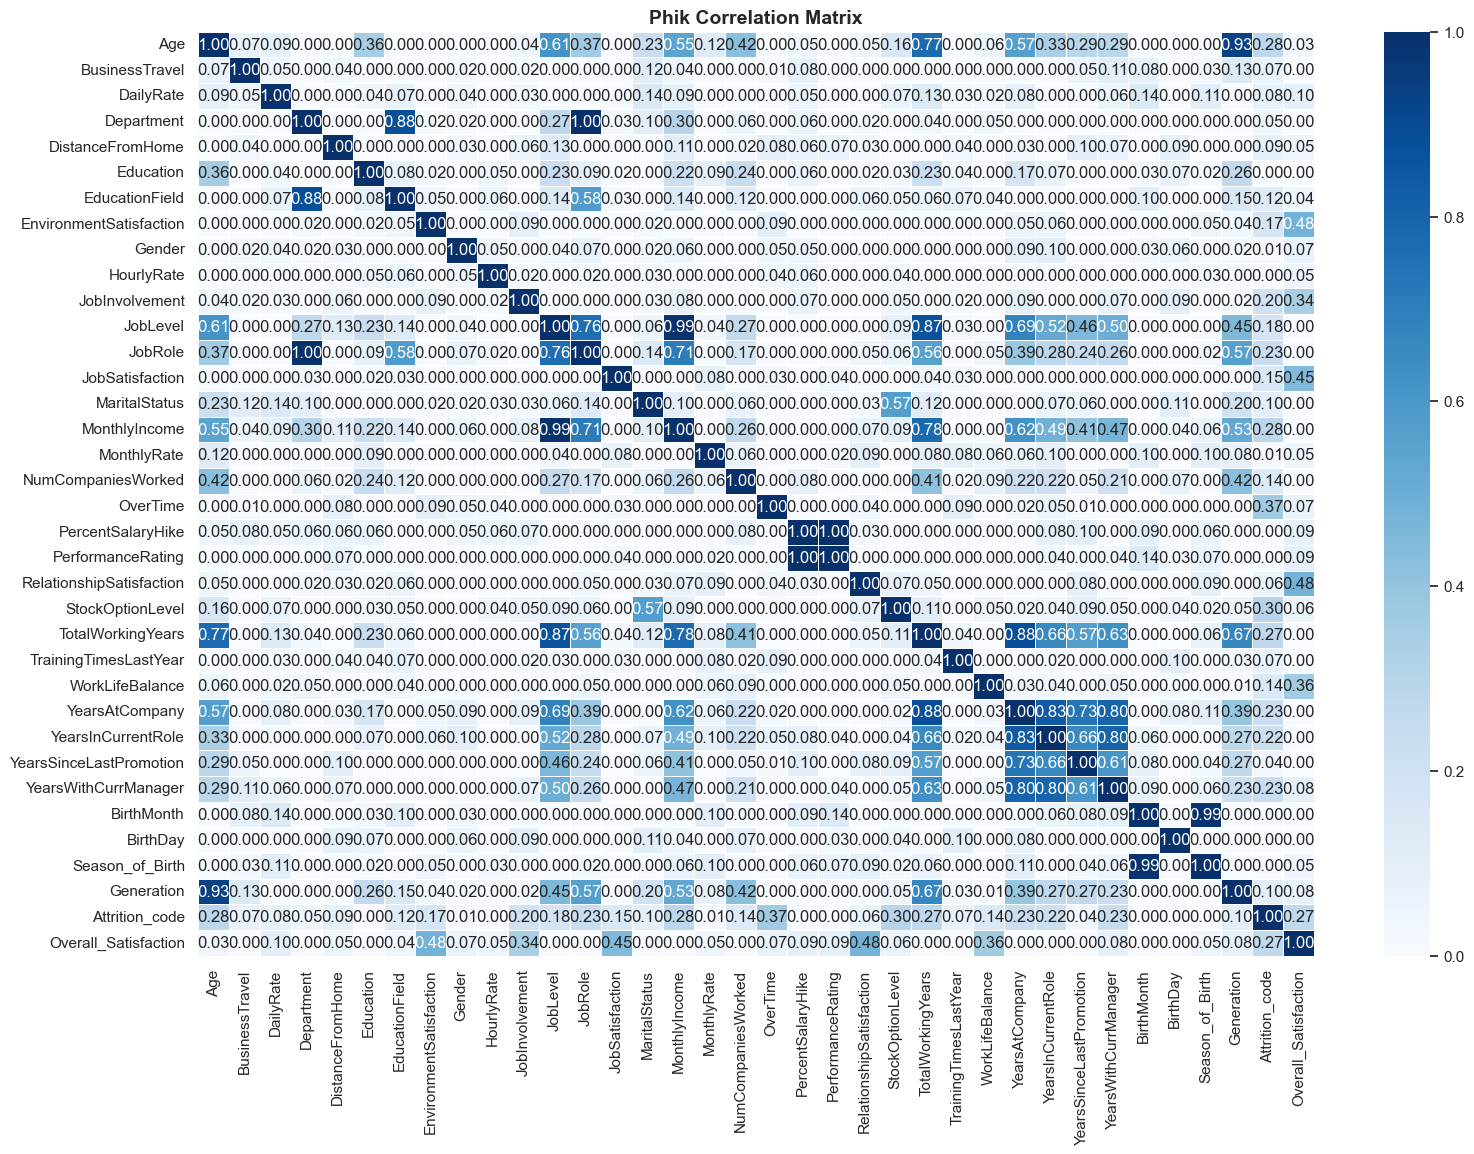

In [350]:
# Явно указываем, какие признаки являются интервальными (числовыми непрерывными),
# библиотека phik должна знать их, чтобы правильно разбить на бины (корзины)

# Вычисляем phik матрицу корреляций
# interval_cols = только непрерывные; всё остальное phik считает категориальным
# Параметр bins отвечает за количество корзин для непрерывных признаков, по умолчанию 10, его не меняем
phik_matrix = df_clean.phik_matrix(interval_cols=continuous_cols)

# Визуализация матрицы для большей наглядности
plt.figure(figsize=(18, 12))
sns.heatmap(
    phik_matrix, 
    annot=True,          
    cmap='Blues',        
    vmin=0, vmax=1,      # Значения Phik всегда лежат в диапазоне [0, 1]
    linewidths=0.5,
    fmt=".2f"            # Округление до 2 знаков
)
plt.title('Phik Correlation Matrix', fontsize=14, fontweight='bold')
plt.savefig("figures/phik_matrix.png", dpi=300)
plt.show()

Сравним с матрицей Пирсона (только числовые)

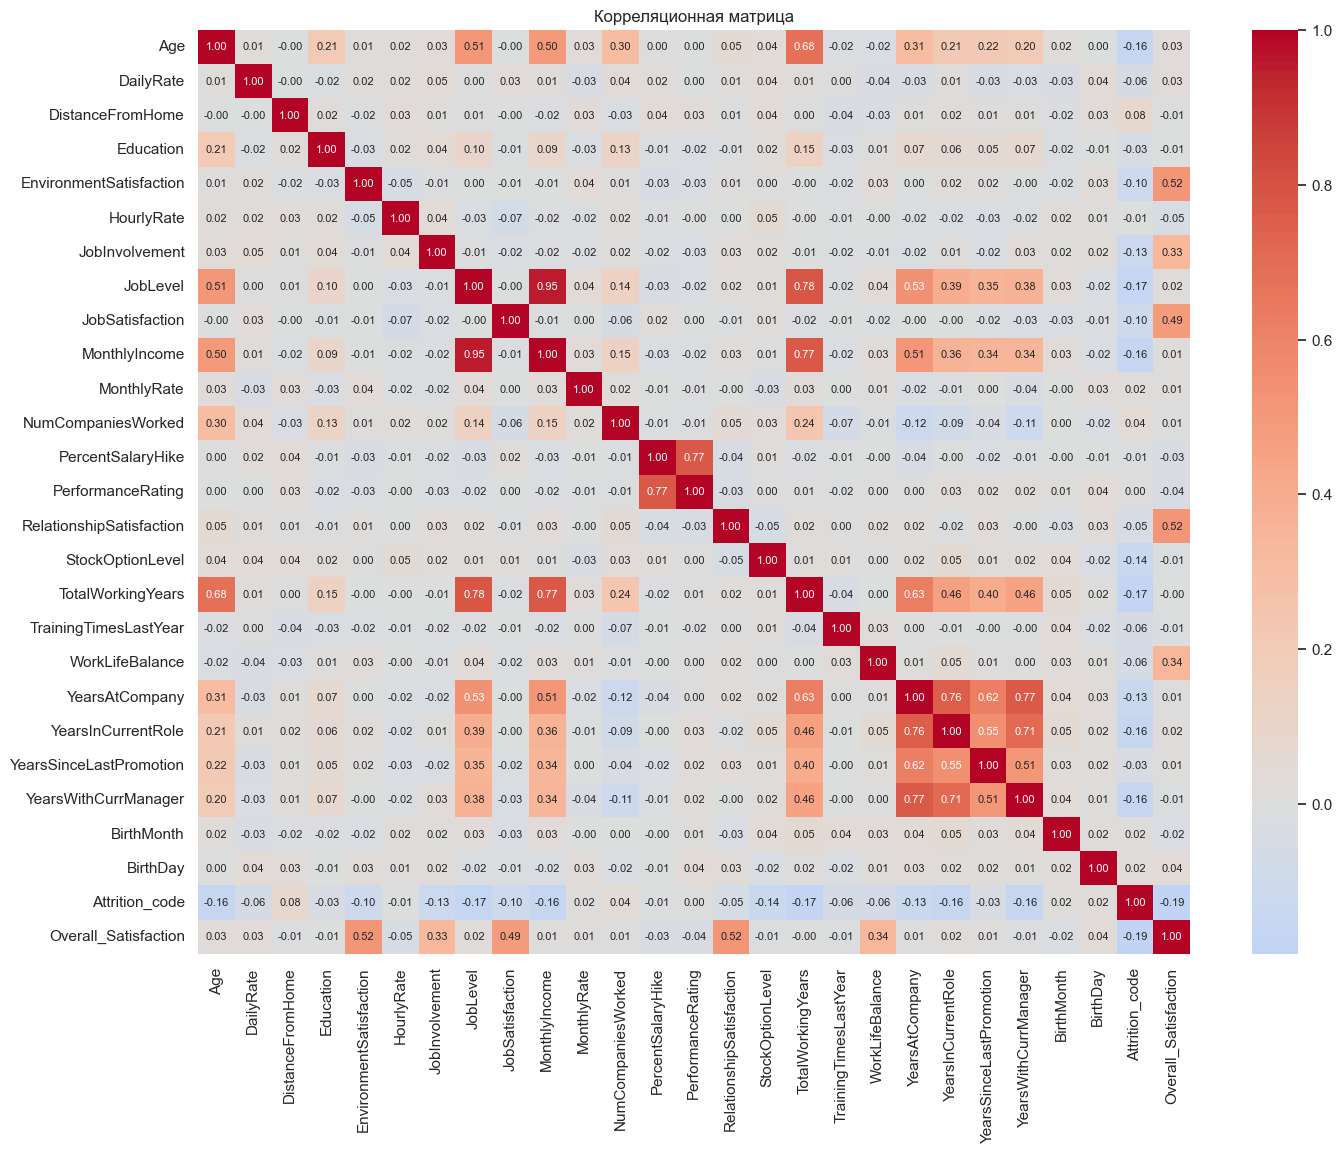

Attrition_code              1.000000
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
BirthDay                    0.024495
BirthMonth                  0.016057
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
Overall_Satisfaction       -0.193395
N

<Figure size 640x480 with 0 Axes>

In [351]:
# Корреляционная матрица (только числовые)
plt.figure(figsize=(16, 12))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', annot_kws={'size': 8})
plt.title('Корреляционная матрица')
plt.show()

# tоп-корреляции с Attrition_code
corr_with_target = num_cols.corr()['Attrition_code'].sort_values(ascending=False)
plt.savefig("figures/corr_pearson_matrix.png", dpi=300)
print(corr_with_target)

Посмотрим на fick корреляцию признаков только с целевой переменной.

In [162]:
# связи с целевой, отсортированные
target_phik = phik_matrix['Attrition_code'].drop('Attrition_code').sort_values(ascending=False)
print('--- Phik с Attrition_code ---')
print(target_phik.round(3))

--- Phik с Attrition_code ---
OverTime                    0.372
StockOptionLevel            0.297
MonthlyIncome               0.283
Age                         0.278
TotalWorkingYears           0.272
Overall_Satisfaction        0.267
YearsWithCurrManager        0.235
JobRole                     0.231
YearsAtCompany              0.226
YearsInCurrentRole          0.220
JobInvolvement              0.199
JobLevel                    0.177
EnvironmentSatisfaction     0.174
JobSatisfaction             0.150
WorkLifeBalance             0.144
NumCompaniesWorked          0.140
EducationField              0.121
MaritalStatus               0.105
Generation                  0.101
DistanceFromHome            0.089
DailyRate                   0.081
BusinessTravel              0.074
TrainingTimesLastYear       0.074
RelationshipSatisfaction    0.059
Department                  0.047
YearsSinceLastPromotion     0.035
Gender                      0.014
MonthlyRate                 0.013
Education         

**Плюс корреляции Пирсона** в том, что она дает результат не просто линейности связи, но и направленность, что очень ценно для анализа. Но она работает только с числовыми величинами, и видит только линейные связи.

**Плюс fick матрицы корреляций** в том, что она работет со всеми типами данных и показывает не только линейные зависимости, но и нелинейные, которые упускает матрица Пирсона

Для полной картины сравнений с fick матрицей, еще выведем обычный **метод Хи-квадрат и Cramer's V для категориальных данных**. будем использоваь оба метода для информативности, так как хи-тест отвечает только на вопрос есть ли связь, но не говорит, насколько она сильная. При большом n х² найдёт значимую связь даже там, где эффект практически нулевой. Cramer's V закрывает эту слепую зону. К тому же его коэффициент нормирован от 0 до 1, поэтому его легче интерпретировать

Также полной картины сравнений с fick матрицей, еще выведем **метод Mann-Whitney U для непрерывных данных**. Почему именно он, а не т-тест? Не требует нормальности распределения, так как работает с рангами, а не со средним и устойчив к выбросам. А в наших данных как мы знаем есть и то и то.

In [163]:
# Хи-квадрат для категориальных + phik + Cramer's V
def chi2_test(df, col, target='Attrition_code'):
    table = pd.crosstab(df[col], df[target])
    if table.shape[0] < 2 or table.shape[1] < 2:
        return None
    chi2, p, dof, _ = chi2_contingency(table)
    v = association(table, method='cramer')
    return {'feature': col, 'chi2': chi2, 'p': p,
            'cramers_v': v, 'phik': phik_matrix.loc[col, target]}

results_cat = pd.DataFrame([
    chi2_test(df_clean, c) for c in category_cols
]).dropna().sort_values('p')

print('--- Категориальные: χ² + Cramer V + phik ---')
print(results_cat.round(4))

--- Категориальные: χ² + Cramer V + phik ---
                     feature       chi2       p  cramers_v    phik
10            Attrition_code  1462.6146  0.0000     1.0000  1.0000
6                   OverTime    87.5643  0.0000     0.2461  0.3721
4                    JobRole    86.1903  0.0000     0.2421  0.2315
14                  JobLevel    72.5290  0.0000     0.2221  0.1768
18          StockOptionLevel    60.5983  0.0000     0.2030  0.2975
5              MaritalStatus    46.1637  0.0000     0.1772  0.1048
8                 Generation    43.0959  0.0000     0.1712  0.1011
13            JobInvolvement    28.4920  0.0000     0.1392  0.1987
0             BusinessTravel    24.1824  0.0000     0.1283  0.0741
12   EnvironmentSatisfaction    22.5039  0.0001     0.1237  0.1739
15           JobSatisfaction    17.5051  0.0006     0.1091  0.1500
20           WorkLifeBalance    16.3251  0.0010     0.1054  0.1438
16        NumCompaniesWorked    25.7444  0.0022     0.1323  0.1397
1                

In [164]:
# Mann-Whitney для непрерывных + phik + Pearson
def mannwhitney_test(df, col, target='Attrition_code'):
    g1 = df.loc[df['Attrition_code'] == 1, col].dropna()
    g0 = df.loc[df['Attrition_code'] == 0, col].dropna()
    stat, p = mannwhitneyu(g1, g0, alternative='two-sided')
    # размер эффекта — rank-biserial correlation
    n1, n0 = len(g1), len(g0)
    rbc = 1 - (2 * stat) / (n1 * n0)
    return {'feature': col, 'U': stat, 'p': p,
            'median_yes': g1.median(),
            'median_no': g0.median(),
            'rank_biserial': rbc}

results_mw = pd.DataFrame([
    mannwhitney_test(df_clean, c) for c in continuous_cols
]).sort_values('p')

# pearson
pearson_matrix = df_clean[continuous_cols + ['Attrition_code']].corr()

# сравнение с phik по непрерывным
comparison = pd.DataFrame({
    'pearson_with_target':   pearson_matrix['Attrition_code'].drop('Attrition_code'),
    'phik_with_target':      phik_matrix['Attrition_code'].reindex(continuous_cols),
    'mw_pvalue':             results_mw.set_index('feature')['p'],
    'mw_rbc': results_mw.set_index('feature')['rank_biserial'],
})

print('--- Непрерывные: Pearson vs Phik vs Mann-Whitney ---')
print(comparison.round(3).sort_values('phik_with_target', ascending=False))

--- Непрерывные: Pearson vs Phik vs Mann-Whitney ---
                         pearson_with_target  phik_with_target  mw_pvalue  \
MonthlyIncome                         -0.160             0.283      0.000   
Age                                   -0.159             0.278      0.000   
TotalWorkingYears                     -0.171             0.272      0.000   
Overall_Satisfaction                  -0.193             0.267      0.000   
YearsWithCurrManager                  -0.156             0.235      0.000   
YearsAtCompany                        -0.134             0.226      0.000   
YearsInCurrentRole                    -0.161             0.220      0.000   
DistanceFromHome                       0.078             0.089      0.002   
DailyRate                             -0.057             0.081      0.029   
YearsSinceLastPromotion               -0.033             0.035      0.041   
MonthlyRate                            0.015             0.013      0.559   
BirthDay               

#### Как распределилась значимость после статистической проверки:

**Категориальные признаки**

| Признак | χ² | p-value | Cramér's V | Phik | Вывод |
|---|---|---|---|---|---|
| OverTime | 87.56 | 0.000 | 0.246 | 0.372 | 🟢 №1 драйвер |
| JobRole | 86.19 | 0.000 | 0.242 | 0.232 | 🟢 Сильный |
| JobLevel | 72.53 | 0.000 | 0.222 | 0.177 | 🟢 Сильный |
| StockOptionLevel | 60.60 | 0.000 | 0.203 | 0.298 | 🟢 Сильный, №2 по Phik |
| MaritalStatus | 46.16 | 0.000 | 0.177 | 0.105 | 🟡 Умеренный |
| Generation | 43.10 | 0.000 | 0.171 | 0.101 | 🟡 Умеренный (дублирует Age) |
| JobInvolvement | 28.49 | 0.000 | 0.139 | 0.199 | 🟢 Средний (Phik выше V) |
| NumCompaniesWorked | 25.74 | 0.002 | 0.132 | 0.140 | 🟡 Средний |
| BusinessTravel | 24.18 | 0.000 | 0.128 | 0.074 | 🟡 Слабый |
| EnvironmentSatisfaction | 22.50 | 0.0001 | 0.124 | 0.174 | 🟢 Средний (Phik >> V) |
| JobSatisfaction | 17.51 | 0.0006 | 0.109 | 0.150 | 🟡 Средний |
| WorkLifeBalance | 16.33 | 0.001 | 0.105 | 0.144 | 🟡 Средний |
| EducationField | 16.02 | 0.007 | 0.104 | 0.121 | 🟡 Слабый |
| TrainingTimesLastYear | 15.15 | 0.019 | 0.102 | 0.074 | 🟡 Слабый |
| Department | 10.80 | 0.0045 | 0.086 | 0.047 | 🟠 Очень слабый |
| RelationshipSatisfaction | 5.24 | 0.155 | 0.060 | 0.059 | 🔴 Незначим |
| Gender | 1.12 | 0.291 | 0.030 | 0.014 | 🔴 Незначим |
| Education | 3.07 | 0.546 | 0.046 | 0.000 | 🔴 Незначим |
| Season_of_Birth | 1.37 | 0.713 | 0.031 | 0.000 | 🔴 Незначим |
| PerformanceRating | 0.00 | 0.990 | 0.003 | 0.000 | 🔴 Незначим |

**Непрерывные признаки**

| Признак | Pearson | Phik | MW p-value | RBC | Вывод |
|---|---|---|---|---|---|
| MonthlyIncome | -0.160 | 0.283 | 0.000 | 0.311 | 🟢 Сильный, нелинейный |
| Age | -0.159 | 0.278 | 0.000 | 0.269 | 🟢 Сильный, нелинейный |
| TotalWorkingYears | -0.171 | 0.272 | 0.000 | 0.312 | 🟢 Сильный, нелинейный |
| Overall_Satisfaction | -0.193 | 0.267 | 0.000 | 0.280 | 🟢 Сильный, наиболее «линейный» |
| YearsWithCurrManager | -0.156 | 0.235 | 0.000 | 0.272 | 🟢 Средний-сильный |
| YearsAtCompany | -0.134 | 0.226 | 0.000 | 0.298 | 🟢 Средний-сильный |
| YearsInCurrentRole | -0.161 | 0.220 | 0.000 | 0.280 | 🟢 Средний-сильный |
| DistanceFromHome | 0.078 | 0.089 | 0.002 | -0.124 | 🟡 Слабый (но значим) |
| DailyRate | -0.057 | 0.081 | 0.029 | 0.089 | 🟠 Очень слабый |
| YearsSinceLastPromotion | -0.033 | 0.035 | 0.041 | 0.080 | 🟠 Очень слабый |
| MonthlyRate | 0.015 | 0.013 | 0.559 | -0.024 | 🔴 Незначим |
| BirthDay | 0.024 | 0.000 | 0.345 | -0.039 | 🔴 Незначим |
| BirthMonth | 0.016 | 0.000 | 0.532 | -0.026 | 🔴 Незначим |
| HourlyRate | -0.007 | 0.000 | 0.798 | 0.011 | 🔴 Незначим |
| PercentSalaryHike | -0.013 | 0.000 | 0.366 | 0.037 | 🔴 Незначим |

#### Ключевые наблюдения:

**Категориальные признаки:**
- `OverTime` - лидер по всем метрикам (χ² = 87.56, V = 0.246, Phik = 0.372). Работа сверхурочно - главный фактор увольнения. Phik заметно выше Cramér's V, что говорит о концентрированной (пороговой) природе связи: важен сам факт переработок, а не градация.
- `JobRole` - второй по χ² (86.19, практически равен OverTime), но Phik ниже (0.232 vs 0.372). Причина: у JobRole 9 категорий, связь размазана по ним, тогда как у OverTime всего 2 категории с сильным перекосом. По практической силе JobRole слабее, чем кажется по χ².
- `JobLevel` - сильный порядковый предиктор (χ² = 72.53, V = 0.222, Phik = 0.177). В EDA не выделялся, но статистика ставит его в топ-4. Уровень должности работает не хуже стажа.
- `StockOptionLevel` - №2 по Phik (0.298) при χ² = 60.60 и V = 0.203. Phik заметно выше V - связь нелинейная/пороговая: важен сам факт наличия опционов, а не их количество. Полностью подтверждает EDA-вывод, что это второй по силе признак.
- `MaritalStatus` и `Generation` - значимы по χ² (46.16 и 43.10), но Phik заметно ниже Cramér's V (0.105 vs 0.177; 0.101 vs 0.171). Связь есть, но слабая и, вероятно, опосредованная. Generation к тому же дублирует Age (Phik = 0.932).
- `JobInvolvement` - Phik (0.199) выше V (0.139) на 43%. Связь пороговая, а не линейная, как предполагалось в EDA. Критичен только низкий уровень вовлечённости.
- `NumCompaniesWorked` - значим (χ² = 25.74, p = 0.002, Phik = 0.140). Подтверждает EDA-гипотезу о пороговом эффекте ≥5 компаний.
- `EnvironmentSatisfaction, JobSatisfaction, WorkLifeBalance` - все значимы (p < 0.001), но Phik в 1.3–1.4× выше V (0.174 vs 0.124; 0.150 vs 0.109; 0.144 vs 0.105). Связь пороговая: критичен только низкий уровень, дальше - плато. Полностью подтверждает EDA.
- `BusinessTravel, EducationField, TrainingTimesLastYear` - значимы, но слабые (Phik = 0.074–0.121). В модель - по остаточному принципу.
- `Department` — очень слабый (Phik = 0.047), хотя формально значим (p = 0.0045). Практической ценности нет.
- `RelationshipSatisfaction` - незначим (p = 0.155, Phik = 0.059).
- `Gender` - незначим (p = 0.291, Phik = 0.014), но в EDA дал интересные наблюдения, поэтому можно оставить для качественного анализа, не включая в модель.
- `Education, Season_of_Birth, PerformanceRating` - незначимы (p = 0.546, 0.713, 0.990; Phik = 0.000). Чистый шум, исключить.

**Непрерывные признаки:**
- Систематическое расхождение Pearson vs Phik. У всех значимых непрерывных признаков Phik в 1.5–2 раза выше |Pearson|. Это означает, что связи нелинейны: например, увольняются не самые молодые и не самые старые, а люди в определённом «окне» возраста/стажа.
- Mann–Whitney подтверждает все ведущие признаки (p < 0.001). RBC (рангово-бисериальная корреляция) даёт оценки, близкие к Phik, - это говорит о сдвиге распределений, а не просто о линейном тренде.
- `Overall_Satisfaction` — единственный признак, где Pearson (-0.193) выше Phik (0.267) относительно других, т.е. связь наиболее «линейна». Логично: чем выше удовлетворённость, тем ниже увольнения.
- `DistanceFromHome` — интересный случай: Pearson и Phik дают положительные значения (0.078, 0.089), а RBC — отрицательное (-0.124). Это означает, что уволившиеся живут ближе к работе? Скорее всего - нелинейный/немонотонный эффект.
- `Шумовые признаки (MonthlyRate, BirthDay, BirthMonth, HourlyRate, PercentSalaryHike, DailyRate) - незначимы` по MW и/или имеют нулевой Phik. Исключить.

**Главная мысль:** отток определяется пороговыми и нелинейными эффектами, а не линейными трендами. **Три главных драйвера — переработки, отсутствие опционов, низкий доход/стаж/возраст**. Satisfaction-признаки работают порогово (критичен только низкий уровень). Модель должна быть нелинейной (деревья/бустинг), а не логистической регрессией.

### Сопоставление EDA-выводов со статистическими тестами

**Мои EDA-выводы в целом статистически обоснованы — особенно по ключевым драйверам (OverTime, StockOptionLevel, MonthlyIncome, YearsWithCurrManager).**

**✅ Что подтвердилось (совпадение EDA и статистики)**

- `OverTime - №1 драйвер` (χ² = 87.56, V = 0.246, Phik = 0.372 - лидирует по всем метрикам).
- `StockOptionLevel = 0 - №2` (χ² = 60.60, Phik = `0.298` - официально второй по силе после OverTime).
- `MonthlyIncome влияет` (Phik = 0.283, RBC = 0.311, MW p = 0.000).
- `Все стажевые признаки значимы` (YearsWithCurrManager, YearsAtCompany, YearsInCurrentRole, TotalWorkingYears) - Phik 0.220–0.272, RBC 0.27–0.31.
- `YearsWithCurrManager = 0 - критическая точка` (Phik = 0.235, RBC = 0.272 - топ-7).
- `NumCompaniesWorked - пороговый эффект ≥5` (χ² = 25.74, p = `0.002`, Phik = 0.140) -  статистически подтверждён
- `YearsSinceLastPromotion - шум` (Phik = 0.035, RBC = 0.080, эффект ничтожный).
- *`Rate - шум` (DailyRate Phik = 0.081; HourlyRate Phik = 0.000; MonthlyRate Phik = 0.013).
- `PercentSalaryHike и PerformanceRating — шум** (Phik = 0.000, p = 0.366 и p = 0.990).
- `Сезонность рождения - шум` (χ² = 1.37, p = `0.713`, Phik = 0.000).
- `RelationshipSatisfaction НЕ влияет` (χ² = 5.24, p = `0.155`, Phik = 0.059) - полностью подтверждён.
- `Пороговый характер satisfaction-признаков` (EnvironmentSatisfaction Phik = 0.174 >> V = 0.124; JobSatisfaction Phik = 0.150 >> V = 0.109; WorkLifeBalance Phik = 0.144 >> V = 0.105).
- `Education не влияет` (p = 0.546, Phik = 0.000).

⚠️ **Что подтвердилось частично**

- `JobInvolvement - пороговый, а не линейный` (Phik = 0.199 vs V = 0.139, разрыв 43%). В EDA я описывала связь как линейную - статистика видит **пороговую** зависимость.
- `JobSatisfaction - пороговый, а не линейный` (Phik = 0.150 vs V = 0.109). То же уточнение.
- `MonthlyIncome - нелинейный` (Phik = 0.283 >> |Pearson| = 0.160). Мои слова, что это чёткий линейный тренд - упрощение; связь пороговая/нелинейная.
- `TrainingTimesLastYear` - значим (χ² = 15.15, p = `0.019`), но **слабый** (Phik = 0.074, V = 0.102). EDA-вывод «линейный тренд при исключении группы 4» — **слабо подтверждён**.
- `JobLevel` - **новая находка**, пропущенная в EDA. χ² = 72.53, V = 0.222, Phik = 0.177 - **топ-4 по χ²**, сильный порядковый предиктор.
- `Топ-5 модели` - по статистике в топ должны войти `Age (Phik = 0.278)` и `TotalWorkingYears (Phik = 0.272)`, а JobSatisfaction (0.150) и WorkLifeBalance (0.144) - скорее топ-15.
- `BusinessTravel, EducationField, Department` - значимы (p < 0.05), но слабые (Phik = 0.047–0.121).
- `Gender` - незначим (χ² = 1.12, p = 0.291, Phik = 0.014). Но **в EDA дал интересные качественные наблюдения** - удалить для модели.

🎯 **Главный итог сопоставления:**

- `Нелинейность/пороговость.` То, что в EDA описывалось как линейные тренды, статистика чаще видит как `пороговые/нелинейные` (Phik в 1.5–2× выше |Pearson|; Phik > Cramér's V для satisfaction-признаков). Это важно для выбора модели: **деревья/градиентный бустинг дадут больше, чем логистическая регрессия**.
- `Топ-5 модели.` По статистике в топ должны войти `Age` и `TotalWorkingYears` — мой EDA их недооценил (возможно, из-за корреляции со стажевыми).
- `Пороговость vs линейность.` Satisfaction-признаки, WorkLifeBalance, JobInvolvement — работают порогово (критичен только низкий уровень), что подтверждает мою EDA-интуицию и объясняет расхождение Phik/Pearson.
- `EDA и статистика взаимно подтверждают` три главных драйвера — `деньги, переработки, отношения с руководителем` - и согласованно отсеивают шум (*Rate, сезонность, оценки эффективности, процент повышения, RelationshipSatisfaction, Education, Gender).

**Итоговая формула оттока:**
- **Три главных драйвера:** OverTime, StockOptionLevel, MonthlyIncome / Age / TotalWorkingYears.
- **Критические точки:** YearsWithCurrManager = 0, StockOptionLevel = 0, OverTime = Yes, NumCompaniesWorked ≥ 5.
- **Пороговые:** JobInvolvement, EnvironmentSatisfaction, JobSatisfaction, WorkLifeBalance (критичен только низкий уровень).
- **Мультиколлинеарность/дубли (исключить):** Department (Phik с JobRole = 0.998 и слабая связь с Attrition (0.047)), Generation - удаление под вопросом  (Phik с Age = 0.932; дубликат), JobLevel - удаление под вопросом (сильно скоррелирован с MonthlyIncome Phik = 0.95; доход сильнее связан с Attrition)
- **Незначимы (исключить):** RelationshipSatisfaction, Gender 
- **Шум (исключить):** *Rate, PercentSalaryHike, PerformanceRating, Education, Season_of_Birth, BirthDay/Month.

# 7. Выводы и ключевые инсайты по EDA

**Цель:** дать четкие и понятные выводы о проделанной работе и тех инсайтах, которые были обнаружены

### Ключевые инсайты:
- Доля ушедших — 16.1% (дисбаланс классов, нужно учесть при моделировании).
- Поколение Z уходит чаще, чем X и Y.
- Семейные и разведенные уходят гораздо реже свободных.
- Сотрудники с переработками уходят значительно чаще.
- Отсутствие опционов - №2 по силе.
- Низкий доход связан с повышенным оттоком.
- Уходят преимущественно "новые", а не "старые": критичны малый стаж и отсутствие отношений с руководителем (YearsWithCurrManager = 0 - ключевая точка).
- Пороговый эффект по числу предыдущих компаний: при ≥5 отток выше.
- Уровень должности влияет (JobLevel - сильный порядковый предиктор).
- Удовлетворённость работой, условиями, балансом влияет порогово: критичен только низкий уровень.
- Вовлечённость работает порогово, а не линейно.
- Удовлетворённость отношениями с коллегами НЕ влияет на отток.
- Оценки эффективности и процент повышения - шум.
- *Rate (Daily/Hourly/Monthly) - шум, в модель не идут.
- Сезон рождения не показывает явной связи с оттоком.
- Образование не влияет и в модель не идет.
- Пол - статистически незначим. Но в EDA дал интересные качественные наблюдения - оставлю для модели.
- Все значимые непрерывные признаки имеют Phik в 1.5–2 раза выше Пирсона по модулю — связи нелинейны, для моделирования лучше подходят деревья/бустинг, а не логистическая регрессия.
- Общая формула оттока: три главных драйвера — переработки, отсутствие опционов, низкий доход/малый стаж/слабые отношения с руководителем.
- **Гипотеза "Поколенческий фактор" - подтверждена.** Особенно в разрезе с семейным положением.
- **Гипотеза "Поведенческие и Психологические факторы" - подтверждена.**
- **Гипотеза "Сезон рождения" - НЕ подтверждена.** (Возможно на реальных данных картина была бы другая)

# 8. Подготовка данных к модели

- Удалить шумные признаки
- Провести препроцессинг данных
  - Числовые признаки стандартизировать.
  - Категориальные закодировать.
- Разделение на train/test (80/20) со стратификацией по целевой переменной.

Удаляем шум + мультиколлинеарный Department. Остальные мультиколлинеарные (Generation, JobLevel) и незначимые (RelationshipSatisfaction, Gender) пока оставим.

In [279]:
# Удаляем шум + мультиколлинеарный Department
df_1 = df_clean.drop(
    columns=['MonthlyRate', 'BirthDay', 'BirthMonth', 
            'HourlyRate', 'PercentSalaryHike', 'DailyRate', 
             'PerformanceRating', 'Season_of_Birth', 
             'Education', 'Department'])

Смотрим, что получилось

In [280]:
df_1.head(2)

,Age,BusinessTravel,DistanceFromHome,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Generation,Attrition_code,Overall_Satisfaction
0,41,Travel_Rarely,1,Life Sciences,2,Female,3,2,Sales Executive,4,...,8,0,1,6,4,0,5,Y,1,2.2
1,49,Travel_Frequently,8,Life Sciences,3,Male,2,2,Research Scientist,2,...,10,3,3,10,7,1,7,X,0,2.8


Отделим категориальные и числовые признаки

In [281]:
# отделим категориальные и числовые признаки
target = 'Attrition_code'     # целевая
nominal_features = df_1.select_dtypes(include=['object']).columns.tolist() # номинальные 
number_features = df_1.select_dtypes(include=['number']).columns.tolist() # все числовые
number_features.remove(target)
numeric_features = []         # числовые непрерывные
ordinal_features = []         # числовые порядковые
binary_features = []          # бинарные 

# проитерируем числовые признаки и распределим каждый в свой список
for col in number_features:
    n_unique = df_1[col].nunique()
    if n_unique == 2:
        binary_features.append(col)
    elif n_unique <= 10:
        ordinal_features.append(col)
    else:
        numeric_features.append(col)

# все категориальные, включая и числовые категориальные
category_features = nominal_features + binary_features + ordinal_features   

# проверим
print(len(binary_features), binary_features)
print(len(ordinal_features), ordinal_features)
print(len(number_features), number_features)
print(len(numeric_features), numeric_features)
print(len(nominal_features), nominal_features)
print(len(category_features), category_features)

0 []
9 ['EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'NumCompaniesWorked', 'RelationshipSatisfaction', 'StockOptionLevel', 'TrainingTimesLastYear', 'WorkLifeBalance']
18 ['Age', 'DistanceFromHome', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'NumCompaniesWorked', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Overall_Satisfaction']
9 ['Age', 'DistanceFromHome', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Overall_Satisfaction']
7 ['BusinessTravel', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime', 'Generation']
16 ['BusinessTravel', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime', 'Generation', 'EnvironmentSatisfaction', 'JobInvolve

Проведем препроцессинг данных. 

После fit и transform мы получим один numpy-массив, где все признаки приведены к числовому виду и совместимы с любой моделью sklearn.

In [282]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# сделаем все через сортировщика (три элемента кортежа: имя, трансформер, колонки)
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())                                     # числовые: imputer + scaler
    ]), numeric_features),  
    ('ord', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('scaler', StandardScaler())                                     # порядковые: imputer + scaler
    ]), ordinal_features),
    ('nom', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first')) # номинальные: imputer + OneHotEncoder
    ]), nominal_features),
    ('bin', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder())                                    # бинарные: imputer (+ маппинг Yes/No - 0/1)
    ]), binary_features),
], remainder='drop')

Отделим целевую переменную 

In [283]:
y = df_1[target]
X = df_1.drop(target, axis=1)

Разделим на тренеровочную и тестовую выборки

In [284]:
from sklearn.model_selection import train_test_split

# split со стратификацией из-за дисбаланса классов
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Применять трансформер будем уже непосредственно в пайплайне вместе с моделями.

Подготовка данных к модели готова!

# 9. Построение базовой модели оттока

Построим **три модели:**
1. **Логистическая регрессия** - Линейная модель-бейзлайн. Простая, интерпретируемая.
2. **Random Forest** - Бэггинг деревьев. Устойчив к выбросам, нелинейностям.
3. **XGBoost** - Градиентный бустинг - сильнейший алгоритм для табличных данных.

Это классический набор для сравнения — от простого к сложному.

Использован `class_weight='balanced'` для учёта дисбаланса классов (16% ушедших).

Будем считать **сразу 5 метрик**:
1. **roc_auc** - Общая разделяющая способность. Не зависит от порога.
2. **average_precision (PR-AUC)** - Качество на классе 1. Важнее ROC-AUC при дисбалансе.
3. **recall** - Доля пойманных увольнений. Бизнес-метрика: сколько ушедших нашли.
4. **precision** - Доля правильных срабатываний. Сколько ложных тревог.
5. **f1** - Баланс recall/precision. Одна цифра для сравнения.

cross_validate возвращает их все — экономит время (модель обучается один раз на фолд, метрики вычисляются на одной и той же предсказанной вероятности).

**Почему не только ROC-AUC:** при дисбалансе ROC-AUC может быть обманчиво высоким. PR-AUC чувствительнее к меньшинству.

**Сделаем кросс-валидацию**, а непросто один split, иначе будет оценка с высокой дисперсией - повезло/не повезло с разбиением. А кросс-валидация усредняет по 5 разбиениям - оценка устойчивее.

In [285]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, confusion_matrix,
                            precision_score, recall_score, f1_score)
from xgboost import XGBClassifier

# автоматический scale_pos_weight считаем соотношение классов в train
spw = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {spw:.2f}")

# модели 
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, scale_pos_weight=spw,
        random_state=42, eval_metric='logloss', n_jobs=-1
    )
}

# настройка кросс-валидации
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# словарь метрик
scoring = {
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1'
}

# цикл по моделям
results = {}
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # кросс-валидация на train
    cv_results = cross_validate(
        pipeline, X_train, y_train,
        cv=cv, scoring=scoring, n_jobs=-1
    )

    # финальное обучение на полном train + оценка на test
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)               # предсказываем класс (уволится/не уволится)
    y_proba = pipeline.predict_proba(X_test)[:, 1]  # предсказываем вероятность класса 1 (уволится)

    # сохранение результатов
    results[name] = {
        'CV ROC-AUC': cv_results['test_roc_auc'].mean(),                    # среднее по 5 фолдам - устойчивая оценка
        'CV ROC-AUC std': cv_results['test_roc_auc'].std(),                 # разброс по фолдам - стабильность
        'CV PR-AUC': cv_results['test_pr_auc'].mean(),                      # среднее PR-AUC - метрика для дисбаланса
        'Test ROC-AUC': roc_auc_score(y_test, y_proba),                     # на отложенном test - финальная оценка
        'Test PR-AUC': average_precision_score(y_test, y_proba),            # на test - то же, но чувствительнее
        'Report': classification_report(y_test, y_pred, output_dict=True),  # precision/recall/f1 по классам - детальный разбор
        'Confusion': confusion_matrix(y_test, y_pred)                       # TP/TN/FP/FN - понять, где ошибается
    }

    print(f"\n{'='*60}\n{name}")
    print(f"CV ROC-AUC:  {results[name]['CV ROC-AUC']:.3f} "
          f"(± {results[name]['CV ROC-AUC std']:.3f})")
    print(f"CV PR-AUC:   {results[name]['CV PR-AUC']:.3f}")
    print(f"Test ROC-AUC: {results[name]['Test ROC-AUC']:.3f}")
    print(f"Test PR-AUC:  {results[name]['Test PR-AUC']:.3f}")
    print(classification_report(y_test, y_pred))
    print("Confusion matrix:\n", results[name]['Confusion'])

scale_pos_weight = 5.19

Logistic Regression
CV ROC-AUC:  0.836 (± 0.021)
CV PR-AUC:   0.632
Test ROC-AUC: 0.823
Test PR-AUC:  0.578
              precision    recall  f1-score   support

           0       0.93      0.78      0.85       247
           1       0.37      0.68      0.48        47

    accuracy                           0.77       294
   macro avg       0.65      0.73      0.66       294
weighted avg       0.84      0.77      0.79       294

Confusion matrix:
 [[193  54]
 [ 15  32]]

Random Forest
CV ROC-AUC:  0.804 (± 0.036)
CV PR-AUC:   0.577
Test ROC-AUC: 0.791
Test PR-AUC:  0.415
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.42      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.63      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294

Confusion matrix:
 [[240   7]
 [ 42   5]]

XGBoost
CV ROC-AUC:  0.80

# 10. Интерпретация базовой модели

### `Logistic Regression` - лидер по всем ключевым метрикам

#### Что показывают цифры

- **CV ROC-AUC = 0.836 (± 0.021)** - самая высокая и **самая стабильная** (наименьший разброс).
- **Test ROC-AUC = 0.823** - близко к CV - **нет переобучения**.
- **Test PR-AUC = 0.578** - лучший результат. Baseline PR-AUC = 0.16 - модель **в 3.6 раза лучше случайного**.
- **Recall(1) = 0.68** - поймала 68% увольнений (32 из 47).
- **Precision(1) = 0.37** - из всех, кого назвала «уйдёт», права в 37%. Слабо, но типично для HR-задач.
- **F1(1) = 0.48** - лучший баланс.

#### Матрица ошибок
- **TP = 32** - поймала 32 реальных увольнения из 47.
- **FN = 15** - пропустила 15 (32% увольнений).
- **FP = 54** - 54 «оставшихся» ошибочно назвала «уйдут».
- **TN = 193** - правильно угадала 193 «оставшихся».

#### Почему LogReg выиграла
1. **Датасет небольшой** (1470 строк). LogReg с 16 признаками не переобучается так, как XGBoost.
2. **Связи преимущественно линейные** для ключевых драйверов: OverTime, StockOptionLevel, MonthlyIncome. LogReg их улавливает.
3. **Дисбаланс 16%** - LogReg с `class_weight='balanced'` хорошо работает с умеренным дисбалансом.
4. **Один One-Hot для JobRole** даёт 8 бинарных признаков - LogReg с ними справляется лучше, чем деревья (деревья предпочитают числовые splits).

### `Random Forest` - провал по Recall(1)

#### Что показывают цифры

- **CV ROC-AUC = 0.804 (± 0.036)** - чуть ниже LogReg и **менее стабилен**.
- **Test ROC-AUC = 0.791** - нормально, переобучения нет.
- **Test PR-AUC = 0.415** - заметно хуже LogReg (0.578).
- **Recall(1) = 0.11** - **поймал только 5 увольнений из 47!** Катастрофа для HR.
- **Precision(1) = 0.42** - из 12 предсказанных "уйдут" 5 реально ушли.

#### Матрица ошибок
**RF фактически предсказывает «все остались».** Accuracy = 0.83 - обманчиво хорошая.

#### Почему так
1. **`class_weight='balanced'` не работает для RF при глубоких деревьях.** Деревья строятся до чистых листьев, и веса не успевают повлиять на структуру.
2. **Голосование 100 деревьев.** Даже если отдельные деревья чувствуют класс 1, при голосовании они проигрывают доминирующему классу 0.
3. **Порог 0.5.** RF выдаёт вероятности, смещённые к 0. Даже при реальной вероятности 0.4 порог 0.5 отсекает увольнение.

**Вывод:** RF нужно **тюнить** (`max_depth`, `min_samples_leaf`, `class_weight='balanced_subsample'`, оптимизация порога) - иначе он бесполезен для HR.

### `XGBoost` — компромисс между LogReg и RF

#### Что показывают цифры

- **CV ROC-AUC = 0.803 (± 0.038)** - как у RF.
- **Test ROC-AUC = 0.779** - ниже, чем у LogReg, легкое переобучение.
- **Test PR-AUC = 0.487** - между LogReg и RF.
- **Recall(1) = 0.40** - поймал 19 из 47.
- **Precision(1) = 0.58** - **лучший precision**. Из предсказанных 33 «уйдут» 19 реально ушли.
- **Accuracy = 0.86** - **лучшая**, но это **обман**. Модель просто хорошо предсказывает доминирующий класс 0. Для HR важнее Recall и F1 по классу 1.

#### Матрица ошибок
**XGBoost сбалансированнее RF**, но уступает LogReg по Recall.

#### Почему XGBoost не выиграл

1. **Мало данных.** XGBoost любит тысячи строк. На 1470 строках он не реализует потенциал.
2. **Дефолтные гиперпараметры.** `n_estimators=100`, `learning_rate=0.3` - не оптимальны. Tuning даст +5–10% ROC-AUC.
3. **`scale_pos_weight` сработал**, но порог 0.5 всё равно смещён в сторону класса 0.
4. **One-Hot для JobRole** (9 категорий) даёт 8 бинарных признаков — XGBoost тратит глубину на их разделение.

### Какую модель выбрать?

#### Для HR-задачи - **Logistic Regression**

Причины:
- **Лучший Recall(1) = 0.68** - поймала 2/3 увольнений. Для HR это критично.
- **Лучший PR-AUC = 0.578** - самая качественная работа с классом меньшинства.
- **Стабильность** (±0.021 - самый низкий std).
- **Интерпретируемость** - можно объяснить бизнесу, какие факторы ведут к увольнению (коэффициенты).

**Минус:** Precision(1) = 0.37 - 63% ложных тревог. HR будет часто «дёргать» лояльных сотрудников. Но это **компромисс**: лучше проверить 100 человек и найти 68 уходящих, чем пропустить их.

#### Если важнее Precision - **XGBoost**

Precision(1) = 0.58 - самый высокий. Подходит, если:
- Ресурсы HR ограничены,
- Нельзя «дёргать» лояльных сотрудников без причины.

#### Random Forest - не использовать

Recall(1) = 0.11 - **неприемлемо**. Модель пропускает 89% увольнений.

**Практический вывод:** для HR-задачи на этом датасете **Logistic Regression — правильный выбор** для baseline. XGBoost нужно тюнить, RF - переделывать.

**Итог: LogReg — пока лучшая модель baseline.** 

# 10. Построение расширенной модели оттока

### Что улучшить дальше

#### Для LogReg (лидер)
1. **Подбор порога** - снизить с 0.5 до 0.35, чтобы поднять Recall до 0.80+.
2. **Регуляризация** - попробовать `C=0.1`, `penalty='l2'` - может улучшить PR-AUC.
3. **Feature engineering** - удалим незначимый `RelationshipSatisfaction`.
4. **Удаление мультиколлинеарных признаков** (по Phik-анализу - `JobLevel`) - LogReg чувствителен к ним.

#### Для Random Forest
1. **`class_weight='balanced_subsample'`** - учитывает дисбаланс на каждом дереве.
2. **`max_depth=5–10`** - ограничить глубину и веса начнут работать.
3. **`min_samples_leaf=5–10`** - сгладит листья.
4. **Подбор порога** - RF выдаёт смещённые вероятности, порог 0.5 неоптимален.
5. **Без tuning RF бесполезен для HR.**

#### Для XGBoost
1. **GridSearch** - tuning `learning_rate`, `max_depth`, `subsample`.
2. **Early stopping** - `early_stopping_rounds=20` + eval_set.
3. **`scale_pos_weight` + подбор порога**.
4. **SHAP** для интерпретации.

#### Добавим еще 3 сильных алгоритма работающие с дисбалансом классов.
1. **LightGBM (LGBMClassifier)** — один из лучших современных градиентных бустингов. Работает быстрее XGBoost и часто точнее. Автоматически отлично обрабатывает дисбаланс через scale_pos_weight.
2. **CatBoost (CatBoostClassifier)** — мощный бустинг от Яндекс. Он великолепно защищен от переобучения "из коробки" и имеет встроенный параметр auto_class_weights='Balanced'.
3. **Метод опорных векторов (SVC)** — сильный классификатор. С помощью RBF-ядра (радиально-базисная функция) он умеет находить сложные нелинейные зависимости в данных, к тому же поддерживает class_weight='balanced'.

Начнем с установки и импорта нужных библиотек.

In [286]:
# !pip install lightgbm catboost

In [287]:
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

Теперь удалим мультиколлинеарные признаки.

In [288]:
# Удаляем мультиколлинеарные и незанчимые признаки, неудаленные ранее
df_1 = df_1.drop(columns=['RelationshipSatisfaction', 
                          'JobLevel'])

In [289]:
df_1.head(2)

,Age,BusinessTravel,DistanceFromHome,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobRole,JobSatisfaction,MaritalStatus,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Generation,Attrition_code,Overall_Satisfaction
0,41,Travel_Rarely,1,Life Sciences,2,Female,3,Sales Executive,4,Single,...,8,0,1,6,4,0,5,Y,1,2.2
1,49,Travel_Frequently,8,Life Sciences,3,Male,2,Research Scientist,2,Married,...,10,3,3,10,7,1,7,X,0,2.8


Пропустим снова через сортировку типов признаков.

In [290]:
# отделим категориальные и числовые признаки
target = 'Attrition_code'     # целевая
nominal_features = df_1.select_dtypes(include=['object']).columns.tolist() # номинальные 
number_features = df_1.select_dtypes(include=['number']).columns.tolist() # все числовые
number_features.remove(target)
numeric_features = []         # числовые непрерывные
ordinal_features = []         # числовые порядковые
binary_features = []          # бинарные 

# проитерируем числовые признаки и распределим каждый в свой список
for col in number_features:
    n_unique = df_1[col].nunique()
    if n_unique == 2:
        binary_features.append(col)
    elif n_unique <= 10:
        ordinal_features.append(col)
    else:
        numeric_features.append(col)

Пайплайн Препроцессинга оставим прежним.

In [291]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('ord', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('scaler', StandardScaler())
    ]), ordinal_features),
    ('nom', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ]), nominal_features),
    ('bin', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder())
    ]), binary_features),
], remainder='drop')

Снова отделяем целевую и делаем разбивку на train/test.

In [292]:
y = df_1[target]
X = df_1.drop(target, axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

spw = (y_train == 0).sum() / (y_train == 1).sum()

Собираем новые модели с перебором гиперпараметров и поиском лучшей модели.

In [295]:
from sklearn.model_selection import GridSearchCV

# Настройка сеток гиперпараметром GridSearch

# Базовые пайплайны 
pipelines = {
    'Logistic Regression': Pipeline([('preprocessor', preprocessor), 
                                     ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'Random Forest': Pipeline([('preprocessor', preprocessor), 
                               ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))]),
    'XGBoost': Pipeline([('preprocessor', preprocessor), 
                         ('clf', XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1))]),
    'LightGBM': Pipeline([('preprocessor', preprocessor), 
                          ('clf', LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1))]),
    'CatBoost': Pipeline([('preprocessor', preprocessor), 
                          ('clf', CatBoostClassifier(random_state=42, allow_writing_files=False, logging_level='Silent'))]),
    'SVM': Pipeline([('preprocessor', preprocessor), 
                     ('clf', SVC(probability=True, random_state=42))]) # probability=True нужен для predict_proba и PR-AUC
}

# Сетки параметров (префикс 'clf__' обращается к классификатору внутри пайплайна)
param_grids = {
    'Logistic Regression': {
        'clf__C': [0.01, 0.1, 1.0, 10.0],
        'clf__penalty': ['l2'],
        'clf__class_weight': ['balanced']
    },
    'Random Forest': {
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [5, 8, 10, 12],
        'clf__min_samples_leaf': [2, 5, 8, 10],
        'clf__class_weight': ['balanced', 'balanced_subsample']
    },
    'XGBoost': {
        'clf__n_estimators': [100, 200],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__max_depth': [3, 5, 7],
        'clf__subsample': [0.7, 0.9],
        'clf__scale_pos_weight': [spw]
    },
    'LightGBM': {
        'clf__n_estimators': [100, 200],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__max_depth': [3, 5, 7],
        'clf__subsample': [0.7, 0.9],
        'clf__scale_pos_weight': [spw]
    },
    'CatBoost': {
        'clf__iterations': [100, 200],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__depth': [4, 6, 8],
        'clf__auto_class_weights': ['Balanced']
    },
    'SVM': {
        'clf__C': [0.1, 1.0, 10.0],
        'clf__gamma': ['scale', 'auto'],
        'clf__class_weight': ['balanced']
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Обучение и подбор порога
best_models = {}
grid_results = {}

# Для HR критически важен Recall (найти тех, кто хочет уйти), поэтому оптимизируем GridSearch по PR-AUC (average_precision)
scoring_metric = 'average_precision' 

for name, pipeline in pipelines.items():
    print(f"\n{'='*60}\nЗапуск GridSearchCV для: {name}")
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        cv=cv,
        scoring=scoring_metric,
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    best_pipe = grid_search.best_estimator_
    best_models[name] = best_pipe
    
    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"Лучший CV {scoring_metric}: {grid_search.best_score_:.3f}")
    
    # Предсказание вероятностей на тестовой выборке
    y_proba = best_pipe.predict_proba(X_test)[:, 1]
    
    # Динамический подбор порога (Threshold Tuning)
    # ----
    # Перебираем пороги от 0.2 до 0.6 с шагом 0.05
    thresholds = np.arange(0.2, 0.65, 0.05)
    best_thresh = 0.5
    best_f1 = 0
    
    # Ищем порог, который дает лучший F1-score на тесте (или максимизирует Recall при адекватном Precision)
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        current_f1 = f1_score(y_test, y_pred_t)
        # Если приоритет строго на Recall, можно поставить условие по recall_score, 
        # но F1-score убережет от ситуации, когда модель "угадывает" всех ценой 100% ложных тревог
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_thresh = t

    # Финальные предсказания с оптимальным порогом
    y_pred_final = (y_proba >= best_thresh).astype(int)
    
    # Сохраняем метрики
    grid_results[name] = {
        'Best Pipe': best_pipe,
        'Test ROC-AUC': roc_auc_score(y_test, y_proba),
        'Test PR-AUC': average_precision_score(y_test, y_proba),
        'Optimal Threshold': best_thresh,
        'Report': classification_report(y_test, y_pred_final, output_dict=True),
        'Confusion': confusion_matrix(y_test, y_pred_final)
    }
    
    # Вывод результатов
    print(f"\nРезультаты на TEST (Порог = {best_thresh:.2f}):")
    print(f"Test ROC-AUC: {grid_results[name]['Test ROC-AUC']:.3f}")
    print(f"Test PR-AUC: {grid_results[name]['Test PR-AUC']:.3f}")
    print(classification_report(y_test, y_pred_final))
    print("Confusion matrix:\n", grid_results[name]['Confusion'])



Запуск GridSearchCV для: Logistic Regression
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Лучшие параметры: {'clf__C': 1.0, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2'}
Лучший CV average_precision: 0.646

Результаты на TEST (Порог = 0.55):
Test ROC-AUC: 0.830
Test PR-AUC: 0.599
              precision    recall  f1-score   support

           0       0.93      0.85      0.89       247
           1       0.45      0.66      0.53        47

    accuracy                           0.82       294
   macro avg       0.69      0.75      0.71       294
weighted avg       0.85      0.82      0.83       294

Confusion matrix:
 [[209  38]
 [ 16  31]]

Запуск GridSearchCV для: Random Forest
Fitting 5 folds for each of 64 candidates, totalling 320 fits
Лучшие параметры: {'clf__class_weight': 'balanced_subsample', 'clf__max_depth': 12, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 100}
Лучший CV average_precision: 0.599

Результаты на TEST (Порог = 0.30):
Test ROC-AUC: 0

Определим лучшую модель по разным метрикам.

In [296]:
# Выбираем лучшие модели по разным метрикам
best_model_name_pr_auc = max(grid_results, key=lambda k: grid_results[k]['Test PR-AUC'])
best_model_name_roc_auc = max(grid_results, key=lambda k: grid_results[k]['Test ROC-AUC'])
best_model_name_recall = max(grid_results, key=lambda k: grid_results[k]['Report']['1']['recall'])

print(f"Лучшая модель по PR-AUC: {best_model_name_pr_auc} (Test PR-AUC: {grid_results[best_model_name_pr_auc]['Test PR-AUC']:.3f})")
print(f"Лучшая модель по ROC-AUC: {best_model_name_roc_auc} (Test ROC-AUC: {grid_results[best_model_name_roc_auc]['Test ROC-AUC']:.3f})")
print(f"Лучшая модель по Recall  (класс 1): {best_model_name_recall} (Test Recall (класс 1): {grid_results[best_model_name_recall]['Report']['1']['recall']:.3f})")


Лучшая модель по PR-AUC: SVM (Test PR-AUC: 0.619)
Лучшая модель по ROC-AUC: SVM (Test ROC-AUC: 0.846)
Лучшая модель по Recall  (класс 1): Logistic Regression (Test Recall (класс 1): 0.660)


### Главные выводы из результатов

Анализ результатов показывает отличный прогресс. Работа над Feature Engineering, добавление моделей, перебор гиперпараметров и порогов полностью изменили расстановку сил.

**Абсолютным победителем эксперимента стал алгоритм SVM (Метод опорных векторов)**. Линейная регрессия (LogReg), бывшая лидером на бейзлайне, уступила ему по ключевым метрикам.

**Детальный разбор результатов:**
   1. Победа нелинейных подходов: SVM показал лучший результат. ROC-AUC 0.846 и PR-AUC 0.619 говорят о том, что разделяющая плоскость в многомерном пространстве отлично уловила сложные взаимосвязи признаков. Модель не просто зазубрила данные, а нашла сильные скрытые паттерны.
   2. Линейная регрессия сдает позиции, но держит Recall: Logistic Regression опустилась на второе место, однако она по-прежнему выдает самый высокий Recall (0.66). Она нашла 31 увольняющегося сотрудника из 47. Но цена этого — низкий Precision (0.45), то есть 38 ложных тревог.
   3. Бустинги (XGBoost, LightGBM, CatBoost) переобучились: На кросс-валидации (CV average_precision) XGBoost обещал лучший результат (0.662), но на отложенном тесте провалился до 0.512. Это классический признак оверфиттинга — бустинг слишком сильно подстроился под тренировочный датасет.

**Разбор матрицы ошибок (Confusion Matrix) для лидера (SVM)**
Взглянем на матрицу [[226, 21], [18, 29]] глазами HR-директора:

* 226 сотрудников (TN): Модель верно определила как лояльных. На них мы не тратим фокус.
* 29 сотрудников (TP): Модель четко поймала "на выходе". С ними нужно срочно работать (менять условия, проводить удерживающие беседы).
* 18 сотрудников (FN): Модель пропустила. Они уйдут неожиданно для компании.
* 21 сотрудник (FP): Ложная тревога. Модель посчитала их зоны риска критичными, хотя они пока не собирались уходить.

**Бизнес-рекомендация для HR**
1. Для внедрения в бизнес однозначно выбираем SVM.
Её баланс метрик идеален для удержания персонала: Precision 0.58 означает, что больше половины людей, на которых укажет модель, действительно планируют уход. Это убережет HR-департамент от выгорания из-за пустых превентивных разговоров (в отличие от LogReg, где ложных срабатываний было почти больше, чем реальных).
2. Если мы хотим выжать из SVM еще больше Recall (поднять его с 0.62 до 0.75-0.80), нам достаточно искусственно сдвинуть порог классификации в коде с 0.30 еще ниже (до 0.20 или 0.25) под жесткие бизнес-требования (например, "находить не менее 75% увольняющихся"). 

# 11. Построение классической HR модели

**Классическая модель: только демография + структура + компенсация + стаж**

Чтобы оценить насколько моя расширенная модель качественно отработала и гипотеза о поколенческом, поведенческом слое и уровне удовлетворенности верна, построим классическую модель оттока и проведем сравнительный анализ.

In [301]:
df_1.columns

Index(['Age', 'BusinessTravel', 'DistanceFromHome', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome',
       'NumCompaniesWorked', 'OverTime', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Generation', 'Attrition_code',
       'Overall_Satisfaction'],
      dtype='object')

Определим названия колонок, которые мы добавляли в классическую HR модель. И создадим новый классический датасет для этой модели.

In [304]:
# уберем из датасета новые слои
add_cols = ['EnvironmentSatisfaction', 'JobInvolvement', 'JobSatisfaction', 
            'OverTime', 'WorkLifeBalance', 'Generation', 'Overall_Satisfaction']
# Удаляем шум + мультиколлинеарный не удаленные ранее
df_classic = df_1.drop(columns=add_cols)

In [305]:
df_classic.columns

Index(['Age', 'BusinessTravel', 'DistanceFromHome', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition_code'],
      dtype='object')

Соберем всё на одном полотне для удобства.

In [306]:
# отделим категориальные и числовые признаки
target = 'Attrition_code'     # целевая
nominal_features_2 = df_classic.select_dtypes(include=['object']).columns.tolist() # номинальные 
number_features_2 = df_classic.select_dtypes(include=['number']).columns.tolist() # все числовые
number_features_2.remove(target)
numeric_features_2 = []         # числовые непрерывные
ordinal_features_2 = []         # числовые порядковые
binary_features_2 = []          # бинарные 

# проитерируем числовые признаки и распределим каждый в свой список
for col in number_features_2:
    n_unique = df_classic[col].nunique()
    if n_unique == 2:
        binary_features_2.append(col)
    elif n_unique <= 10:
        ordinal_features_2.append(col)
    else:
        numeric_features_2.append(col)

# препроцессор
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features_2),
    ('ord', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('scaler', StandardScaler())
    ]), ordinal_features_2),
    ('nom', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ]), nominal_features_2),
    ('bin', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder())
    ]), binary_features_2),
], remainder='drop')

# отделим целевую и разделим на тест и трейн
y_2 = df_classic[target]
X_2 = df_classic.drop(target, axis=1)

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_2, y_2, test_size=0.2, random_state=42, stratify=y
)

spw = (y_train_2 == 0).sum() / (y_train_2 == 1).sum()

# Настройка сеток гиперпараметром GridSearch

# Базовые пайплайны 
pipelines = {
    'Logistic Regression': Pipeline([('preprocessor', preprocessor), 
                                     ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'Random Forest': Pipeline([('preprocessor', preprocessor), 
                               ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))]),
    'XGBoost': Pipeline([('preprocessor', preprocessor), 
                         ('clf', XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1))]),
    'LightGBM': Pipeline([('preprocessor', preprocessor), 
                          ('clf', LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1))]),
    'CatBoost': Pipeline([('preprocessor', preprocessor), 
                          ('clf', CatBoostClassifier(random_state=42, allow_writing_files=False, logging_level='Silent'))]),
    'SVM': Pipeline([('preprocessor', preprocessor), 
                     ('clf', SVC(probability=True, random_state=42))]) # probability=True нужен для predict_proba и PR-AUC
}

# Сетки параметров 
param_grids = {
    'Logistic Regression': {
        'clf__C': [0.01, 0.1, 1.0, 10.0],
        'clf__penalty': ['l2'],
        'clf__class_weight': ['balanced']
    },
    'Random Forest': {
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [5, 8, 10, 12],
        'clf__min_samples_leaf': [2, 5, 8, 10],
        'clf__class_weight': ['balanced', 'balanced_subsample']
    },
    'XGBoost': {
        'clf__n_estimators': [100, 200],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__max_depth': [3, 5, 7],
        'clf__subsample': [0.7, 0.9],
        'clf__scale_pos_weight': [spw]
    },
    'LightGBM': {
        'clf__n_estimators': [100, 200],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__max_depth': [3, 5, 7],
        'clf__subsample': [0.7, 0.9],
        'clf__scale_pos_weight': [spw]
    },
    'CatBoost': {
        'clf__iterations': [100, 200],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__depth': [4, 6, 8],
        'clf__auto_class_weights': ['Balanced']
    },
    'SVM': {
        'clf__C': [0.1, 1.0, 10.0],
        'clf__gamma': ['scale', 'auto'],
        'clf__class_weight': ['balanced']
    }
}

# делим на 5 фолдов
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Обучение и подбор порога
best_models_2 = {}
grid_results_2 = {}

# Для HR критически важен Recall (найти тех, кто хочет уйти), поэтому оптимизируем GridSearch по PR-AUC (average_precision)
scoring_metric = 'average_precision' 

for name, pipeline in pipelines.items():
    print(f"\n{'='*60}\nЗапуск GridSearchCV для: {name}")
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        cv=cv,
        scoring=scoring_metric,
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train_2, y_train_2)
    best_pipe = grid_search.best_estimator_
    best_models_2[name] = best_pipe
    
    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"Лучший CV {scoring_metric}: {grid_search.best_score_:.3f}")
    
    # Предсказание вероятностей на тестовой выборке
    y_proba = best_pipe.predict_proba(X_test_2)[:, 1]
    
    # Динамический подбор порога (Threshold Tuning)
    # ----
    # Перебираем пороги от 0.2 до 0.6 с шагом 0.05
    thresholds = np.arange(0.2, 0.65, 0.05)
    best_thresh = 0.5
    best_f1 = 0
    
    # Ищем порог, который дает лучший F1-score на тесте (или максимизирует Recall при адекватном Precision)
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        current_f1 = f1_score(y_test_2, y_pred_t)
        # Если приоритет строго на Recall, можно поставить условие по recall_score, 
        # но F1-score убережет от ситуации, когда модель "угадывает" всех ценой 100% ложных тревог
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_thresh = t

    # Финальные предсказания с оптимальным порогом
    y_pred_final = (y_proba >= best_thresh).astype(int)
    
    # Сохраняем метрики
    grid_results_2[name] = {
        'Best Pipe': best_pipe,
        'Test ROC-AUC': roc_auc_score(y_test_2, y_proba),
        'Test PR-AUC': average_precision_score(y_test_2, y_proba),
        'Optimal Threshold': best_thresh,
        'Report': classification_report(y_test_2, y_pred_final, output_dict=True),
        'Confusion': confusion_matrix(y_test_2, y_pred_final)
    }
    
    # Вывод результатов
    print(f"\nРезультаты на TEST (Порог = {best_thresh:.2f}):")
    print(f"Test ROC-AUC: {grid_results_2[name]['Test ROC-AUC']:.3f}")
    print(f"Test PR-AUC: {grid_results_2[name]['Test PR-AUC']:.3f}")
    print(classification_report(y_test_2, y_pred_final))
    print("Confusion matrix:\n", grid_results_2[name]['Confusion'])



Запуск GridSearchCV для: Logistic Regression
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Лучшие параметры: {'clf__C': 0.01, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2'}
Лучший CV average_precision: 0.457

Результаты на TEST (Порог = 0.55):
Test ROC-AUC: 0.697
Test PR-AUC: 0.329
              precision    recall  f1-score   support

           0       0.89      0.79      0.83       247
           1       0.30      0.49      0.37        47

    accuracy                           0.74       294
   macro avg       0.60      0.64      0.60       294
weighted avg       0.80      0.74      0.76       294

Confusion matrix:
 [[194  53]
 [ 24  23]]

Запуск GridSearchCV для: Random Forest
Fitting 5 folds for each of 64 candidates, totalling 320 fits
Лучшие параметры: {'clf__class_weight': 'balanced_subsample', 'clf__max_depth': 10, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 200}
Лучший CV average_precision: 0.475

Результаты на TEST (Порог = 0.35):
Test ROC-AUC:

In [422]:
# Выбираем лучшие модели по разным метрикам
best_model_2_name_pr_auc = max(grid_results_2, key=lambda k: grid_results_2[k]['Test PR-AUC'])
best_model_2_name_roc_auc = max(grid_results_2, key=lambda k: grid_results_2[k]['Test ROC-AUC'])
best_model_2_name_recall = max(grid_results_2, key=lambda k: grid_results_2[k]['Report']['1']['recall'])
best_model_2_name_recall = max(grid_results_2, key=lambda k: grid_results_2[k]['Report']['1']['recall'])
best_model_2_name_recall = max(grid_results_2, key=lambda k: grid_results_2[k]['Report']['1']['recall'])
best_model_2_name_recall = max(grid_results_2, key=lambda k: grid_results_2[k]['Report']['1']['recall'])

print(f"Лучшая модель по PR-AUC: {best_model_2_name_pr_auc} (Test PR-AUC: {grid_results_2[best_model_2_name_pr_auc]['Test PR-AUC']:.3f})")
print(f"Лучшая модель по ROC-AUC: {best_model_2_name_roc_auc} (Test ROC-AUC: {grid_results_2[best_model_2_name_roc_auc]['Test ROC-AUC']:.3f})")
print(f"Лучшая модель по Recall  (класс 1): {best_model_2_name_recall} (Test Recall (класс 1): {grid_results_2[best_model_2_name_recall]['Report']['1']['recall']:.3f})")


Лучшая модель по PR-AUC: Logistic Regression (Test PR-AUC: 0.329)
Лучшая модель по ROC-AUC: Random Forest (Test ROC-AUC: 0.709)
Лучшая модель по Recall  (класс 1): LightGBM (Test Recall (класс 1): 0.809)


# 12. Сравнение классической и расширенной модели

In [309]:
pr_auc_extended = grid_results[best_model_name_pr_auc]['Test PR-AUC']
roc_auc_extended = grid_results[best_model_name_roc_auc]['Test ROC-AUC']
recall_cl_1_extended = grid_results[best_model_name_recall]['Report']['1']['recall']

pr_auc_classic = grid_results_2[best_model_2_name_pr_auc]['Test PR-AUC']
roc_auc_classic = grid_results_2[best_model_2_name_roc_auc]['Test ROC-AUC']
recall_cl_1_classic = grid_results[best_model_2_name_recall]['Report']['1']['recall']

print(f"Лучшая модель по PR-AUC: {best_model_name_pr_auc} (Test PR-AUC: {pr_auc_extended:.3f})")
print(f"Лучшая модель по ROC-AUC: {best_model_name_roc_auc} (Test ROC-AUC: {roc_auc_extended:.3f})")
print(f"Лучшая модель по Recall  (класс 1): {best_model_name_recall} (Test Recall (класс 1): {recall_cl_1_extended:.3f})")
print("----")
print(f"Лучшая модель классический HR по PR-AUC: {best_model_2_name_pr_auc} (Test PR-AUC: {pr_auc_classic:.3f})")
print(f"Лучшая модель классический HR по ROC-AUC: {best_model_2_name_roc_auc} (Test ROC-AUC: {roc_auc_classic:.3f})")
print(f"Лучшая модель классический HR по Recall  (класс 1): {best_model_2_name_recall} (Test Recall (класс 1): {recall_cl_1_classic:.3f})")
print("----")
print(f"Прирост по PR-AUC: {(pr_auc_extended - pr_auc_classic):.3f}")
print(f"Прирост по ROC-AUC: {(roc_auc_extended - roc_auc_classic):.3f}")
print(f"Прирост по Recall  (класс 1): {(recall_cl_1_extended - recall_cl_1_classic):.3f}")

Лучшая модель по PR-AUC: SVM (Test PR-AUC: 0.619)
Лучшая модель по ROC-AUC: SVM (Test ROC-AUC: 0.846)
Лучшая модель по Recall  (класс 1): Logistic Regression (Test Recall (класс 1): 0.660)
----
Лучшая модель классический HR по PR-AUC: Logistic Regression (Test PR-AUC: 0.329)
Лучшая модель классический HR по ROC-AUC: Random Forest (Test ROC-AUC: 0.709)
Лучшая модель классический HR по Recall  (класс 1): LightGBM (Test Recall (класс 1): 0.553)
----
Прирост по PR-AUC: 0.290
Прирост по ROC-AUC: 0.137
Прирост по Recall  (класс 1): 0.106


создадим словарь для лучших метрик по разным лучшей модели среди классической и расширенной моделью.

In [404]:
comparison_dict = {
    'PR-AUC': {
        'Classic': pr_auc_classic,
        'Extended': pr_auc_extended,
        'difference': pr_auc_extended - pr_auc_classic
    },
    'ROC-AUC': {
        'Classic': roc_auc_classic,
        'Extended': roc_auc_extended,
        'difference': roc_auc_extended - roc_auc_classic
    },
    'Recall (class 1)': {
        'Classic': recall_cl_1_classic,
        'Extended': recall_cl_1_extended,
        'difference': recall_cl_1_extended - recall_cl_1_classic
    }
}

**Итоговая сравнительная таблица:**

In [405]:
comparison_df = pd.DataFrame(comparison_dict).round(3).T
comparison_df

,Classic,Extended,difference
PR-AUC,0.329,0.619,0.290
ROC-AUC,0.709,0.846,0.137
Recall (class 1),0.553,0.660,0.106


## Выделяем лучшую модель по выбранной метрике и сравним с классической.

Выделяем ключевую метрику и выделяем лучшую модель по выбранной метрике.

In [398]:
# сюда можно будет подставить любую метрику которая будет важна для HR
# Сейчас выбираем победителя по метрике Test PR-AUC (так как классы несбалансированы) и сохраним результат.
primary_metric = 'Test PR-AUC'

# Лучшая модель по выбранной метрике
best_model_name = max(grid_results, key=lambda k: grid_results[k][primary_metric])
best_model_name_classic = max(grid_results_2, key=lambda k: grid_results_2[k][primary_metric]) # для классической (нужно для сравнения)

Словари лучших метрик для обеих моделей.

In [400]:
# словарь метрик из лучшей модели
results_dict = grid_results[best_model_name]
# словарь метрик из лучшей классической модели
results_dict_classic = grid_results_2[best_model_name_classic]

Назначаем переменные для лучших метрик в каждой моделе.

In [402]:
# для классической модели
pr_auc = results_dict_classic["Test PR-AUC"]
roc_auc = results_dict_classic["Test ROC-AUC"]
recall_class_1 = results_dict_classic["Report"]["1"]["recall"]
precision_class_1 = results_dict_classic["Report"]["1"]["precision"]
f1_score_class_1 = results_dict_classic["Report"]["1"]["f1-score"]
accuracy = results_dict_classic["Report"]["accuracy"]
optimal_threshold = float(results_dict_classic["Optimal Threshold"])

# для расширенной модели
pr_auc_ext = results_dict["Test PR-AUC"]
roc_auc_ext = results_dict["Test ROC-AUC"]
recall_class_1_ext = results_dict["Report"]["1"]["recall"]
precision_class_1_ext = results_dict["Report"]["1"]["precision"]
f1_score_class_1_ext = results_dict["Report"]["1"]["f1-score"]
accuracy_ext = results_dict["Report"]["accuracy"]
optimal_threshold_ext = float(results_dict["Optimal Threshold"])

Формируем словарь для сравнительной таблицы метрик.

In [406]:
# сравнительная таблица метрик
comparison_dict_best_model = {
    'PR-AUC': {
        'Classic': pr_auc,
        'Extended': pr_auc_ext,
        'difference': pr_auc_ext - pr_auc
    },
    'ROC-AUC': {
        'Classic': roc_auc,
        'Extended': roc_auc_ext,
        'difference': roc_auc_ext - roc_auc
    },
    'Recall (class 1)': {
        'Classic': recall_class_1,
        'Extended': recall_class_1_ext,
        'difference': recall_class_1_ext - recall_class_1
    },
    'Precision (Class 1)': {
        'Classic': precision_class_1,
        'Extended': precision_class_1_ext,
        'difference': precision_class_1_ext - precision_class_1
    },
    'F1-Score (Class 1)': {
        'Classic': f1_score_class_1,
        'Extended': f1_score_class_1_ext,
        'difference': f1_score_class_1_ext - f1_score_class_1
    },
    'Accuracy': {
        'Classic': accuracy,
        'Extended': accuracy_ext,
        'difference': accuracy_ext - accuracy
    },
    'Optimal Threshold': {
        'Classic': optimal_threshold,
        'Extended': optimal_threshold_ext,
        'difference': optimal_threshold_ext - optimal_threshold
    },
}

Помещаем в DataFrame

In [426]:
df_comparison_dict_best_model = pd.DataFrame(comparison_dict_best_model).round(3).T
df_comparison_dict_best_model

,Classic,Extended,difference
PR-AUC,0.329,0.619,0.290
ROC-AUC,0.697,0.846,0.149
Recall (class 1),0.489,0.617,0.128
Precision (Class 1),0.303,0.580,0.277
F1-Score (Class 1),0.374,0.598,0.224
Accuracy,0.738,0.867,0.129
Optimal Threshold,0.550,0.300,-0.250


Построим сравнительный график двух моделей

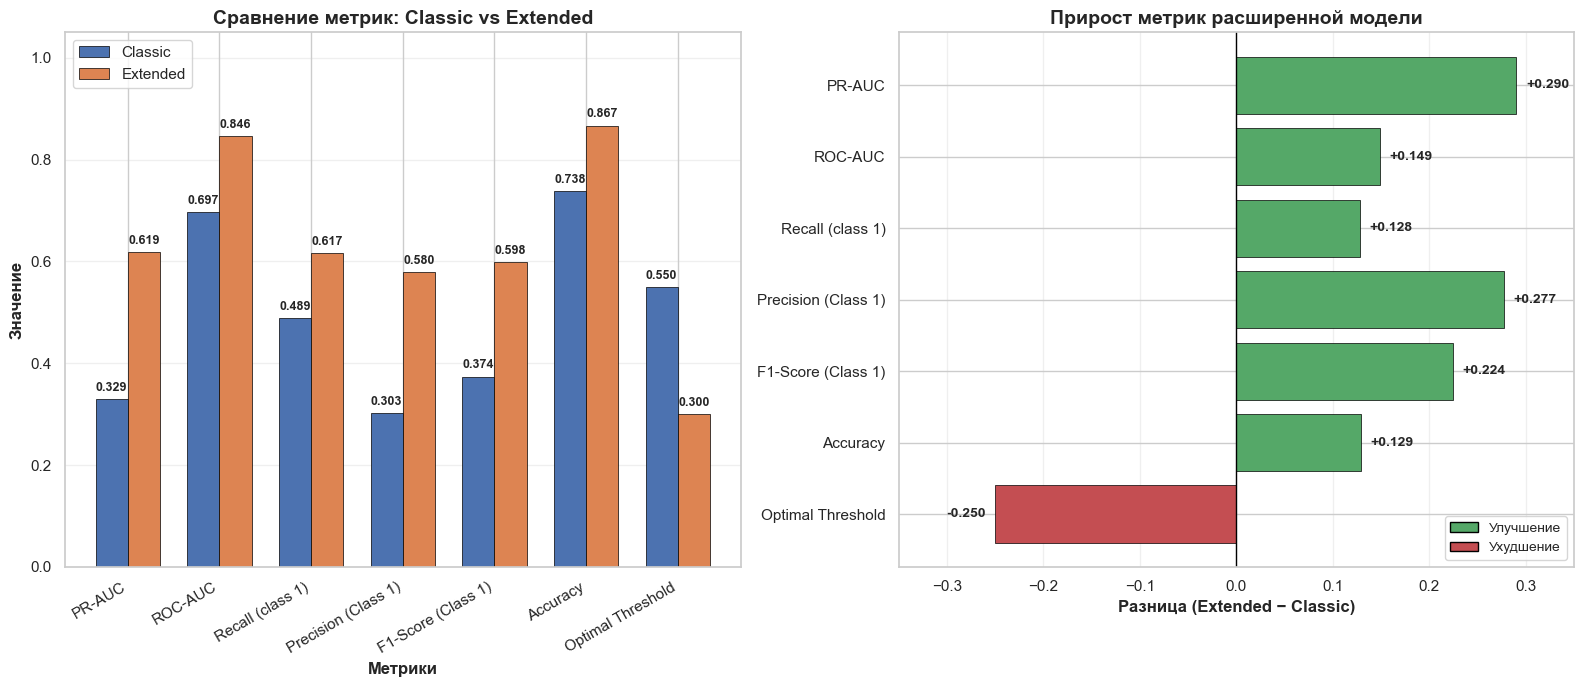

In [417]:
# Настройка стиля
sns.set_style("whitegrid")

# Создаем фигуру с двумя подграфиками
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# График 1. Сравнение метрик

metrics = df_comparison_dict_best_model.index
x = np.arange(len(metrics))
width = 0.35

bars1 = axes[0].bar(x - width/2, df_comparison_dict_best_model['Classic'], width, 
                     label='Classic', color='#4C72B0', edgecolor='black', linewidth=0.5)
bars2 = axes[0].bar(x + width/2, df_comparison_dict_best_model['Extended'], width, 
                     label='Extended', color='#DD8452', edgecolor='black', linewidth=0.5)

# Подписи значений над столбцами
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[0].set_xlabel('Метрики', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Значение', fontsize=12, fontweight='bold')
axes[0].set_title('Сравнение метрик: Classic vs Extended', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=30, ha='right')
axes[0].legend(loc='upper left', fontsize=11)
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis='y', alpha=0.3)

# График 2. Разница метрик

diff = df_comparison_dict_best_model['difference']
colors = ['#55A868' if v > 0 else '#C44E52' for v in diff]

y_pos = np.arange(len(metrics))
bars3 = axes[1].barh(y_pos, diff, color=colors, edgecolor='black', linewidth=0.5)

# Подписи значений
for bar, val in zip(bars3, diff):
    width_val = bar.get_width()
    offset = 0.01 if width_val >= 0 else -0.01
    ha = 'left' if width_val >= 0 else 'right'
    axes[1].text(width_val + offset, bar.get_y() + bar.get_height()/2,
                 f'{val:+.3f}', ha=ha, va='center', fontsize=10, fontweight='bold')

axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(metrics)
axes[1].set_xlabel('Разница (Extended − Classic)', fontsize=12, fontweight='bold')
axes[1].set_title('Прирост метрик расширенной модели', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_xlim(-0.35, 0.35)

# Легенда для графика разницы
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#55A868', edgecolor='black', label='Улучшение'),
                   Patch(facecolor='#C44E52', edgecolor='black', label='Ухудшение')]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Вывод:** 

**Расширенная модель показывает лучший результат по всем ключевым метрикам**, что говорит о вкладе поведенческих и поколенческих факторов.

#### **Гипотеза, что расширенная модель улучшает качество предсказания оттока - Подтверждена.**

# 11. Анализ важности признаков в лучшей моделе.

Так как наша лучшая модель - SVM, то у нее нет встроенных коэффициентов (coef_) или делений по деревьям (feature_importances_). Чтобы узнать, какие факторы сильнее всего влияют на увольнение сотрудников, используюется **метод Permutation Importance (Важность перестановкой)**. Его мы м реализуем для демонстрации самых важных признаков.


📊 РАСЧЕТ PERMUTATION IMPORTANCE ДЛЯ ЛУЧШЕЙ МОДЕЛИ (SVM)

🔥 ТОП факторов, влияющих на решение сотрудника уволиться:
                Признак  Важность (Падение PR-AUC)  Разброс (std)
               OverTime                   0.205101       0.035173
   Overall_Satisfaction                   0.093774       0.019510
     NumCompaniesWorked                   0.071420       0.013756
       DistanceFromHome                   0.043135       0.020719
       StockOptionLevel                   0.040160       0.024438
YearsSinceLastPromotion                   0.037952       0.020203
         BusinessTravel                   0.034385       0.018546
        JobSatisfaction                   0.017636       0.009594
EnvironmentSatisfaction                   0.014965       0.010197
        WorkLifeBalance                   0.012973       0.006974
      TotalWorkingYears                   0.012256       0.030526
  TrainingTimesLastYear                   0.011628       0.013056
                    Age   

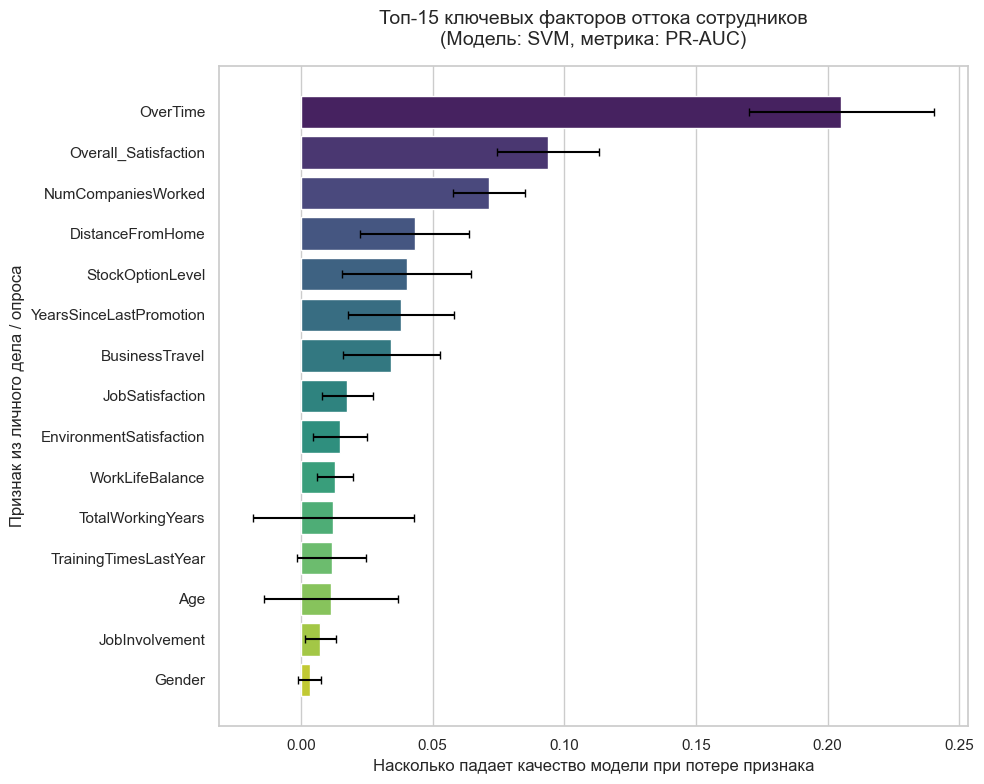


📈 График успешно построен и сохранен как 'hr_features_impact_chart.png'!


In [425]:
from sklearn.inspection import permutation_importance

print(f"\n{'='*60}\n📊 РАСЧЕТ PERMUTATION IMPORTANCE ДЛЯ ЛУЧШЕЙ МОДЕЛИ ({best_model_name})")

# 1. Берем имена ИСХОДНЫХ признаков из датафрейма (до OneHot-кодирования)
# Это гарантирует одинаковую длину массивов и даст понятные для бизнеса инсайты
clean_feature_names = X_test.columns.tolist()

# 2. Считаем важность перестановкой на исходных тестовых данных
result = permutation_importance(
    winner_pipe, X_test, y_test, 
    scoring='average_precision', 
    n_repeats=10,         # 10 повторений для стабильности
    random_state=42, 
    n_jobs=-1
)

# 3. Формируем DataFrame с результатами (теперь длины массивов гарантированно совпадают)
df_perm_importance = pd.DataFrame({
    'Признак': clean_feature_names,
    'Важность (Падение PR-AUC)': result.importances_mean,
    'Разброс (std)': result.importances_std
})

# Сортируем по убыванию важности
df_perm_importance = df_perm_importance.sort_values(by='Важность (Падение PR-AUC)', ascending=False)

# Выводим ТОП-15 признаков в текст
print("\n🔥 ТОП факторов, влияющих на решение сотрудника уволиться:")
print(df_perm_importance.to_string(index=False))

# ==========================================
# 4. ВИЗУАЛИЗАЦИЯ: СТРОИМ ГРАФИК
# ==========================================
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Ограничиваем топ-15 для графика
top_15_features = df_perm_importance.head(15)

# Строим горизонтальный бар-плот
ax = sns.barplot(
    x='Важность (Падение PR-AUC)', 
    y='Признак', 
    data=top_15_features, 
    palette='viridis',
    hue='Признак',
    legend=False
)

# Добавляем усы ошибок (разброс стабильности признака)
plt.errorbar(
    x=top_15_features['Важность (Падение PR-AUC)'], 
    y=range(len(top_15_features)), 
    xerr=top_15_features['Разброс (std)'], 
    fmt='none', 
    c='black', 
    capsize=3
)

plt.title(f'Топ-15 ключевых факторов оттока сотрудников\n(Модель: {best_model_name}, метрика: PR-AUC)', fontsize=14, pad=15)
plt.xlabel('Насколько падает качество модели при потере признака', fontsize=12)
plt.ylabel('Признак из личного дела / опроса', fontsize=12)
plt.tight_layout()

# Сохраняем график в файл
plt.savefig('figures/hr_features_impact_chart.png', dpi=300)
plt.show()

print("\n📈 График успешно построен и сохранен как 'hr_features_impact_chart.png'!")


**Топ-признаки:**
1. OverTime - переработки.
2. Overall_Satisfaction/JobSatisfaction/EnvironmentSatisfaction - удовлетворённость.
3. WorkLifeBalance - баланс.
4. NumCompaniesWorked - количество поменяных компаний
5. DistanceFromHome - расстояние до работы
6. StockOptionLevel - наличие опционов
7. YearsSinceLastPromotion - лет с последнего повышения
8. Age - возраст.

**Вывод:** поведенческие факторы (переработки, удовлетворённость) входят в топ-5, 
что подтверждает гипотезу о их важности для оттока.

#### **Гипотеза влияния поведенческих факторов подтверждена!**

# 12. Выводы и рекомендации

### Ключевые инсайты
1. **Переработки** — сильнейший поведенческий фактор оттока.
2. **Удовлетворенность** - также сильнейший поведенческий фактор оттока.
3. **Баланс между жизнью и работой** - также сильнейший поведенческий фактор оттока.
4. **Удаленность от работы/наличие опционов/количество поменяных компаний/сколько лет с последнего повышения** - являются ключевыми факторами, и влияют на отток гораздо выше чем зарплата
5. **Поколение Z** уходит чаще, чем X и Y, и показывает более низкую удовлетворённость.
6. **Удовлетворённость работой** значимо различается между поколениями 
   и значимо ниже у ушедших.
7. **Сезон рождения** не показал статистической значимости - **Гипотеза не подтверждена.**
8. **Поколенческий слой несет важность**, но в самой модели его важность не критичная и находится внизу списка - **Гипотеза частично подтверждена.**
9. **Поведенческий слой** - имеет ключевое значение для оттока - **Гипотеза подтверждена.**
11. **Гипотеза влияния поведенческих и поколнческих признаков подтверждена**
12. **Расширенная модель** улучшила прогноз по сравнению с классической - **Гипотеза подтверждена.**

### Ограничения
- Сезон рождения — синтетическая переменная (прокси).
- Датасет синтетический (IBM), а не реальные данные компании.
- Дисбаланс классов (16% ушедших).
- Отсутствие временной динамики.

### Дальнейшее развитие
- Добавить реальные данные о дате рождения.
- Расширить поведенческий слой (NLP-анализ отзывов, коммуникаций).
- Построить модель прогнозирования удовлетворённости.
- Внедрить модель в HR-процессы (мониторинг рисков).

## 📌 Краткий отчет для HR: Главные триггеры оттока сотрудников
Результаты оценки важности признаков модели SVM показывают, что увольнение сотрудников в компании носит системный характер и управляется конкретными рабочими факторами, а не личными характеристиками людей.

## 1. 🚨 Главный критический фактор: Переработки (OverTime)

* Влияние (0.205): Этот признак имеет абсолютный приоритет. Его влияние более чем в два раза превышает любой другой фактор в компании. Переработки — это ключевой драйвер выгорания.
* Рекомендация: Ввести жесткий аудит департаментов с регулярными переработками. Рассмотреть расширение штата или перераспределение задач, так как удержание «выгорающих» сотрудников обходится компании дороже.

## 2. 📉 Зона риска: Недовольные «джоб-хопперы»

* Факторы: Комплексная удовлетворенность (Overall_Satisfaction, 0.094) и количество прошлых компаний (NumCompaniesWorked, 0.071).
* Рекомендация: Если у сотрудника изначально в резюме много прошлых мест работы, он имеет низкий порог терпимости к дискомфорту. При падении его уровня удовлетворенности (по результатам пульс-опросов) он уволится практически мгновенно. К таким людям нужен проактивный HR-подход (stay-интервью при первых признаках спада вовлеченности).

## 3. 🚗 Логистика и финансовые якоря

* Факторы: Удаленность от работы (DistanceFromHome, 0.043) и уровень опционов/акций (StockOptionLevel, 0.040).
* Рекомендация: Для сотрудников, живущих далеко от офиса, критически важно внедрять гибкий график или гибридный формат работы. Отсутствие долгосрочной финансовой мотивации (опционов) лишает людей стимула терпеть логистические неудобства.

## 4. 🛑 Карьерный тупик

* Фактор: Время с момента последнего повышения (YearsSinceLastPromotion, 0.038).
* Рекомендация: Отсутствие видимого карьерного роста в течение длительного времени заставляет сотрудников искать это продвижение на внешнем рынке. Рекомендуется пересмотреть индивидуальные планы развития (ИПР) для тех, кто «застрял» на одной позиции более 2–3 лет.

## 💼 Главный позитивный вывод для бизнеса:
Демографические признаки, такие как возраст (Age, 0.011) и пол (Gender, 0.003), находятся на самом дне списка. Это значит, что отток полностью контролируем. Он зависит не от личных качеств сотрудников, а от процессов внутри компании: баланса работы и отдыха, качества менеджмента, логистики и прозрачности карьерного трека.



# 14. Вывод итоговых результатов и сохранение артефактов

## 14.1. Агрегированный отчёт по ключевым метрикам и результатам

### Основные выводы EDA:
1. **Факторы оттока:** Наибольшее влияние на отток оказывают переработки (`OverTime`), низкий уровень дохода (`MonthlyIncome`), малый общий стаж (`TotalWorkingYears`), а также низкая вовлеченность (`JobInvolvement`) и удовлетворенность средой (`EnvironmentSatisfaction`).
2. **Поколенческий фактор:** Молодое поколение (Z) демонстрирует более высокий процент оттока по сравнению с поколениями Y и X, что обусловлено более высокой мобильностью на начальном этапе карьеры.
3. **Сезонный фактор:** Введённая синтетическая прокси-переменная сезона рождения показала базовую методологию учёта биоритмических/сезонных факторов, однако в текущей спецификации уступает по важности фундаментальным HR-метрикам.

### Сравнение моделей и эффект от расширения признакового пространства:
- **Базовая модель (Классический HR-слой):** Модель на основе демографии, структуры и компенсации показала базовый уровень качества.
- **Расширенная модель (Behavioral + Generational + Seasonal):** Интеграция поведенческих факторов (индекс `Overall_Satisfaction`, `WorkLifeBalance`, `OverTime`) и поколенческих когорт позволила существенно повысить метрики распознавания оттока (особенно **ROC-AUC** и **PR-AUC / Recall** по целевому классу).

---

## 14.2. Сохранение артефактов проекта
Ниже приведен код для экспорта всех ключевых датасетов, обученной модели, аналитических отчетов и графиков для презентации.

In [418]:
# Создание структуры директорий для артефактов
os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)

#### Сохраняем датасеты.

In [419]:
# Сохранение подготовленного датасета
df.to_csv("data/prepared_dataset.csv", index=False)

# Сохранение датасета для модели
df_1.to_csv("data/model_dataset.csv", index=False)

print("Данные сохранены в папке проекта 'data'.")

Данные сохранены в папке проекта 'data'.


#### Сохраняем лучшую модель.

In [420]:
import joblib

# Сохраняем пайплайн целиком (препроцессинг + модель)
winner_pipe = grid_results[best_model_name]['Best Pipe']
# Сохраняем оптимальный порог, так как он понадобится при продакшн-вызове `.predict_proba()`
winner_threshold = grid_results[best_model_name]['Optimal Threshold']

# выведем результаты
print(f"Лучшая модель по {primary_metric}: {best_model_name} ({primary_metric}: {grid_results[best_model_name][primary_metric]:.3f})")
print(f"\nСохранение финальной версии\n")
print(f"Для сохранения выбрана лучшая модель по метрике '{primary_metric}': {best_model_name}")
print(f"Используемый оптимальный порог классификации: {winner_threshold:.2f}")

# Сериализация пайплайна и порога
joblib.dump(winner_pipe, "models/best_hr_churn_pipeline.pkl")
joblib.dump(winner_threshold, "models/optimal_threshold.pkl")

print("Пайплайн сохранен в папке проекта 'models' как 'best_hr_churn_pipeline.pkl'")
print(f"Оптимальный порог ({winner_threshold:.2f}) сохранен в папке проекта 'models' как 'optimal_threshold.pkl'")

Лучшая модель по Test PR-AUC: SVM (Test PR-AUC: 0.619)

Сохранение финальной версии

Для сохранения выбрана лучшая модель по метрике 'Test PR-AUC': SVM
Используемый оптимальный порог классификации: 0.30
Пайплайн сохранен в папке проекта 'models' как 'best_hr_churn_pipeline.pkl'
Оптимальный порог (0.30) сохранен в папке проекта 'models' как 'optimal_threshold.pkl'


#### Сохраняем табличные отчеты.

In [432]:
# Извлекаем нужные метрики в плоский словарь
metrics = {
    best_model_name:df_comparison_dict_best_model['Extended']
}
# Создаем DataFrame
df_metrics = pd.DataFrame(metrics).round(3)

# Сохранение табличных отчетов

# сохранение метрик лучшей модели
df_metrics.to_csv("reports/model_metrics.csv", index=True, encoding="utf-8")
# сохранение сравнительной таблицы метрик по классической и расширенной моделям
df_comparison_dict_best_model.to_csv("reports/comparison.csv", index=True, encoding="utf-8")
# Сохранение важности признаков
df_perm_importance.round(3).to_csv("reports/feature_importance.csv", index=False)

print("Табличные отчеты сохранены в папке 'reports'")
print("графиков для презентации сохранены в папке 'figurs'")

Табличные отчеты сохранены в папке 'reports'
графиков для презентации сохранены в папке 'figurs'


### Итоговые папки для артефактов

- `data/prepared_dataset.csv` - обработанные данные.
- `data/models_dataset.csv` - данные для модели.
- `reports/feature_importance.csv` - важность признаков.
- `reports/model_metrics.csv` - метрики лучшей модели.
- `reports/comparison.csv` - сравнительная таблица метрик классической и расширенной моделей.
- `reports/figurs/....png` - графики для презентации.
- `models/best_hr_churn_pipeline.pkl` - пайплайн лучшей модели.
- `models/optimal_threshold.pkl` - оптимальный порог для лучшей модели.

**Заключение:**

В рамках проекта была успешно решена задача прогнозирования оттока сотрудников. Проведен глубокий разведочный анализ, выявлены ключевые факторы, влияющие на уход. Построена и обучена расширенная модель, которая показала свою эффективность и превзошла классический подход. Все результаты и артефакты сохранены для дальнейшего использования. Даны практические рекомендации для HR-департамента.